# KOSPI200 편입/편출 예측 모델
- **방법**: TOP300 → 필터링(부적격/유동비율/리츠/신규상장) → 스코어링 → 1~220위 랭킹 → TOP200 예측
- **Train**: 2020_H1 ~ 2024_H2 / **Test**: 2025_H1, 2025_H2
- **피쳐**: 시총·거래·대주주·외국인 + 섹터(GICS/KRX) + 매크로(macro.csv)
- **모델 비교**: LightGBM, XGBoost, RandomForest, LogisticRegression

In [58]:
import pandas as pd
import numpy as np
import mysql.connector
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DB_CFG = {'host':'localhost','user':'root','password':'1234','database':'kospi_db'}
conn = mysql.connector.connect(**DB_CFG)

# 전체 테이블 로드
labels      = pd.read_sql('SELECT * FROM labels', conn)
feature_krx = pd.read_sql('SELECT * FROM feature_krx', conn)
major       = pd.read_sql('SELECT * FROM major_holder', conn)
foreign     = pd.read_sql('SELECT * FROM foreign_holding', conn)
flag        = pd.read_sql('SELECT * FROM filter_flag', conn)
meta        = pd.read_sql('SELECT * FROM stock_meta', conn)
period_tbl  = pd.read_sql('SELECT * FROM period', conn)
sector_map  = pd.read_sql('SELECT * FROM sector_map', conn)

# 회사명 매핑
company_map = pd.read_sql(
    "SELECT ticker, company FROM kospi_friday_daily "
    "WHERE date = (SELECT MAX(date) FROM kospi_friday_daily) "
    "GROUP BY ticker, company", conn)
conn.close()
ticker_to_name = dict(zip(company_map['ticker'], company_map['company']))

# 매크로 데이터
macro = pd.read_csv('C:/Users/Admin/hipython/ml/project/macro.csv')

print('데이터 로드 완료')
for name, d in [('labels',labels),('feature_krx',feature_krx),('major',major),
                ('foreign',foreign),('flag',flag),('meta',meta),
                ('period',period_tbl),('sector_map',sector_map),('macro',macro)]:
    print(f'  {name}: {d.shape}')

데이터 로드 완료
  labels: (2491, 7)
  feature_krx: (3600, 8)
  major: (3474, 8)
  foreign: (73131, 6)
  flag: (129, 6)
  meta: (1019, 5)
  period: (13, 3)
  sector_map: (26, 4)
  macro: (84, 13)


## 2. 외국인보유 + 매크로 데이터 period별 집계
period 테이블의 start/end 기준으로 월별 데이터를 집계

In [59]:
# period 테이블에서 start/end를 ym 정수로 변환
def date_to_ym(d):
    return d.year * 100 + d.month

period_tbl['ym_start'] = period_tbl['period_start'].apply(date_to_ym)
period_tbl['ym_end']   = period_tbl['period_end'].apply(date_to_ym)

def ym_in_range(ym, start, end):
    sy, sm = start // 100, start % 100
    ey, em = end // 100, end % 100
    y, m = ym // 100, ym % 100
    return (sy*12+sm) <= (y*12+m) <= (ey*12+em)

# --- 외국인보유 period별 집계 ---
fh_rows = []
for _, pr in period_tbl.iterrows():
    period = pr['period']
    mask = foreign['ym'].apply(lambda x: ym_in_range(x, pr['ym_start'], pr['ym_end']))
    sub = foreign[mask]
    agg = sub.groupby('ticker').agg(
        avg_foreign_ratio=('foreign_holding_ratio', 'mean'),
        last_foreign_ratio=('foreign_holding_ratio', 'last'),
        avg_exhaustion_rate=('foreign_limit_exhaustion_rate', 'mean'),
    ).reset_index()
    agg['period'] = period
    fh_rows.append(agg)
fh_agg = pd.concat(fh_rows, ignore_index=True)
print(f'외국인보유 집계: {fh_agg.shape}')

# --- 매크로 period별 집계 ---
macro_cols = ['base_rate','usd_krw','cpi','industrial','export','import_',
              'bond_3y','cli','bsi','current_acct','capex','m2']

macro_rows = []
for _, pr in period_tbl.iterrows():
    period = pr['period']
    mask = macro['ym'].apply(lambda x: ym_in_range(x, pr['ym_start'], pr['ym_end']))
    sub = macro[mask]
    if len(sub) == 0:
        continue
    row = {'period': period}
    for col in macro_cols:
        row[f'macro_{col}_mean'] = sub[col].mean()
        row[f'macro_{col}_last'] = sub[col].iloc[-1]
    macro_rows.append(row)

macro_agg = pd.DataFrame(macro_rows)
print(f'매크로 집계: {macro_agg.shape} ({len(macro_agg.columns)-1}개 피쳐)')
print(macro_agg[['period','macro_base_rate_mean','macro_usd_krw_mean','macro_cpi_mean']].to_string(index=False))

외국인보유 집계: (11351, 5)
매크로 집계: (13, 25) (24개 피쳐)
 period  macro_base_rate_mean  macro_usd_krw_mean  macro_cpi_mean
2020_H1              1.312500         1190.398333       99.706667
2020_H2              0.500000         1189.284167       99.981667
2021_H1              0.500000         1110.651667      101.143333
2021_H2              0.625000         1151.305000      102.605000
2022_H1              1.208333         1206.377500      105.185000
2022_H2              2.291667         1336.301667      108.508333
2023_H1              3.416667         1299.387500      110.003333
2023_H2              3.500000         1320.320833      111.996667
2024_H1              3.500000         1328.058333      113.386667
2024_H2              3.458333         1363.947500      114.325000
2025_H1              2.875000         1439.417500      115.628333
2025_H2              2.500000         1389.684167      116.671667
2026_H1              2.500000         1456.217500      117.385000


## 3. 피쳐 매트릭스 구성 + 필터링
TOP300 기준으로 피쳐 조인 → 부적격/유동비율10%미만/리츠/신규상장6개월미만 제외 → 섹터 인코딩

In [60]:
# --- 피쳐 조인 (feature_krx 기준 = TOP300) ---
df = feature_krx.copy()

# labels 조인 (y값: was_member, label_in, label_out)
df = df.merge(labels[['period','ticker','was_member','label_in','label_out','actual_rank']],
              on=['period','ticker'], how='left')

# major_holder 조인 (float_rate 포함)
df = df.merge(major[['period','ticker','major_holder_ratio','treasury_ratio',
                      'non_float_ratio','float_rate']],
              on=['period','ticker'], how='left')

# 외국인보유 조인
df = df.merge(fh_agg, on=['period','ticker'], how='left')

# 매크로 조인 (period 기준, 모든 종목에 동일 값)
df = df.merge(macro_agg, on='period', how='left')

# stock_meta 조인 (필터링 + 상장일)
df = df.merge(meta[['ticker','is_not_common','is_reits','list_date','ksic_sector']],
              on='ticker', how='left')

# filter_flag 조인
if not flag.empty:
    flag_sub = flag[['ticker','flag_date','is_managed','is_warning']].copy()
    flag_sub.rename(columns={'flag_date':'period'}, inplace=True)
    df = df.merge(flag_sub, on=['period','ticker'], how='left')
    df['is_managed'] = df['is_managed'].fillna(0).astype(int)
    df['is_warning'] = df['is_warning'].fillna(0).astype(int)

# NaN 처리
df['was_member'] = df['was_member'].fillna(0).astype(int)
df['label_in']   = df['label_in'].fillna(0).astype(int)
df['label_out']  = df['label_out'].fillna(0).astype(int)

# --- 섹터 인코딩 ---
sector_dict_gics = dict(zip(sector_map['ksic_sector'], sector_map['gics_sector_2023']))
sector_dict_krx  = dict(zip(sector_map['ksic_sector'], sector_map['krx_group']))
df['gics_sector_mapped'] = df['ksic_sector'].map(sector_dict_gics)
df['krx_group_mapped']   = df['ksic_sector'].map(sector_dict_krx)
df['gics_sector'] = df['gics_sector'].fillna(df['gics_sector_mapped'])
df['krx_group']   = df['krx_group'].fillna(df['krx_group_mapped'])

le_gics = LabelEncoder()
le_krx  = LabelEncoder()
df['gics_sector_enc'] = le_gics.fit_transform(df['gics_sector'].fillna('기타').astype(str))
df['krx_group_enc']   = le_krx.fit_transform(df['krx_group'].fillna('기타').astype(str))

print(f'조인 후: {df.shape}')

# --- 필터링 ---
before = len(df)
period_end_map = dict(zip(period_tbl['period'], period_tbl['period_end']))
df['period_end_date'] = df['period'].map(period_end_map)

mask1 = df['is_not_common'] == 1
mask2 = (df['float_rate'] < 0.10) & df['float_rate'].notna()
mask3 = df['is_reits'] == 1
df['list_date'] = pd.to_datetime(df['list_date'])
df['period_end_date'] = pd.to_datetime(df['period_end_date'])
df['months_listed'] = (df['period_end_date'].dt.year - df['list_date'].dt.year) * 12 + \
                       (df['period_end_date'].dt.month - df['list_date'].dt.month)
mask4 = (df['months_listed'] < 6) & df['months_listed'].notna()

exclude = mask1 | mask2 | mask3 | mask4
print(f'제외 상세: 비보통주={mask1.sum()}, 유동비율<10%={mask2.sum()}, '
      f'리츠={mask3.sum()}, 신규상장<6개월={mask4.sum()}')

df = df[~exclude].copy()
print(f'필터링: {before} → {len(df)} ({before - len(df)}건 제외)')
print(f'period별 종목수 (필터 후):\n{df.groupby("period").size()}')

조인 후: (3600, 53)
제외 상세: 비보통주=86, 유동비율<10%=16, 리츠=50, 신규상장<6개월=57
필터링: 3600 → 3395 (205건 제외)
period별 종목수 (필터 후):
period
2020_H1    288
2020_H2    286
2021_H1    282
2021_H2    274
2022_H1    285
2022_H2    284
2023_H1    283
2023_H2    281
2024_H1    281
2024_H2    283
2025_H1    284
2025_H2    284
dtype: int64


## 4. 피쳐 엔지니어링 + 편입/편출 모델용 데이터 분리
- prev_was_member로 전기 멤버/비멤버 구분
- **편입 모델**: 전기 비회원 대상, label_in 예측
- **편출 모델**: 전기 회원 대상, label_out 예측
- **시간 가중치**: 최근 period일수록 높은 weight

In [61]:
# period 순서
period_order = ['2020_H1','2020_H2','2021_H1','2021_H2','2022_H1','2022_H2',
                '2023_H1','2023_H2','2024_H1','2024_H2','2025_H1','2025_H2']
period_map = {p: i for i, p in enumerate(period_order)}
df['period_idx'] = df['period'].map(period_map)
df = df.sort_values(['ticker','period_idx']).reset_index(drop=True)

# 전기 was_member (편입/편출 모델 분리용)
df['prev_was_member'] = df.groupby('ticker')['was_member'].shift(1)

# 전기 대비 변화량 피쳐
df['prev_rank']       = df.groupby('ticker')['period_rank'].shift(1)
df['rank_change']     = df['period_rank'] - df['prev_rank']
df['prev_mktcap']     = df.groupby('ticker')['avg_mktcap'].shift(1)
df['mktcap_change']   = (df['avg_mktcap'] - df['prev_mktcap']) / df['prev_mktcap'].replace(0, np.nan)
df['prev_foreign']    = df.groupby('ticker')['avg_foreign_ratio'].shift(1)
df['foreign_change']  = df['avg_foreign_ratio'] - df['prev_foreign']
df['prev_turnover']   = df.groupby('ticker')['turnover_ratio'].shift(1)
df['turnover_change'] = df['turnover_ratio'] - df['prev_turnover']

# 매크로 피쳐 목록
macro_features = [c for c in df.columns if c.startswith('macro_')]

# 전체 피쳐 목록
FEATURES = [
    'avg_mktcap', 'period_rank', 'turnover_ratio', 'float_ratio',
    'major_holder_ratio', 'treasury_ratio', 'non_float_ratio', 'float_rate',
    'avg_foreign_ratio', 'last_foreign_ratio', 'avg_exhaustion_rate',
    'is_managed', 'is_warning',
    'prev_rank', 'rank_change', 'mktcap_change', 'foreign_change', 'turnover_change',
    'gics_sector_enc', 'krx_group_enc',
] + macro_features

print(f'피쳐 수: {len(FEATURES)}')

# --- Train/Test 분할 ---
train_periods = ['2020_H2','2021_H1','2021_H2','2022_H1','2022_H2',
                 '2023_H1','2023_H2','2024_H1','2024_H2']  # 2020_H1 제외 (prev 없음)
test_periods  = ['2025_H1','2025_H2']

# prev_was_member가 있는 행만 사용
df_valid = df[df['prev_was_member'].notna()].copy()

# --- 시간 가중치 (최근 period일수록 높은 가중치) ---
# 2020_H2=1, 2021_H1=2, ..., 2024_H2=9
df_valid['time_weight'] = df_valid['period'].map(
    {p: i+1 for i, p in enumerate(train_periods + test_periods)}
)

# 편입 모델: 전기 비회원(prev_was_member=0) 대상
train_in = df_valid[(df_valid['period'].isin(train_periods)) & (df_valid['prev_was_member'] == 0)]
test_in  = df_valid[(df_valid['period'].isin(test_periods))  & (df_valid['prev_was_member'] == 0)]

# 편출 모델: 전기 회원(prev_was_member=1) 대상
train_out = df_valid[(df_valid['period'].isin(train_periods)) & (df_valid['prev_was_member'] == 1)]
test_out  = df_valid[(df_valid['period'].isin(test_periods))  & (df_valid['prev_was_member'] == 1)]

print(f'\n=== 편입 모델 (전기 비회원 → label_in 예측) ===')
print(f'Train: {train_in.shape[0]}건, label_in=1: {train_in["label_in"].sum()}건 ({train_in["label_in"].mean():.1%})')
print(f'Test:  {test_in.shape[0]}건,  label_in=1: {test_in["label_in"].sum()}건 ({test_in["label_in"].mean():.1%})')

print(f'\n=== 편출 모델 (전기 회원 → label_out 예측) ===')
print(f'Train: {train_out.shape[0]}건, label_out=1: {train_out["label_out"].sum()}건 ({train_out["label_out"].mean():.1%})')
print(f'Test:  {test_out.shape[0]}건,  label_out=1: {test_out["label_out"].sum()}건 ({test_out["label_out"].mean():.1%})')

print(f'\n시간 가중치 예시:')
for p in train_periods[-3:] + test_periods:
    w = dict(zip(train_periods + test_periods, range(1, len(train_periods)+len(test_periods)+1)))[p]
    print(f'  {p}: weight={w}')

피쳐 수: 44

=== 편입 모델 (전기 비회원 → label_in 예측) ===
Train: 675건, label_in=1: 36건 (5.3%)
Test:  155건,  label_in=1: 13건 (8.4%)

=== 편출 모델 (전기 회원 → label_out 예측) ===
Train: 1759건, label_out=1: 51건 (2.9%)
Test:  394건,  label_out=1: 12건 (3.0%)

시간 가중치 예시:
  2023_H2: weight=7
  2024_H1: weight=8
  2024_H2: weight=9
  2025_H1: weight=10
  2025_H2: weight=11


## 5. 편입/편출 모델 학습 (4개 모델 × 2 태스크)
시간 가중치 적용, label_in / label_out 각각 학습

In [62]:
from sklearn.preprocessing import StandardScaler

def train_models(X_tr, y_tr, w_tr, X_te, y_te, task_name):
    """4개 모델 학습 및 평가, 시간 가중치 적용"""
    models = {
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            num_leaves=31, min_child_samples=5,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=42, verbosity=-1,
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=(y_tr == 0).sum() / max((y_tr == 1).sum(), 1),
            random_state=42, verbosity=0, eval_metric='logloss',
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=10,
            min_samples_leaf=3, class_weight='balanced',
            random_state=42, n_jobs=-1,
        ),
        'LogisticRegression': LogisticRegression(
            max_iter=1000, random_state=42, C=1.0, class_weight='balanced',
        ),
    }
    
    results = {}
    print(f'\n{"="*60}')
    print(f' {task_name}  (Train: {len(y_tr)}, 양성: {y_tr.sum()}, Test: {len(y_te)}, 양성: {y_te.sum()})')
    print(f'{"="*60}')
    
    for name, model in models.items():
        if name == 'LogisticRegression':
            scaler = StandardScaler()
            X_tr_m = pd.DataFrame(scaler.fit_transform(X_tr.fillna(0)), columns=FEATURES)
            X_te_m = pd.DataFrame(scaler.transform(X_te.fillna(0)), columns=FEATURES)
            model.fit(X_tr_m, y_tr, sample_weight=w_tr)
            scores = model.predict_proba(X_te_m)[:, 1]
        else:
            model.fit(X_tr, y_tr, sample_weight=w_tr)
            scores = model.predict_proba(X_te)[:, 1]
        
        # TOP20 기준 Precision
        top20_idx = scores.argsort()[::-1][:20]
        top20_actual = y_te.iloc[top20_idx]
        precision_20 = top20_actual.sum() / 20
        
        # AUC (양성이 있을 때만)
        auc = roc_auc_score(y_te, scores) if y_te.sum() > 0 and y_te.sum() < len(y_te) else 0
        
        print(f'  [{name:<20s}] AUC={auc:.4f}  TOP20 Precision={top20_actual.sum():.0f}/20 ({precision_20:.0%})')
        
        results[name] = {'model': model, 'scores': scores, 'auc': auc, 'precision_20': precision_20}
    
    return results

# === 편입 모델 학습 ===
X_tr_in = train_in[FEATURES]
y_tr_in = train_in['label_in']
w_tr_in = train_in['time_weight']
X_te_in = test_in[FEATURES]
y_te_in = test_in['label_in']

in_results = train_models(X_tr_in, y_tr_in, w_tr_in, X_te_in, y_te_in, '편입 모델 (label_in)')

# === 편출 모델 학습 ===
X_tr_out = train_out[FEATURES]
y_tr_out = train_out['label_out']
w_tr_out = train_out['time_weight']
X_te_out = test_out[FEATURES]
y_te_out = test_out['label_out']

out_results = train_models(X_tr_out, y_tr_out, w_tr_out, X_te_out, y_te_out, '편출 모델 (label_out)')


 편입 모델 (label_in)  (Train: 675, 양성: 36, Test: 155, 양성: 13)
  [LightGBM            ] AUC=0.5428  TOP20 Precision=4/20 (20%)
  [XGBoost             ] AUC=0.5737  TOP20 Precision=3/20 (15%)
  [RandomForest        ] AUC=0.5970  TOP20 Precision=4/20 (20%)
  [LogisticRegression  ] AUC=0.7178  TOP20 Precision=3/20 (15%)

 편출 모델 (label_out)  (Train: 1759, 양성: 51, Test: 394, 양성: 12)
  [LightGBM            ] AUC=0.7378  TOP20 Precision=4/20 (20%)
  [XGBoost             ] AUC=0.7631  TOP20 Precision=4/20 (20%)
  [RandomForest        ] AUC=0.7537  TOP20 Precision=4/20 (20%)
  [LogisticRegression  ] AUC=0.7317  TOP20 Precision=5/20 (25%)


## 6. 피쳐 중요도 비교 (편입 모델 vs 편출 모델)

편입 최적 모델: LogisticRegression (AUC=0.7178)
편출 최적 모델: XGBoost (AUC=0.7631)


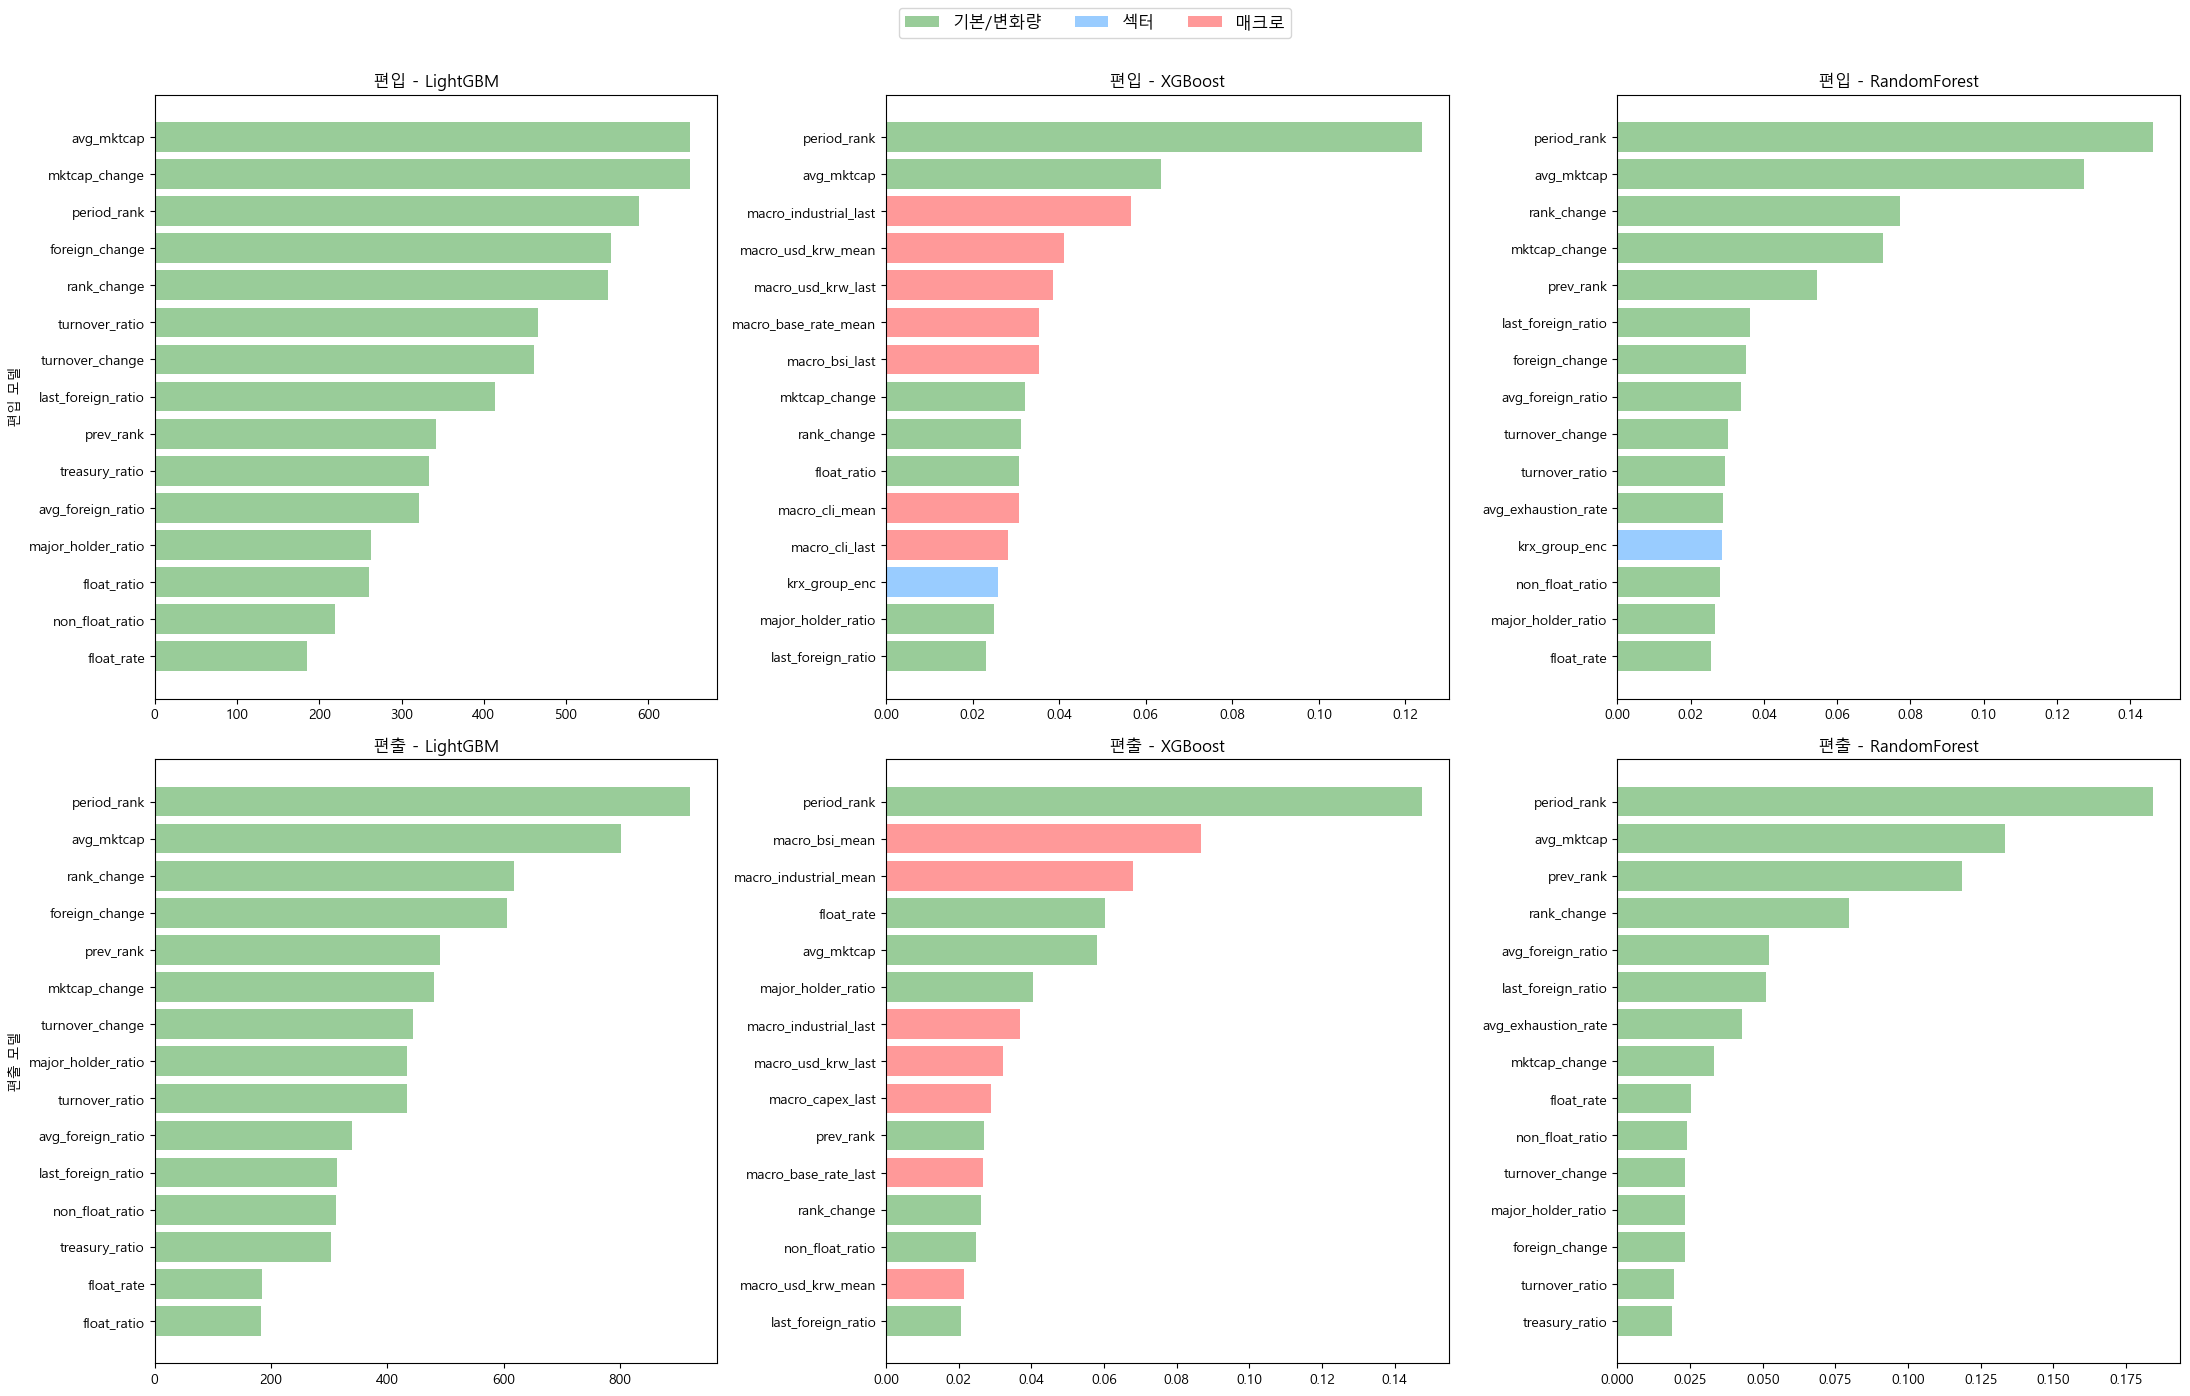


[편입 - LogisticRegression] TOP 10 피쳐:
   1. avg_foreign_ratio                2.8160
   2. last_foreign_ratio               2.6593
   3. rank_change                      1.7785
   4. period_rank                      1.4177
   5. float_rate                       1.1473
   6. major_holder_ratio               0.6910
   7. turnover_ratio                   0.6582
   8. non_float_ratio                  0.6185
   9. avg_mktcap                       0.5985
  10. mktcap_change                    0.5869

[편출 - XGBoost] TOP 10 피쳐:
   1. period_rank                      0.1474
   2. macro_bsi_mean                   0.0866 (매크로)
   3. macro_industrial_mean            0.0680 (매크로)
   4. float_rate                       0.0603
   5. avg_mktcap                       0.0580
   6. major_holder_ratio               0.0405
   7. macro_industrial_last            0.0368 (매크로)
   8. macro_usd_krw_last               0.0321 (매크로)
   9. macro_capex_last                 0.0290 (매크로)
  10. prev_rank                

In [63]:
# 최적 모델 선택 (AUC 기준)
best_in_name  = max(in_results,  key=lambda k: in_results[k]['auc'])
best_out_name = max(out_results, key=lambda k: out_results[k]['auc'])
print(f'편입 최적 모델: {best_in_name} (AUC={in_results[best_in_name]["auc"]:.4f})')
print(f'편출 최적 모델: {best_out_name} (AUC={out_results[best_out_name]["auc"]:.4f})')

# 트리 기반 모델 피쳐 중요도 비교
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for col, name in enumerate(['LightGBM', 'XGBoost', 'RandomForest']):
    for row, (task, res) in enumerate([('편입', in_results), ('편출', out_results)]):
        ax = axes[row][col]
        m = res[name]['model']
        imp = pd.DataFrame({'feature': FEATURES, 'importance': m.feature_importances_})
        imp = imp.sort_values('importance', ascending=True).tail(15)
        
        colors = []
        for f in imp['feature']:
            if f.startswith('macro_'): colors.append('#ff9999')
            elif f.endswith('_enc'):   colors.append('#99ccff')
            else:                      colors.append('#99cc99')
        
        ax.barh(imp['feature'], imp['importance'], color=colors)
        ax.set_title(f'{task} - {name}')
        if col == 0:
            ax.set_ylabel(f'{task} 모델')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#99cc99', label='기본/변화량'),
                   Patch(facecolor='#99ccff', label='섹터'),
                   Patch(facecolor='#ff9999', label='매크로')]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# TOP10 피쳐 텍스트 출력
for task, res, best in [('편입', in_results, best_in_name), ('편출', out_results, best_out_name)]:
    m = res[best]['model']
    # LogisticRegression이면 coef_ 사용
    if hasattr(m, 'feature_importances_'):
        imp = pd.Series(m.feature_importances_, index=FEATURES)
    else:
        imp = pd.Series(np.abs(m.coef_[0]), index=FEATURES)
    top10 = imp.sort_values(ascending=False).head(10)
    print(f'\n[{task} - {best}] TOP 10 피쳐:')
    for i, (feat, val) in enumerate(top10.items(), 1):
        tag = ' (매크로)' if feat.startswith('macro_') else (' (섹터)' if feat.endswith('_enc') else '')
        print(f'  {i:2d}. {feat:<30s} {val:>8.4f}{tag}')

## 7. 편입/편출 TOP20 결과 + Precision 평가
- 편입: 예측 200위 안 신규 종목 리스트 vs 실제 편입
- 편출: 예측 200위 밖 기존 종목 리스트 vs 실제 편출

In [64]:
# 전기 실제 KOSPI200 멤버 리스트
actual_members = {}
for p in period_order:
    members = set(labels[(labels['period'] == p) & (labels['was_member'] == 1)]['ticker'])
    actual_members[p] = members

# 최적 모델 스코어
best_in_scores  = in_results[best_in_name]['scores']
best_out_scores = out_results[best_out_name]['scores']

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    # --- 편입 TOP20 ---
    te_in = test_in[test_in['period'] == target_period].copy()
    te_in['score'] = best_in_scores[test_in['period'] == target_period] if len(te_in) > 0 else []
    # score가 제대로 매핑되도록 인덱스 기반
    te_in_idx = test_in.index[test_in['period'] == target_period]
    score_map_in = dict(zip(te_in_idx, best_in_scores[np.isin(test_in.index, te_in_idx)]))
    te_in['score'] = te_in.index.map(score_map_in)
    te_in['company'] = te_in['ticker'].map(ticker_to_name).fillna('')
    te_in = te_in.sort_values('score', ascending=False)
    
    # 200위 안에 들어갈 종목 판별 (전체 df에서 해당 period의 스코어 기반 랭킹)
    # 전기 회원은 유지 가정 + 편입 스코어 높은 순으로 채움
    in_top20 = te_in.head(20).copy()
    
    # --- 편출 TOP20 ---
    te_out = test_out[test_out['period'] == target_period].copy()
    te_out_idx = test_out.index[test_out['period'] == target_period]
    score_map_out = dict(zip(te_out_idx, best_out_scores[np.isin(test_out.index, te_out_idx)]))
    te_out['score'] = te_out.index.map(score_map_out)
    te_out['company'] = te_out['ticker'].map(ticker_to_name).fillna('')
    te_out = te_out.sort_values('score', ascending=False)  # 편출 확률 높은 순
    
    out_top20 = te_out.head(20).copy()
    
    # --- 출력 ---
    print(f'\n{"="*80}')
    print(f' {target_period}  (전기: {prev_period})')
    print(f' 실제 편입: {len(actual_in_set)}건, 실제 편출: {len(actual_out_set)}건')
    print(f' 편입 모델: {best_in_name}, 편출 모델: {best_out_name}')
    print(f'{"="*80}')
    
    # 편입 TOP20
    print(f'\n--- 편입 TOP20 (전기 비회원 중 편입 확률 높은 순) ---')
    disp_in = in_top20[['ticker','company','score','period_rank']].reset_index(drop=True)
    disp_in.index += 1; disp_in.index.name = '순위'
    disp_in['실제편입'] = disp_in['ticker'].apply(lambda t: '○' if t in actual_in_set else '')
    disp_in['score'] = disp_in['score'].round(4)
    disp_in.rename(columns={'period_rank':'시총순위'}, inplace=True)
    print(disp_in.to_string())
    
    in_hit = in_top20['ticker'].isin(actual_in_set).sum()
    print(f'\n→ 편입 Precision: {in_hit}/20 ({in_hit/20:.0%})  |  실제 편입 {len(actual_in_set)}건 중 {in_hit}건 적중')
    
    # 편출 TOP20
    print(f'\n--- 편출 TOP20 (전기 회원 중 편출 확률 높은 순) ---')
    disp_out = out_top20[['ticker','company','score','period_rank']].reset_index(drop=True)
    disp_out.index += 1; disp_out.index.name = '순위'
    disp_out['실제편출'] = disp_out['ticker'].apply(lambda t: '○' if t in actual_out_set else '')
    disp_out['score'] = disp_out['score'].round(4)
    disp_out.rename(columns={'period_rank':'시총순위'}, inplace=True)
    print(disp_out.to_string())
    
    out_hit = out_top20['ticker'].isin(actual_out_set).sum()
    print(f'\n→ 편출 Precision: {out_hit}/20 ({out_hit/20:.0%})  |  실제 편출 {len(actual_out_set)}건 중 {out_hit}건 적중')


 2025_H1  (전기: 2024_H2)
 실제 편입: 5건, 실제 편출: 5건
 편입 모델: LogisticRegression, 편출 모델: XGBoost

--- 편입 TOP20 (전기 비회원 중 편입 확률 높은 순) ---
    ticker     company   score  시총순위 실제편입
순위                                       
1    20560      아시아나항공  0.9813   152     
2    18670        SK가스  0.9337   130     
3   298040       효성중공업  0.9228    84    ○
4   307950      현대오토에버  0.8371    92     
5     6040        동원산업  0.7955   170     
6    82740        한화엔진  0.7893   148     
7     9450       경동나비엔  0.7838   184     
8   278470        에이피알  0.7835   129    ○
9    71970    HD현대마린엔진  0.7091   218     
10  950210  프레스티지바이오파마  0.7088   213     
11    7340     DN오토모티브  0.6935   185     
12    3690        코리안리  0.6779   159     
13   12510       더존비즈온  0.6710   135     
14  103590        일진전기  0.6490   174     
15    5440    현대지에프홀딩스  0.6123   234     
16    1530        DI동일  0.6073   206     
17  294870   HDC현대산업개발  0.5375   176     
18  267270      HD건설기계  0.5173   183     
19     990       DB하이텍  0.5078

## 8. 피쳐 그룹별 Ablation Study (편입/편출 각각)
섹터·매크로 피쳐가 편입/편출 예측에 실제로 도움되는지 확인

In [65]:
# 피쳐 그룹 정의
feat_groups = {
    '기본(시총/거래/대주주/외국인)': [f for f in FEATURES if not f.startswith('macro_') 
                                   and not f.endswith('_enc')
                                   and f not in ['prev_rank','rank_change','mktcap_change',
                                                 'foreign_change','turnover_change']],
    '변화량': ['prev_rank','rank_change','mktcap_change','foreign_change','turnover_change'],
    '섹터': ['gics_sector_enc', 'krx_group_enc'],
    '매크로': macro_features,
}

def ablation_study(X_tr, y_tr, w_tr, X_te, y_te, task_name, best_model_name):
    """피쳐 그룹별 제거/단독 실험"""
    print(f'\n=== {task_name} Ablation Study ({best_model_name}) ===')
    
    def get_model():
        return lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            num_leaves=31, min_child_samples=5,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=42, verbosity=-1)
    
    # Baseline
    m = get_model()
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    base_scores = m.predict_proba(X_te)[:, 1]
    base_auc = roc_auc_score(y_te, base_scores) if y_te.sum() > 0 and y_te.sum() < len(y_te) else 0
    top20_hit = y_te.iloc[base_scores.argsort()[::-1][:20]].sum()
    print(f'{"전체 피쳐 (baseline)":<35s} AUC={base_auc:.4f}  TOP20={top20_hit:.0f}/20')
    print('-' * 65)
    
    # 각 그룹 제거
    for gname, gfeats in feat_groups.items():
        reduced = [f for f in FEATURES if f not in gfeats]
        if len(reduced) == 0: continue
        m = get_model()
        m.fit(X_tr[reduced], y_tr, sample_weight=w_tr)
        scores = m.predict_proba(X_te[reduced])[:, 1]
        auc = roc_auc_score(y_te, scores) if y_te.sum() > 0 and y_te.sum() < len(y_te) else 0
        t20 = y_te.iloc[scores.argsort()[::-1][:20]].sum()
        diff = auc - base_auc
        arrow = '↑' if diff > 0 else '↓'
        print(f'{gname+" 제거":<35s} AUC={auc:.4f} ({arrow}{abs(diff):.4f})  TOP20={t20:.0f}/20')
    
    print()
    # 각 그룹만 사용
    for gname, gfeats in feat_groups.items():
        valid = [f for f in gfeats if f in FEATURES]
        if len(valid) < 2: continue
        m = get_model()
        m.fit(X_tr[valid], y_tr, sample_weight=w_tr)
        scores = m.predict_proba(X_te[valid])[:, 1]
        auc = roc_auc_score(y_te, scores) if y_te.sum() > 0 and y_te.sum() < len(y_te) else 0
        t20 = y_te.iloc[scores.argsort()[::-1][:20]].sum()
        print(f'{gname+" 만 사용":<35s} AUC={auc:.4f}  TOP20={t20:.0f}/20')

# 편입 모델 Ablation
ablation_study(X_tr_in, y_tr_in, w_tr_in, X_te_in, y_te_in, '편입', best_in_name)

# 편출 모델 Ablation
ablation_study(X_tr_out, y_tr_out, w_tr_out, X_te_out, y_te_out, '편출', best_out_name)


=== 편입 Ablation Study (LogisticRegression) ===
전체 피쳐 (baseline)                    AUC=0.5428  TOP20=4/20
-----------------------------------------------------------------
기본(시총/거래/대주주/외국인) 제거                AUC=0.6327 (↑0.0899)  TOP20=4/20
변화량 제거                              AUC=0.5233 (↓0.0195)  TOP20=3/20
섹터 제거                               AUC=0.5569 (↑0.0141)  TOP20=4/20
매크로 제거                              AUC=0.5509 (↑0.0081)  TOP20=3/20

기본(시총/거래/대주주/외국인) 만 사용              AUC=0.5043  TOP20=2/20
변화량 만 사용                            AUC=0.5834  TOP20=3/20
섹터 만 사용                             AUC=0.5374  TOP20=2/20
매크로 만 사용                            AUC=0.5298  TOP20=1/20

=== 편출 Ablation Study (XGBoost) ===
전체 피쳐 (baseline)                    AUC=0.7378  TOP20=4/20
-----------------------------------------------------------------
기본(시총/거래/대주주/외국인) 제거                AUC=0.7155 (↓0.0223)  TOP20=3/20
변화량 제거                              AUC=0.6558 (↓0.0820)  TOP20=4/20
섹터 제거         

## 9. 가중치 스코어링 모델 (Rule-based)
4가지 피쳐(float_rate, period_rank, 평균 trading_value, 섹터)에 최적 가중치를 부여하여 스코어링
→ ML 모델과 Precision 비교

In [66]:
from scipy.optimize import minimize

# --- 1) period별 평균 trading_value 계산 ---
conn3 = mysql.connector.connect(**DB_CFG)
daily = pd.read_sql('SELECT date, ticker, trading_value FROM kospi_friday_daily', conn3)
conn3.close()

# date(int) → period 매핑
daily['date_dt'] = pd.to_datetime(daily['date'].astype(str), format='%Y%m%d')
period_tbl_dt = period_tbl.copy()
period_tbl_dt['period_start'] = pd.to_datetime(period_tbl_dt['period_start'])
period_tbl_dt['period_end']   = pd.to_datetime(period_tbl_dt['period_end'])

def map_date_to_period(dt, ptbl):
    for _, row in ptbl.iterrows():
        if row['period_start'] <= dt <= row['period_end']:
            return row['period']
    return None

# 빠른 매핑을 위해 벡터화
daily['ym'] = daily['date_dt'].dt.year * 100 + daily['date_dt'].dt.month
tv_rows = []
for _, pr in period_tbl_dt.iterrows():
    ym_s = pr['period_start'].year * 100 + pr['period_start'].month
    ym_e = pr['period_end'].year * 100 + pr['period_end'].month
    mask = daily['ym'].apply(lambda x: ym_in_range(x, ym_s, ym_e))
    sub = daily[mask]
    agg = sub.groupby('ticker')['trading_value'].mean().reset_index()
    agg.columns = ['ticker', 'avg_trading_value']
    agg['period'] = pr['period']
    tv_rows.append(agg)
tv_agg = pd.concat(tv_rows, ignore_index=True)

# df에 조인
df_valid = df_valid.merge(tv_agg, on=['period','ticker'], how='left')
print(f'trading_value 조인 완료: {df_valid["avg_trading_value"].notna().sum()}/{len(df_valid)}')

# --- 2) 섹터 스코어 계산 (학습 데이터에서 섹터별 KOSPI200 편입률) ---
train_all = df_valid[df_valid['period'].isin(train_periods)]
sector_score = train_all.groupby('gics_sector_enc').agg(
    member_rate=('was_member', 'mean'),
    in_rate=('label_in', 'mean'),
).reset_index()
sector_member_map = dict(zip(sector_score['gics_sector_enc'], sector_score['member_rate']))
df_valid['sector_score'] = df_valid['gics_sector_enc'].map(sector_member_map).fillna(0.5)

print(f'\n섹터별 KOSPI200 편입률:')
for _, row in sector_score.sort_values('member_rate', ascending=False).iterrows():
    sector_name = le_gics.inverse_transform([int(row['gics_sector_enc'])])[0]
    print(f'  {sector_name:<20s} 편입률={row["member_rate"]:.1%}  편입변동률={row["in_rate"]:.1%}')

trading_value 조인 완료: 2983/2983

섹터별 KOSPI200 편입률:
  전기통신서비스              편입률=100.0%  편입변동률=0.0%
  커뮤니케이션서비스            편입률=100.0%  편입변동률=0.0%
  경기소비재                편입률=90.7%  편입변동률=0.6%
  소재                   편입률=78.9%  편입변동률=2.5%
  필수소비재                편입률=73.9%  편입변동률=2.7%
  산업재                  편입률=69.2%  편입변동률=0.7%
  헬스케어                 편입률=68.1%  편입변동률=1.2%
  유틸리티                 편입률=66.7%  편입변동률=0.0%
  금융 및 부동산             편입률=65.3%  편입변동률=1.7%
  정보기술                 편입률=58.0%  편입변동률=1.8%
  기타                   편입률=15.4%  편입변동률=7.7%


In [67]:
# --- 3) 피쳐 정규화 (0~1 스케일, 방향 통일: 높을수록 편입 유리) ---

# 학습 데이터 기준 min/max 계산
train_valid = df_valid[df_valid['period'].isin(train_periods)]

def normalize(series, ref):
    """0~1 정규화 (ref 기준 min/max)"""
    mn, mx = ref.min(), ref.max()
    if mx == mn: return series * 0 + 0.5
    return (series - mn) / (mx - mn)

# period_rank: 낮을수록 좋음 → 반전 (1 - normalized)
rank_min = train_valid['period_rank'].min()
rank_max = train_valid['period_rank'].max()
df_valid['norm_rank'] = 1 - normalize(df_valid['period_rank'], train_valid['period_rank'])

# float_rate: 높을수록 좋음
df_valid['norm_float'] = normalize(df_valid['float_rate'].fillna(0), train_valid['float_rate'].fillna(0))

# avg_trading_value: 높을수록 좋음 (로그 스케일)
df_valid['log_tv'] = np.log1p(df_valid['avg_trading_value'].fillna(0))
train_log_tv = np.log1p(train_valid['avg_trading_value'].fillna(0))
df_valid['norm_tv'] = normalize(df_valid['log_tv'], train_log_tv)

# sector_score: 이미 0~1 범위
df_valid['norm_sector'] = df_valid['sector_score']

WEIGHT_FEATURES = ['norm_rank', 'norm_float', 'norm_tv', 'norm_sector']
WEIGHT_NAMES    = ['시총순위', '유동비율', '거래대금', '섹터']

print('정규화 완료:')
print(df_valid[['period','ticker'] + WEIGHT_FEATURES].describe().round(3))

정규화 완료:
       norm_rank  norm_float   norm_tv  norm_sector
count   2983.000    2983.000  2983.000     2983.000
mean       0.514       0.555     0.814        0.726
std        0.286       0.189     0.062        0.109
min        0.000       0.000     0.000        0.154
25%        0.271       0.434     0.777        0.653
50%        0.518       0.566     0.814        0.692
75%        0.761       0.694     0.852        0.789
max        1.000       1.000     1.000        1.000


In [68]:
# --- 4) 최적 가중치 탐색 (편입 모델 기준) ---
# 학습 데이터에서 전기 비회원 대상, label_in 예측 Precision@20 최대화

train_in_w = df_valid[(df_valid['period'].isin(train_periods)) & (df_valid['prev_was_member'] == 0)]
test_in_w  = df_valid[(df_valid['period'].isin(test_periods))  & (df_valid['prev_was_member'] == 0)]
train_out_w = df_valid[(df_valid['period'].isin(train_periods)) & (df_valid['prev_was_member'] == 1)]
test_out_w  = df_valid[(df_valid['period'].isin(test_periods))  & (df_valid['prev_was_member'] == 1)]

def weighted_score(weights, data, features=WEIGHT_FEATURES):
    """가중치 적용 스코어 계산 (softmax로 비율 변환)"""
    w = np.exp(weights) / np.exp(weights).sum()  # softmax → 합=1
    return (data[features].values * w).sum(axis=1)

def neg_precision_at_k(weights, data, target_col, k=20):
    """학습 데이터에서 period별 평균 Precision@K (음수: minimize용)"""
    precisions = []
    for p in data['period'].unique():
        sub = data[data['period'] == p]
        if sub[target_col].sum() == 0:
            continue
        scores = weighted_score(weights, sub)
        top_k_idx = scores.argsort()[::-1][:k]
        hit = sub[target_col].iloc[top_k_idx].sum()
        precisions.append(hit / min(k, len(sub)))
    return -np.mean(precisions) if precisions else 0

# 편입 최적 가중치 탐색
print('=== 편입 모델 최적 가중치 탐색 ===')
best_result_in = None
best_score_in = -999

# 다양한 초기값으로 여러 번 시도
for seed in range(50):
    np.random.seed(seed)
    x0 = np.random.randn(4)
    res = minimize(neg_precision_at_k, x0, args=(train_in_w, 'label_in', 20),
                   method='Nelder-Mead', options={'maxiter': 2000})
    if -res.fun > best_score_in:
        best_score_in = -res.fun
        best_result_in = res

w_in = np.exp(best_result_in.x) / np.exp(best_result_in.x).sum()
print(f'최적 가중치 (편입):')
for name, w in zip(WEIGHT_NAMES, w_in):
    print(f'  {name}: {w:.4f} ({w:.1%})')
print(f'Train Precision@20: {best_score_in:.1%}')

# 편출 최적 가중치 탐색
print(f'\n=== 편출 모델 최적 가중치 탐색 ===')
best_result_out = None
best_score_out = -999

for seed in range(50):
    np.random.seed(seed)
    x0 = np.random.randn(4)
    # 편출: 점수 낮을수록 편출 가능성 → norm 반전하여 탐색
    res = minimize(neg_precision_at_k, x0, args=(train_out_w, 'label_out', 20),
                   method='Nelder-Mead', options={'maxiter': 2000})
    if -res.fun > best_score_out:
        best_score_out = -res.fun
        best_result_out = res

w_out = np.exp(best_result_out.x) / np.exp(best_result_out.x).sum()
print(f'최적 가중치 (편출):')
for name, w in zip(WEIGHT_NAMES, w_out):
    print(f'  {name}: {w:.4f} ({w:.1%})')
print(f'Train Precision@20: {best_score_out:.1%}')

=== 편입 모델 최적 가중치 탐색 ===
최적 가중치 (편입):
  시총순위: 0.2989 (29.9%)
  유동비율: 0.0764 (7.6%)
  거래대금: 0.1431 (14.3%)
  섹터: 0.4815 (48.2%)
Train Precision@20: 16.7%

=== 편출 모델 최적 가중치 탐색 ===
최적 가중치 (편출):
  시총순위: 0.0897 (9.0%)
  유동비율: 0.7406 (74.1%)
  거래대금: 0.0724 (7.2%)
  섹터: 0.0973 (9.7%)
Train Precision@20: 0.6%


In [69]:
# --- 5) Test 데이터 적용 + ML 모델과 비교 ---
print('='*80)
print(' 가중치 스코어링 vs ML 모델  (Test: 2025_H1, 2025_H2)')
print('='*80)

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    # === 가중치 스코어링: 편입 ===
    te_in_rule = test_in_w[test_in_w['period'] == target_period].copy()
    te_in_rule['rule_score'] = weighted_score(best_result_in.x, te_in_rule)
    te_in_rule = te_in_rule.sort_values('rule_score', ascending=False)
    te_in_rule['company'] = te_in_rule['ticker'].map(ticker_to_name).fillna('')
    
    rule_in_top20 = te_in_rule.head(20)
    rule_in_hit = rule_in_top20['ticker'].isin(actual_in_set).sum()
    
    # === 가중치 스코어링: 편출 ===
    te_out_rule = test_out_w[test_out_w['period'] == target_period].copy()
    te_out_rule['rule_score'] = weighted_score(best_result_out.x, te_out_rule)
    te_out_rule = te_out_rule.sort_values('rule_score', ascending=False)
    te_out_rule['company'] = te_out_rule['ticker'].map(ticker_to_name).fillna('')
    
    rule_out_top20 = te_out_rule.head(20)
    rule_out_hit = rule_out_top20['ticker'].isin(actual_out_set).sum()
    
    # === ML 모델 결과 (셀 5에서 저장된 결과) ===
    te_in_ml = test_in[test_in['period'] == target_period].copy()
    te_in_ml_idx = test_in.index[test_in['period'] == target_period]
    te_in_ml['score'] = best_in_scores[np.isin(test_in.index, te_in_ml_idx)]
    ml_in_top20 = te_in_ml.sort_values('score', ascending=False).head(20)
    ml_in_hit = ml_in_top20['ticker'].isin(actual_in_set).sum()
    
    te_out_ml = test_out[test_out['period'] == target_period].copy()
    te_out_ml_idx = test_out.index[test_out['period'] == target_period]
    te_out_ml['score'] = best_out_scores[np.isin(test_out.index, te_out_ml_idx)]
    ml_out_top20 = te_out_ml.sort_values('score', ascending=False).head(20)
    ml_out_hit = ml_out_top20['ticker'].isin(actual_out_set).sum()
    
    # --- 비교 출력 ---
    print(f'\n{"─"*60}')
    print(f' {target_period}  (실제 편입: {len(actual_in_set)}건, 실제 편출: {len(actual_out_set)}건)')
    print(f'{"─"*60}')
    print(f'                     {"가중치 스코어링":>18s}  {"ML ("+best_in_name+")":>18s}')
    print(f'  편입 Precision@20: {rule_in_hit:>8d}/20 ({rule_in_hit/20:>5.0%})  '
          f'{ml_in_hit:>8d}/20 ({ml_in_hit/20:>5.0%})')
    print(f'  편출 Precision@20: {rule_out_hit:>8d}/20 ({rule_out_hit/20:>5.0%})  '
          f'{ml_out_hit:>8d}/20 ({ml_out_hit/20:>5.0%})')
    
    # 가중치 스코어링 편입 TOP20 상세
    print(f'\n  [가중치 스코어링] 편입 TOP20:')
    disp = rule_in_top20[['ticker','company','rule_score','period_rank']].reset_index(drop=True)
    disp.index += 1; disp.index.name = '순위'
    disp['실제편입'] = disp['ticker'].apply(lambda t: '○' if t in actual_in_set else '')
    disp['rule_score'] = disp['rule_score'].round(4)
    disp.rename(columns={'period_rank':'시총순위'}, inplace=True)
    print(disp.to_string())
    
    print(f'\n  [가중치 스코어링] 편출 TOP20:')
    disp = rule_out_top20[['ticker','company','rule_score','period_rank']].reset_index(drop=True)
    disp.index += 1; disp.index.name = '순위'
    disp['실제편출'] = disp['ticker'].apply(lambda t: '○' if t in actual_out_set else '')
    disp['rule_score'] = disp['rule_score'].round(4)
    disp.rename(columns={'period_rank':'시총순위'}, inplace=True)
    print(disp.to_string())

# 최종 요약
print(f'\n{"="*60}')
print(f' 최적 가중치 요약')
print(f'{"="*60}')
print(f' 편입 가중치: ', end='')
for n, w in zip(WEIGHT_NAMES, w_in): print(f'{n}={w:.1%}', end='  ')
print(f'\n 편출 가중치: ', end='')
for n, w in zip(WEIGHT_NAMES, w_out): print(f'{n}={w:.1%}', end='  ')
print()

 가중치 스코어링 vs ML 모델  (Test: 2025_H1, 2025_H2)

────────────────────────────────────────────────────────────
 2025_H1  (실제 편입: 5건, 실제 편출: 5건)
────────────────────────────────────────────────────────────
                               가중치 스코어링  ML (LogisticRegression)
  편입 Precision@20:        3/20 (  15%)         2/20 (  10%)
  편출 Precision@20:        0/20 (   0%)         4/20 (  20%)

  [가중치 스코어링] 편입 TOP20:
    ticker    company  rule_score  시총순위 실제편입
순위                                          
1    18670       SK가스      0.7364   130     
2   278470       에이피알      0.7249   129    ○
3     1530       DI동일      0.6984   206     
4   307950     현대오토에버      0.6768    92     
5    12510      더존비즈온      0.6739   135     
6    82740       한화엔진      0.6633   148     
7    88980     맥쿼리인프라      0.6624    68     
8   298040      효성중공업      0.6600    84    ○
9     3570   SNT다이내믹스      0.6470   219     
10    7660     이수페타시스      0.6355   131     
11    5440   현대지에프홀딩스      0.6246   234     
12   

## 10. 핵심 성능 검증: 통합 TOP200 예측 → 편입/편출 비교
- 편입 모델 + 편출 모델 통합 → 전체 종목 스코어링 → TOP200 선정
- 비회원: 편입 확률 = unified score / 회원: 잔류 확률(1-편출확률) = unified score
- 예측 TOP200에 새로 들어온 종목 = **예측 편입** → 실제 편입과 비교
- 예측 TOP200에서 빠진 기존 종목 = **예측 편출** → 실제 편출과 비교

In [70]:
# ===================================================================
#  통합 TOP200 예측 → 편입/편출 검증 (핵심 성능 지표)
# ===================================================================
#
# 방법:
#  1) 해당 period의 필터링된 전체 종목을 가져옴
#  2) 전기 비회원 → 편입 모델로 편입 확률(score) 산출
#  3) 전기 회원   → 편출 모델로 잔류 확률(1 - 편출확률) 산출
#  4) 전체 종목을 unified score로 랭킹 → TOP200 = 예측 KOSPI200
#  5) 예측 편입 = TOP200 ∩ 전기 비회원 → 실제 편입과 비교
#     예측 편출 = 전기 회원 - TOP200 → 실제 편출과 비교
# ===================================================================

from sklearn.preprocessing import StandardScaler

model_names = ['LightGBM', 'XGBoost', 'RandomForest', 'LogisticRegression']

# 각 모델별 통합 성능 저장
unified_results = {name: {'in_hit':0, 'in_pred':0, 'in_actual':0,
                          'out_hit':0, 'out_pred':0, 'out_actual':0} for name in model_names}
# 가중치 스코어링도 추가
unified_results['가중치스코어링'] = {'in_hit':0, 'in_pred':0, 'in_actual':0,
                                'out_hit':0, 'out_pred':0, 'out_actual':0}

# 상세 결과 저장 (TOP20 출력용)
detail_results = {}

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual    # 실제 편입
    actual_out_set = prev_actual - cur_actual    # 실제 편출
    
    # 해당 period 전체 종목 (필터링 후)
    period_all = df_valid[df_valid['period'] == target_period].copy()
    non_members = period_all[period_all['prev_was_member'] == 0].copy()
    members     = period_all[period_all['prev_was_member'] == 1].copy()
    
    # 전기 회원이지만 이번 기 TOP300에 아예 없는 종목 → 자동 편출
    top300_tickers = set(period_all['ticker'])
    missing_members = prev_actual - top300_tickers
    
    detail_results[target_period] = {}
    
    print(f'\n{"="*90}')
    print(f'  {target_period}  (전기: {prev_period})')
    print(f'  전체 종목: {len(period_all)} (전기 회원: {len(members)}, 전기 비회원: {len(non_members)})')
    print(f'  TOP300 밖 자동 편출: {len(missing_members)}종목')
    print(f'  실제 편입: {len(actual_in_set)}건, 실제 편출: {len(actual_out_set)}건')
    print(f'{"="*90}')
    
    for model_name in model_names:
        in_model  = in_results[model_name]['model']
        out_model = out_results[model_name]['model']
        
        # 비회원: 편입 확률
        if model_name == 'LogisticRegression':
            scaler_in = StandardScaler()
            scaler_in.fit(train_in[FEATURES].fillna(0))
            in_scores = in_model.predict_proba(
                pd.DataFrame(scaler_in.transform(non_members[FEATURES].fillna(0)), columns=FEATURES)
            )[:, 1]
            
            scaler_out = StandardScaler()
            scaler_out.fit(train_out[FEATURES].fillna(0))
            out_scores = out_model.predict_proba(
                pd.DataFrame(scaler_out.transform(members[FEATURES].fillna(0)), columns=FEATURES)
            )[:, 1]
        else:
            in_scores  = in_model.predict_proba(non_members[FEATURES])[:, 1]
            out_scores = out_model.predict_proba(members[FEATURES])[:, 1]
        
        # unified score: 비회원=편입확률, 회원=잔류확률(1-편출확률)
        non_members_scored = non_members[['ticker']].copy()
        non_members_scored['unified_score'] = in_scores
        non_members_scored['group'] = '비회원'
        
        members_scored = members[['ticker']].copy()
        members_scored['unified_score'] = 1 - out_scores
        members_scored['group'] = '회원'
        
        all_scored = pd.concat([members_scored, non_members_scored], ignore_index=True)
        all_scored = all_scored.sort_values('unified_score', ascending=False).reset_index(drop=True)
        all_scored['pred_rank'] = range(1, len(all_scored) + 1)
        
        # TOP200 선정
        pred_top200 = set(all_scored[all_scored['pred_rank'] <= 200]['ticker'])
        
        # 예측 편입: TOP200에 있는 전기 비회원
        pred_in  = pred_top200 - prev_actual - missing_members
        # 예측 편출: 전기 회원인데 TOP200에 없는 것 + TOP300 밖 자동 편출
        pred_out = (prev_actual - pred_top200) | missing_members
        
        # 실제와 비교
        in_hit  = len(pred_in & actual_in_set)
        out_hit = len(pred_out & actual_out_set)
        
        unified_results[model_name]['in_hit']    += in_hit
        unified_results[model_name]['in_pred']   += len(pred_in)
        unified_results[model_name]['in_actual'] += len(actual_in_set)
        unified_results[model_name]['out_hit']    += out_hit
        unified_results[model_name]['out_pred']   += len(pred_out)
        unified_results[model_name]['out_actual'] += len(actual_out_set)
        
        detail_results[target_period][model_name] = {
            'all_scored': all_scored, 'pred_in': pred_in, 'pred_out': pred_out,
            'in_hit': in_hit, 'out_hit': out_hit,
            'pred_top200': pred_top200,
        }
    
    # --- 가중치 스코어링 ---
    non_m_w = df_valid[(df_valid['period'] == target_period) & (df_valid['prev_was_member'] == 0)].copy()
    mem_w   = df_valid[(df_valid['period'] == target_period) & (df_valid['prev_was_member'] == 1)].copy()
    
    non_m_w_scored = non_m_w[['ticker']].copy()
    non_m_w_scored['unified_score'] = weighted_score(best_result_in.x, non_m_w)
    non_m_w_scored['group'] = '비회원'
    
    # 편출 가중치 스코어링: 점수 높을수록 편출 가능성 → 잔류 = 1 - normalized
    out_raw = weighted_score(best_result_out.x, mem_w)
    mem_w_scored = mem_w[['ticker']].copy()
    # 편출 스코어를 잔류 스코어로 변환 (높을수록 잔류)
    if out_raw.max() > out_raw.min():
        mem_w_scored['unified_score'] = 1 - (out_raw - out_raw.min()) / (out_raw.max() - out_raw.min())
    else:
        mem_w_scored['unified_score'] = 0.5
    
    all_w = pd.concat([mem_w_scored, non_m_w_scored], ignore_index=True)
    all_w = all_w.sort_values('unified_score', ascending=False).reset_index(drop=True)
    all_w['pred_rank'] = range(1, len(all_w) + 1)
    
    pred_top200_w = set(all_w[all_w['pred_rank'] <= 200]['ticker'])
    pred_in_w  = pred_top200_w - prev_actual - missing_members
    pred_out_w = (prev_actual - pred_top200_w) | missing_members
    
    in_hit_w  = len(pred_in_w & actual_in_set)
    out_hit_w = len(pred_out_w & actual_out_set)
    
    unified_results['가중치스코어링']['in_hit']    += in_hit_w
    unified_results['가중치스코어링']['in_pred']   += len(pred_in_w)
    unified_results['가중치스코어링']['in_actual'] += len(actual_in_set)
    unified_results['가중치스코어링']['out_hit']    += out_hit_w
    unified_results['가중치스코어링']['out_pred']   += len(pred_out_w)
    unified_results['가중치스코어링']['out_actual'] += len(actual_out_set)
    
    detail_results[target_period]['가중치스코어링'] = {
        'all_scored': all_w, 'pred_in': pred_in_w, 'pred_out': pred_out_w,
        'in_hit': in_hit_w, 'out_hit': out_hit_w,
        'pred_top200': pred_top200_w,
    }
    
    # --- Period별 모델 비교 요약 ---
    print(f'\n  {"모델":<22s} {"예측편입":>8s} {"적중":>4s} {"Prec":>6s} {"Recall":>6s}'
          f'  {"예측편출":>8s} {"적중":>4s} {"Prec":>6s} {"Recall":>6s}')
    print(f'  {"─"*80}')
    for mn in model_names + ['가중치스코어링']:
        dr = detail_results[target_period][mn]
        ip = len(dr['pred_in']); ih = dr['in_hit']
        op = len(dr['pred_out']); oh = dr['out_hit']
        i_prec = ih/ip if ip > 0 else 0
        i_rec  = ih/len(actual_in_set) if len(actual_in_set) > 0 else 0
        o_prec = oh/op if op > 0 else 0
        o_rec  = oh/len(actual_out_set) if len(actual_out_set) > 0 else 0
        print(f'  {mn:<22s} {ip:>6d}건 {ih:>4d} {i_prec:>5.0%}  {i_rec:>5.0%}'
              f'  {op:>6d}건 {oh:>4d} {o_prec:>5.0%}  {o_rec:>5.0%}')

print(f'\n\n{"="*90}')
print(f'  전체 기간 종합 (2025_H1 + 2025_H2)')
print(f'{"="*90}')
print(f'\n  {"모델":<22s} {"편입Prec":>8s} {"편입Rec":>8s} {"편출Prec":>8s} {"편출Rec":>8s}  {"종합점수":>8s}')
print(f'  {"─"*75}')

best_total_score = -1
best_model_name_final = ''

for mn in model_names + ['가중치스코어링']:
    r = unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    # 종합점수 = (편입Precision + 편입Recall + 편출Precision + 편출Recall) / 4
    total = (i_prec + i_rec + o_prec + o_rec) / 4
    
    print(f'  {mn:<22s} {i_prec:>7.0%}  {i_rec:>7.0%}  {o_prec:>7.0%}  {o_rec:>7.0%}   {total:>7.1%}')
    print(f'  {"":22s} ({r["in_hit"]}/{r["in_pred"]})  ({r["in_hit"]}/{r["in_actual"]})'
          f'  ({r["out_hit"]}/{r["out_pred"]})  ({r["out_hit"]}/{r["out_actual"]})')
    
    if total > best_total_score:
        best_total_score = total
        best_model_name_final = mn

print(f'\n  ★ 최적 모델: {best_model_name_final} (종합점수: {best_total_score:.1%})')


  2025_H1  (전기: 2024_H2)
  전체 종목: 274 (전기 회원: 199, 전기 비회원: 75)
  TOP300 밖 자동 편출: 2종목
  실제 편입: 5건, 실제 편출: 5건

  모델                         예측편입   적중   Prec Recall      예측편출   적중   Prec Recall
  ────────────────────────────────────────────────────────────────────────────────
  LightGBM                    4건    1   25%    20%       4건    0    0%     0%
  XGBoost                     2건    1   50%    20%       2건    0    0%     0%
  RandomForest                2건    1   50%    20%       2건    0    0%     0%
  LogisticRegression         17건    2   12%    40%      17건    4   24%    80%
  가중치스코어링                    74건    4    5%    80%      74건    0    0%     0%

  2025_H2  (전기: 2025_H1)
  전체 종목: 275 (전기 회원: 195, 전기 비회원: 80)
  TOP300 밖 자동 편출: 6종목
  실제 편입: 9건, 실제 편출: 9건

  모델                         예측편입   적중   Prec Recall      예측편출   적중   Prec Recall
  ────────────────────────────────────────────────────────────────────────────────
  LightGBM                    6건    0    0%     0%       6건 

## 10-B. 단일 모델 방식: was_member 피쳐 사용 → is_member 직접 예측
- **핵심**: was_member(전기 멤버 여부)를 피쳐에 포함하여 is_member(당기 멤버 여부)를 직접 예측
- 전체 TOP300 대상 하나의 모델로 스코어링 → TOP200 선정 → 편입/편출 도출
- 편입/편출 분리 모델 vs 단일 모델 성능 비교

In [71]:
# ===================================================================
#  단일 모델: was_member를 피쳐로 사용 → is_member 예측
# ===================================================================

# --- 1) is_member 레이블 생성 (DB에서 가져오기) ---
conn4 = mysql.connector.connect(**DB_CFG)
labels_full = pd.read_sql('SELECT period, ticker, is_member FROM labels', conn4)
conn4.close()

# df_valid에 is_member 조인
df_unified = df_valid.copy()
df_unified = df_unified.merge(labels_full, on=['period','ticker'], how='left')
df_unified['is_member'] = df_unified['is_member'].fillna(0).astype(int)

# --- 2) 피쳐 목록: 기존 FEATURES + was_member(=prev_was_member) ---
FEATURES_UNIFIED = FEATURES + ['prev_was_member']

# prev_was_member NaN 처리 (첫 period)
df_unified['prev_was_member'] = df_unified['prev_was_member'].fillna(0)

# --- 3) Train / Test 분할 ---
train_uni = df_unified[df_unified['period'].isin(train_periods)].copy()
test_uni  = df_unified[df_unified['period'].isin(test_periods)].copy()

print(f'=== 단일 모델 (was_member → is_member 예측) ===')
print(f'피쳐 수: {len(FEATURES_UNIFIED)} (was_member 피쳐 포함)')
print(f'Train: {len(train_uni)}건 (is_member=1: {train_uni["is_member"].sum()}건, '
      f'{train_uni["is_member"].mean():.1%})')
print(f'Test:  {len(test_uni)}건  (is_member=1: {test_uni["is_member"].sum()}건, '
      f'{test_uni["is_member"].mean():.1%})')

# --- 4) 4개 모델 학습 ---
X_tr_uni = train_uni[FEATURES_UNIFIED]
y_tr_uni = train_uni['is_member']
w_tr_uni = train_uni['time_weight']
X_te_uni = test_uni[FEATURES_UNIFIED]
y_te_uni = test_uni['is_member']

uni_models = {}

for name, model in [
    ('LightGBM', lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1)),
    ('XGBoost', xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_tr_uni==0).sum()/max((y_tr_uni==1).sum(),1),
        random_state=42, verbosity=0, eval_metric='logloss')),
    ('RandomForest', RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1)),
    ('LogisticRegression', LogisticRegression(
        max_iter=1000, random_state=42, C=1.0, class_weight='balanced')),
]:
    if name == 'LogisticRegression':
        scaler = StandardScaler()
        X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr_uni.fillna(0)), columns=FEATURES_UNIFIED)
        X_te_s = pd.DataFrame(scaler.transform(X_te_uni.fillna(0)), columns=FEATURES_UNIFIED)
        model.fit(X_tr_s, y_tr_uni, sample_weight=w_tr_uni)
        scores = model.predict_proba(X_te_s)[:, 1]
    else:
        model.fit(X_tr_uni, y_tr_uni, sample_weight=w_tr_uni)
        scores = model.predict_proba(X_te_uni)[:, 1]
    
    auc = roc_auc_score(y_te_uni, scores) if y_te_uni.sum() > 0 else 0
    uni_models[name] = {'model': model, 'scores': scores, 'auc': auc}
    print(f'  [{name:<20s}] AUC={auc:.4f}')

# --- 5) 통합 TOP200 예측 → 편입/편출 검증 ---
uni_unified_results = {name: {'in_hit':0, 'in_pred':0, 'in_actual':0,
                              'out_hit':0, 'out_pred':0, 'out_actual':0} for name in uni_models}
uni_detail = {}

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    period_data = test_uni[test_uni['period'] == target_period].copy()
    top300_tickers = set(period_data['ticker'])
    missing_members = prev_actual - top300_tickers
    
    uni_detail[target_period] = {}
    
    print(f'\n{"─"*80}')
    print(f'  {target_period}  (실제 편입: {len(actual_in_set)}, 실제 편출: {len(actual_out_set)})')
    print(f'{"─"*80}')
    print(f'  {"모델":<22s} {"예측편입":>8s} {"적중":>4s} {"Prec":>6s} {"Recall":>6s}'
          f'  {"예측편출":>8s} {"적중":>4s} {"Prec":>6s} {"Recall":>6s}')
    print(f'  {"─"*75}')
    
    for model_name in uni_models:
        m = uni_models[model_name]
        period_idx = test_uni.index[test_uni['period'] == target_period]
        
        if model_name == 'LogisticRegression':
            scaler = StandardScaler()
            scaler.fit(X_tr_uni.fillna(0))
            scores_p = m['model'].predict_proba(
                pd.DataFrame(scaler.transform(period_data[FEATURES_UNIFIED].fillna(0)), 
                           columns=FEATURES_UNIFIED)
            )[:, 1]
        else:
            scores_p = m['model'].predict_proba(period_data[FEATURES_UNIFIED])[:, 1]
        
        scored = period_data[['ticker']].copy()
        scored['score'] = scores_p
        scored = scored.sort_values('score', ascending=False).reset_index(drop=True)
        scored['pred_rank'] = range(1, len(scored) + 1)
        
        pred_top200 = set(scored[scored['pred_rank'] <= 200]['ticker'])
        pred_in  = pred_top200 - prev_actual - missing_members
        pred_out = (prev_actual - pred_top200) | missing_members
        
        in_hit  = len(pred_in & actual_in_set)
        out_hit = len(pred_out & actual_out_set)
        
        uni_unified_results[model_name]['in_hit']    += in_hit
        uni_unified_results[model_name]['in_pred']   += len(pred_in)
        uni_unified_results[model_name]['in_actual'] += len(actual_in_set)
        uni_unified_results[model_name]['out_hit']    += out_hit
        uni_unified_results[model_name]['out_pred']   += len(pred_out)
        uni_unified_results[model_name]['out_actual'] += len(actual_out_set)
        
        uni_detail[target_period][model_name] = {
            'scored': scored, 'pred_in': pred_in, 'pred_out': pred_out,
            'in_hit': in_hit, 'out_hit': out_hit, 'pred_top200': pred_top200,
        }
        
        ip = len(pred_in); op = len(pred_out)
        i_prec = in_hit/ip if ip > 0 else 0
        i_rec  = in_hit/len(actual_in_set) if len(actual_in_set) > 0 else 0
        o_prec = out_hit/op if op > 0 else 0
        o_rec  = out_hit/len(actual_out_set) if len(actual_out_set) > 0 else 0
        print(f'  {model_name:<22s} {ip:>6d}건 {in_hit:>4d} {i_prec:>5.0%}  {i_rec:>5.0%}'
              f'  {op:>6d}건 {out_hit:>4d} {o_prec:>5.0%}  {o_rec:>5.0%}')

# --- 6) 피쳐 중요도 (was_member 기여도 확인) ---
print(f'\n{"─"*80}')
print(f'  피쳐 중요도 TOP10 (단일 모델)')
print(f'{"─"*80}')
for name in ['LightGBM', 'XGBoost', 'RandomForest']:
    m = uni_models[name]['model']
    imp = pd.Series(m.feature_importances_, index=FEATURES_UNIFIED).sort_values(ascending=False).head(10)
    print(f'\n  [{name}]')
    for i, (feat, val) in enumerate(imp.items(), 1):
        marker = ' ◀ was_member' if feat == 'prev_was_member' else ''
        print(f'    {i:2d}. {feat:<30s} {val:>8.1f}{marker}')

=== 단일 모델 (was_member → is_member 예측) ===
피쳐 수: 45 (was_member 피쳐 포함)
Train: 2434건 (is_member=1: 1753건, 72.0%)
Test:  549건  (is_member=1: 395건, 71.9%)
  [LightGBM            ] AUC=0.9409
  [XGBoost             ] AUC=0.9503
  [RandomForest        ] AUC=0.9522
  [LogisticRegression  ] AUC=0.9524

────────────────────────────────────────────────────────────────────────────────
  2025_H1  (실제 편입: 5, 실제 편출: 5)
────────────────────────────────────────────────────────────────────────────────
  모델                         예측편입   적중   Prec Recall      예측편출   적중   Prec Recall
  ───────────────────────────────────────────────────────────────────────────
  LightGBM                   10건    3   30%    60%      10건    3   30%    60%
  XGBoost                    10건    3   30%    60%      10건    3   30%    60%
  RandomForest               10건    2   20%    40%      10건    3   30%    60%
  LogisticRegression          4건    2   50%    40%       4건    0    0%     0%

─────────────────────────────────────

## 11. 최종 결론: 전체 모델 비교 + 채택
3가지 접근법 × 4~5개 모델 전체 비교:
1. **분리 모델**: 편입/편출 각각 별도 모델 → unified score로 합산
2. **가중치 스코어링**: float_rate, period_rank, trading_value, 섹터 4가지 가중치
3. **단일 모델**: was_member 피쳐 포함 → is_member 직접 예측

In [72]:
# ===================================================================
#  전체 모델 비교 + 최적 모델 채택
# ===================================================================

print('='*90)
print('  KOSPI200 편입/편출 예측 — 전체 모델 비교 (2025_H1 + 2025_H2)')
print('='*90)

all_candidates = []

# --- 1) 분리 모델 (편입+편출) ---
print(f'\n[방법1] 분리 모델 (편입 모델 + 편출 모델 → unified score)')
print(f'  {"모델":<22s} {"편입Prec":>8s} {"편입Rec":>8s}  {"편출Prec":>8s} {"편출Rec":>8s}  {"종합":>6s}')
print(f'  {"─"*72}')

for mn in model_names + ['가중치스코어링']:
    r = unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total = (i_prec + i_rec + o_prec + o_rec) / 4
    
    label = f'분리_{mn}'
    print(f'  {mn:<22s} {i_prec:>7.0%}   {i_rec:>7.0%}   {o_prec:>7.0%}   {o_rec:>7.0%}   {total:>5.1%}')
    print(f'  {"":22s} ({r["in_hit"]}/{r["in_pred"]})  ({r["in_hit"]}/{r["in_actual"]})'
          f'  ({r["out_hit"]}/{r["out_pred"]})  ({r["out_hit"]}/{r["out_actual"]})')
    
    all_candidates.append({
        'method': '분리모델' if mn != '가중치스코어링' else '가중치',
        'model': mn, 'i_prec': i_prec, 'i_rec': i_rec,
        'o_prec': o_prec, 'o_rec': o_rec, 'total': total,
        'in_hit': r['in_hit'], 'in_pred': r['in_pred'], 'in_actual': r['in_actual'],
        'out_hit': r['out_hit'], 'out_pred': r['out_pred'], 'out_actual': r['out_actual'],
    })

# --- 2) 단일 모델 (was_member 피쳐) ---
print(f'\n[방법2] 단일 모델 (was_member 피쳐 → is_member 예측)')
print(f'  {"모델":<22s} {"편입Prec":>8s} {"편입Rec":>8s}  {"편출Prec":>8s} {"편출Rec":>8s}  {"종합":>6s}')
print(f'  {"─"*72}')

for mn in uni_unified_results:
    r = uni_unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total = (i_prec + i_rec + o_prec + o_rec) / 4
    
    print(f'  {mn:<22s} {i_prec:>7.0%}   {i_rec:>7.0%}   {o_prec:>7.0%}   {o_rec:>7.0%}   {total:>5.1%}')
    print(f'  {"":22s} ({r["in_hit"]}/{r["in_pred"]})  ({r["in_hit"]}/{r["in_actual"]})'
          f'  ({r["out_hit"]}/{r["out_pred"]})  ({r["out_hit"]}/{r["out_actual"]})')
    
    all_candidates.append({
        'method': '단일모델',
        'model': mn, 'i_prec': i_prec, 'i_rec': i_rec,
        'o_prec': o_prec, 'o_rec': o_rec, 'total': total,
        'in_hit': r['in_hit'], 'in_pred': r['in_pred'], 'in_actual': r['in_actual'],
        'out_hit': r['out_hit'], 'out_pred': r['out_pred'], 'out_actual': r['out_actual'],
    })

# --- 3) 최적 모델 선정 ---
cand_df = pd.DataFrame(all_candidates)
best_row = cand_df.loc[cand_df['total'].idxmax()]

print(f'\n\n{"="*90}')
print(f'  ★ 최적 모델 채택')
print(f'{"="*90}')
print(f'  방법: {best_row["method"]}')
print(f'  모델: {best_row["model"]}')
print(f'  편입 Precision: {best_row["i_prec"]:.0%} ({best_row["in_hit"]:.0f}/{best_row["in_pred"]:.0f})')
print(f'  편입 Recall:    {best_row["i_rec"]:.0%} ({best_row["in_hit"]:.0f}/{best_row["in_actual"]:.0f})')
print(f'  편출 Precision: {best_row["o_prec"]:.0%} ({best_row["out_hit"]:.0f}/{best_row["out_pred"]:.0f})')
print(f'  편출 Recall:    {best_row["o_rec"]:.0%} ({best_row["out_hit"]:.0f}/{best_row["out_actual"]:.0f})')
print(f'  종합점수:       {best_row["total"]:.1%}')

# 최적 모델 이름 저장 (TOP20 상세 출력용)
final_method = best_row['method']
final_model  = best_row['model']

# --- 4) 최적 모델 상세 편입/편출 TOP20 ---
print(f'\n\n{"="*90}')
print(f'  최적 모델 상세 — 편입/편출 TOP20')
print(f'{"="*90}')

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    # 최적 모델 결과 가져오기
    if final_method == '단일모델':
        dr = uni_detail[target_period][final_model]
        scored = dr['scored']
    elif final_method == '분리모델':
        dr = detail_results[target_period][final_model]
        scored = dr['all_scored']
    else:  # 가중치
        dr = detail_results[target_period]['가중치스코어링']
        scored = dr['all_scored']
    
    pred_top200 = dr['pred_top200']
    
    # 종목명, 시총순위 매핑
    scored['company'] = scored['ticker'].map(ticker_to_name).fillna('')
    rank_map = dict(zip(
        df_valid[df_valid['period']==target_period]['ticker'],
        df_valid[df_valid['period']==target_period]['period_rank']
    ))
    scored['시총순위'] = scored['ticker'].map(rank_map)
    
    # prev_was_member 매핑
    prev_mem_map = dict(zip(
        df_valid[df_valid['period']==target_period]['ticker'],
        df_valid[df_valid['period']==target_period]['prev_was_member']
    ))
    scored['prev_member'] = scored['ticker'].map(prev_mem_map).fillna(0)
    
    print(f'\n{"─"*85}')
    print(f'  {target_period}  (실제 편입: {len(actual_in_set)}, 실제 편출: {len(actual_out_set)})')
    print(f'  예측 편입: {len(dr["pred_in"])} (적중: {dr["in_hit"]})')
    print(f'  예측 편출: {len(dr["pred_out"])} (적중: {dr["out_hit"]})')
    print(f'{"─"*85}')
    
    # 편입 TOP20: TOP200에 들어온 전기 비회원
    score_col = 'score' if 'score' in scored.columns else 'unified_score'
    
    in_stocks = scored[(scored['prev_member'] == 0) & (scored['ticker'].isin(pred_top200))].copy()
    in_stocks = in_stocks.sort_values(score_col, ascending=False).head(20)
    
    if len(in_stocks) < 20:
        extras = scored[(scored['prev_member'] == 0) & (~scored['ticker'].isin(pred_top200))].copy()
        extras = extras.sort_values(score_col, ascending=False).head(20 - len(in_stocks))
        in_stocks = pd.concat([in_stocks, extras])
    
    print(f'\n  --- 편입 TOP20 ---')
    disp = in_stocks[['ticker','company',score_col,'pred_rank','시총순위']].reset_index(drop=True)
    disp.index += 1; disp.index.name = '순위'
    disp['200위내'] = disp['ticker'].apply(lambda t: '★' if t in pred_top200 else '')
    disp['실제편입'] = disp['ticker'].apply(lambda t: '○' if t in actual_in_set else '')
    disp[score_col] = disp[score_col].round(4)
    print(disp.to_string())
    
    # 편출 TOP20: 전기 회원인데 TOP200 밖
    out_stocks = scored[(scored['prev_member'] == 1) & (~scored['ticker'].isin(pred_top200))].copy()
    out_stocks = out_stocks.sort_values(score_col, ascending=True).head(20)
    
    if len(out_stocks) < 20:
        borderline = scored[(scored['prev_member'] == 1) & (scored['ticker'].isin(pred_top200))].copy()
        borderline = borderline.sort_values('pred_rank', ascending=False).head(20 - len(out_stocks))
        out_stocks = pd.concat([out_stocks, borderline])
    
    print(f'\n  --- 편출 TOP20 ---')
    disp2 = out_stocks[['ticker','company',score_col,'pred_rank','시총순위']].reset_index(drop=True)
    disp2.index += 1; disp2.index.name = '순위'
    disp2['200위밖'] = disp2['ticker'].apply(lambda t: '★' if t not in pred_top200 else '경계')
    disp2['실제편출'] = disp2['ticker'].apply(lambda t: '○' if t in actual_out_set else '')
    disp2[score_col] = disp2[score_col].round(4)
    print(disp2.to_string())

print(f'\n{"="*90}')
print(f'  결론: {final_method} - {final_model} 채택 (종합점수: {best_row["total"]:.1%})')
print(f'{"="*90}')

  KOSPI200 편입/편출 예측 — 전체 모델 비교 (2025_H1 + 2025_H2)

[방법1] 분리 모델 (편입 모델 + 편출 모델 → unified score)
  모델                       편입Prec    편입Rec    편출Prec    편출Rec      종합
  ────────────────────────────────────────────────────────────────────────
  LightGBM                   10%        7%       30%       21%   17.1%
                         (1/10)  (1/14)  (3/10)  (3/14)
  XGBoost                    12%        7%       38%       21%   19.6%
                         (1/8)  (1/14)  (3/8)  (3/14)
  RandomForest               12%        7%       38%       21%   19.6%
                         (1/8)  (1/14)  (3/8)  (3/14)
  LogisticRegression         12%       36%       22%       64%   33.5%
                         (5/41)  (5/14)  (9/41)  (9/14)
  가중치스코어링                     8%       86%        3%       36%   33.1%
                         (12/153)  (12/14)  (5/153)  (5/14)

[방법2] 단일 모델 (was_member 피쳐 → is_member 예측)
  모델                       편입Prec    편입Rec    편출Prec    편출Rec      종합
  ────────

## 12. 추가 파생 피쳐 + 최종 모델 탐색
핵심 파생 피쳐:
- **유동시총** (avg_mktcap × float_rate) — KOSPI200 실제 선정 기준
- **유동시총 순위** — 유동시총 기준 재순위
- **200위 거리** — 경계선까지 거리
- **연속 멤버 횟수** — 몇 기 연속 KOSPI200 멤버였는지
- **섹터 내 상대순위** — 같은 섹터에서의 시총 순위
- **2기 순위 추세** — 순위 변화 가속도

In [73]:
# ===================================================================
#  추가 파생 피쳐 생성
# ===================================================================

# --- 유동시총 (KOSPI200 실제 선정 기준) ---
df_unified['float_mktcap'] = df_unified['avg_mktcap'] * df_unified['float_rate'].fillna(0)

# --- 유동시총 순위 (period별) ---
df_unified['float_mktcap_rank'] = df_unified.groupby('period')['float_mktcap'].rank(
    ascending=False, method='first').astype(int)

# --- 200위 거리 (음수=200위 안, 양수=200위 밖) ---
df_unified['dist_from_200'] = df_unified['period_rank'] - 200
df_unified['float_dist_from_200'] = df_unified['float_mktcap_rank'] - 200

# --- 연속 멤버 횟수 (몇 기 연속 KOSPI200 멤버였는지) ---
df_unified = df_unified.sort_values(['ticker', 'period_idx']).reset_index(drop=True)

def calc_consecutive(group):
    """연속 멤버 횟수 계산"""
    result = []
    count = 0
    for _, row in group.iterrows():
        if row['prev_was_member'] == 1:
            count += 1
        else:
            count = 0
        result.append(count)
    return result

consec_values = []
for ticker, grp in df_unified.groupby('ticker'):
    consec_values.extend(calc_consecutive(grp))
df_unified['consecutive_member'] = consec_values

# --- 섹터 내 상대 순위 ---
df_unified['sector_rank'] = df_unified.groupby(['period', 'gics_sector_enc'])['period_rank'].rank(
    method='first').astype(int)
df_unified['sector_count'] = df_unified.groupby(['period', 'gics_sector_enc'])['ticker'].transform('count')
df_unified['sector_relative_rank'] = df_unified['sector_rank'] / df_unified['sector_count']

# --- 2기 순위 추세 (가속도) ---
df_unified['prev_rank_change'] = df_unified.groupby('ticker')['rank_change'].shift(1)
df_unified['rank_acceleration'] = df_unified['rank_change'] - df_unified['prev_rank_change'].fillna(0)

# --- 섹터별 편입률 (해당 period 학습 데이터 기준) ---
sector_in_rate = df_unified[df_unified['period'].isin(train_periods)].groupby('gics_sector_enc').agg(
    sector_member_rate=('is_member', 'mean'),
    sector_in_rate=('label_in', 'mean'),
).reset_index()
sector_in_map = dict(zip(sector_in_rate['gics_sector_enc'], sector_in_rate['sector_member_rate']))
df_unified['sector_member_score'] = df_unified['gics_sector_enc'].map(sector_in_map).fillna(0.5)

# --- 외국인보유 변화 추세 ---
df_unified['prev_foreign_change'] = df_unified.groupby('ticker')['foreign_change'].shift(1)
df_unified['foreign_acceleration'] = df_unified['foreign_change'] - df_unified['prev_foreign_change'].fillna(0)

# --- 확장 피쳐 목록 ---
NEW_FEATURES = [
    'float_mktcap', 'float_mktcap_rank', 'dist_from_200', 'float_dist_from_200',
    'consecutive_member', 'sector_rank', 'sector_relative_rank',
    'rank_acceleration', 'sector_member_score', 'foreign_acceleration',
]

FEATURES_ENHANCED = FEATURES + ['prev_was_member'] + NEW_FEATURES

print(f'기존 피쳐: {len(FEATURES)}개')
print(f'추가 피쳐: {len(NEW_FEATURES)}개 → 총 {len(FEATURES_ENHANCED)}개')
print(f'\n추가 피쳐 목록:')
for f in NEW_FEATURES:
    vals = df_unified[f].describe()
    print(f'  {f:<25s} mean={vals["mean"]:>10.2f}  std={vals["std"]:>10.2f}')

기존 피쳐: 44개
추가 피쳐: 10개 → 총 55개

추가 피쳐 목록:
  float_mktcap              mean=4295248656132.43  std=20798794023565.15
  float_mktcap_rank         mean=    136.13  std=     78.36
  dist_from_200             mean=    -53.74  std=     85.39
  float_dist_from_200       mean=    -63.87  std=     78.36
  consecutive_member        mean=      3.89  std=      3.59
  sector_rank               mean=     23.10  std=     16.29
  sector_relative_rank      mean=      0.52  std=      0.29
  rank_acceleration         mean=      0.67  std=     27.90
  sector_member_score       mean=      0.72  std=      0.10
  foreign_acceleration      mean=      0.02  std=      3.33


In [74]:
# ===================================================================
#  확장 피쳐로 4개 모델 학습 + 통합 TOP200 검증
# ===================================================================

train_enh = df_unified[df_unified['period'].isin(train_periods)].copy()
test_enh  = df_unified[df_unified['period'].isin(test_periods)].copy()

X_tr_enh = train_enh[FEATURES_ENHANCED]
y_tr_enh = train_enh['is_member']
w_tr_enh = train_enh['time_weight']
X_te_enh = test_enh[FEATURES_ENHANCED]
y_te_enh = test_enh['is_member']

enh_models = {}

print('=== 확장 피쳐 모델 학습 ===')
for name, model in [
    ('LightGBM', lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1)),
    ('XGBoost', xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_tr_enh==0).sum()/max((y_tr_enh==1).sum(),1),
        random_state=42, verbosity=0, eval_metric='logloss')),
    ('RandomForest', RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1)),
    ('LogisticRegression', LogisticRegression(
        max_iter=1000, random_state=42, C=1.0, class_weight='balanced')),
]:
    if name == 'LogisticRegression':
        scaler = StandardScaler()
        X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr_enh.fillna(0)), columns=FEATURES_ENHANCED)
        X_te_s = pd.DataFrame(scaler.transform(X_te_enh.fillna(0)), columns=FEATURES_ENHANCED)
        model.fit(X_tr_s, y_tr_enh, sample_weight=w_tr_enh)
        scores = model.predict_proba(X_te_s)[:, 1]
        enh_models[name] = {'model': model, 'scores': scores, 'scaler': scaler}
    else:
        model.fit(X_tr_enh, y_tr_enh, sample_weight=w_tr_enh)
        scores = model.predict_proba(X_te_enh)[:, 1]
        enh_models[name] = {'model': model, 'scores': scores}
    
    auc = roc_auc_score(y_te_enh, scores) if y_te_enh.sum() > 0 else 0
    enh_models[name]['auc'] = auc
    print(f'  [{name:<20s}] AUC={auc:.4f}')

# --- 통합 TOP200 검증 ---
enh_unified_results = {name: {'in_hit':0, 'in_pred':0, 'in_actual':0,
                              'out_hit':0, 'out_pred':0, 'out_actual':0} for name in enh_models}
enh_detail = {}

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    period_data = test_enh[test_enh['period'] == target_period].copy()
    top300_tickers = set(period_data['ticker'])
    missing_members = prev_actual - top300_tickers
    
    enh_detail[target_period] = {}
    
    print(f'\n  {target_period} (실제 편입: {len(actual_in_set)}, 편출: {len(actual_out_set)})')
    
    for model_name in enh_models:
        m = enh_models[model_name]
        
        if model_name == 'LogisticRegression':
            scores_p = m['model'].predict_proba(
                pd.DataFrame(m['scaler'].transform(period_data[FEATURES_ENHANCED].fillna(0)),
                           columns=FEATURES_ENHANCED)
            )[:, 1]
        else:
            scores_p = m['model'].predict_proba(period_data[FEATURES_ENHANCED])[:, 1]
        
        scored = period_data[['ticker']].copy()
        scored['score'] = scores_p
        scored = scored.sort_values('score', ascending=False).reset_index(drop=True)
        scored['pred_rank'] = range(1, len(scored) + 1)
        
        pred_top200 = set(scored[scored['pred_rank'] <= 200]['ticker'])
        pred_in  = pred_top200 - prev_actual - missing_members
        pred_out = (prev_actual - pred_top200) | missing_members
        
        in_hit  = len(pred_in & actual_in_set)
        out_hit = len(pred_out & actual_out_set)
        
        enh_unified_results[model_name]['in_hit']    += in_hit
        enh_unified_results[model_name]['in_pred']   += len(pred_in)
        enh_unified_results[model_name]['in_actual'] += len(actual_in_set)
        enh_unified_results[model_name]['out_hit']    += out_hit
        enh_unified_results[model_name]['out_pred']   += len(pred_out)
        enh_unified_results[model_name]['out_actual'] += len(actual_out_set)
        
        enh_detail[target_period][model_name] = {
            'scored': scored, 'pred_in': pred_in, 'pred_out': pred_out,
            'in_hit': in_hit, 'out_hit': out_hit, 'pred_top200': pred_top200,
        }
        
        ip = len(pred_in); op = len(pred_out)
        i_prec = in_hit/ip if ip > 0 else 0; i_rec = in_hit/len(actual_in_set) if actual_in_set else 0
        o_prec = out_hit/op if op > 0 else 0; o_rec = out_hit/len(actual_out_set) if actual_out_set else 0
        print(f'    {model_name:<20s} 편입={in_hit}/{ip} ({i_prec:.0%})  편출={out_hit}/{op} ({o_prec:.0%})')

=== 확장 피쳐 모델 학습 ===
  [LightGBM            ] AUC=0.9517
  [XGBoost             ] AUC=0.9491
  [RandomForest        ] AUC=0.9544
  [LogisticRegression  ] AUC=0.9464

  2025_H1 (실제 편입: 5, 편출: 5)
    LightGBM             편입=3/10 (30%)  편출=3/10 (30%)
    XGBoost              편입=3/10 (30%)  편출=3/10 (30%)
    RandomForest         편입=3/10 (30%)  편출=3/10 (30%)
    LogisticRegression   편입=2/7 (29%)  편출=2/7 (29%)

  2025_H2 (실제 편입: 9, 편출: 9)
    LightGBM             편입=3/15 (20%)  편출=5/15 (33%)
    XGBoost              편입=2/14 (14%)  편출=5/14 (36%)
    RandomForest         편입=1/14 (7%)  편출=4/14 (29%)
    LogisticRegression   편입=1/11 (9%)  편출=5/11 (45%)


## 12-B. 핵심 피쳐 선별 (Feature Selection)
- LightGBM 피쳐 중요도 기준으로 TOP-N 피쳐만 사용
- N = 10, 15, 20, 25, 30으로 실험 → 최적 피쳐 수 탐색
- 피쳐 수를 줄여서 노이즈 제거 + 과적합 방지

In [75]:
# ===================================================================
#  핵심 피쳐 선별: 피쳐 중요도 기반 Top-N 실험
# ===================================================================

# 1) 확장 피쳐 LightGBM으로 피쳐 중요도 산출
ref_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    num_leaves=31, min_child_samples=5,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=42, verbosity=-1)
ref_model.fit(X_tr_enh, y_tr_enh, sample_weight=w_tr_enh)

feat_imp = pd.Series(ref_model.feature_importances_, index=FEATURES_ENHANCED)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

print('=== 피쳐 중요도 순위 (전체) ===')
for i, (f, v) in enumerate(feat_imp_sorted.items(), 1):
    print(f'  {i:2d}. {f:<35s} {v:>6.0f}')

# 2) Top-N 실험
N_candidates = [10, 15, 20, 25, 30]
selection_results = {}

print(f'\n{"="*80}')
print(f'  Top-N 피쳐 선별 실험')
print(f'{"="*80}')
print(f'  {"N":>3s}  {"편입P":>7s} {"편입R":>7s} {"편출P":>7s} {"편출R":>7s} {"종합":>7s}  핵심 피쳐')
print(f'  {"─"*75}')

for N in N_candidates:
    top_n_features = feat_imp_sorted.head(N).index.tolist()
    
    # 학습
    model_n = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1)
    model_n.fit(train_enh[top_n_features], y_tr_enh, sample_weight=w_tr_enh)
    
    # 통합 TOP200 검증
    r = {'in_hit':0, 'in_pred':0, 'in_actual':0, 'out_hit':0, 'out_pred':0, 'out_actual':0}
    detail_n = {}
    
    for target_period in test_periods:
        prev_idx = period_order.index(target_period) - 1
        prev_period = period_order[prev_idx]
        prev_actual = actual_members.get(prev_period, set())
        cur_actual  = actual_members.get(target_period, set())
        actual_in_set  = cur_actual - prev_actual
        actual_out_set = prev_actual - cur_actual
        
        period_data = test_enh[test_enh['period'] == target_period].copy()
        top300_tickers = set(period_data['ticker'])
        missing_members = prev_actual - top300_tickers
        
        scores_p = model_n.predict_proba(period_data[top_n_features])[:, 1]
        scored = period_data[['ticker']].copy()
        scored['score'] = scores_p
        scored = scored.sort_values('score', ascending=False).reset_index(drop=True)
        scored['pred_rank'] = range(1, len(scored) + 1)
        
        pred_top200 = set(scored[scored['pred_rank'] <= 200]['ticker'])
        pred_in  = pred_top200 - prev_actual - missing_members
        pred_out = (prev_actual - pred_top200) | missing_members
        
        r['in_hit']    += len(pred_in & actual_in_set)
        r['in_pred']   += len(pred_in)
        r['in_actual'] += len(actual_in_set)
        r['out_hit']    += len(pred_out & actual_out_set)
        r['out_pred']   += len(pred_out)
        r['out_actual'] += len(actual_out_set)
        
        detail_n[target_period] = {
            'scored': scored, 'pred_in': pred_in, 'pred_out': pred_out,
            'in_hit': len(pred_in & actual_in_set), 'out_hit': len(pred_out & actual_out_set),
            'pred_top200': pred_top200,
        }
    
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    
    selection_results[N] = {
        'features': top_n_features, 'model': model_n, 'total': total,
        'detail': detail_n, **r,
        'i_prec': i_prec, 'i_rec': i_rec, 'o_prec': o_prec, 'o_rec': o_rec,
    }
    
    top3 = ', '.join(top_n_features[:3])
    print(f'  {N:>3d}  {i_prec:>6.0%}  {i_rec:>6.0%}  {o_prec:>6.0%}  {o_rec:>6.0%}  {total:>6.1%}  {top3}...')

# 3) 최적 N 선택
best_N = max(selection_results, key=lambda n: selection_results[n]['total'])
best_sel = selection_results[best_N]

print(f'\n  ★ 최적 피쳐 수: {best_N}개 (종합점수: {best_sel["total"]:.1%})')
print(f'\n  선택된 핵심 피쳐:')
for i, f in enumerate(best_sel['features'], 1):
    imp_val = feat_imp_sorted[f]
    print(f'    {i:2d}. {f:<35s} (중요도: {imp_val:.0f})')

=== 피쳐 중요도 순위 (전체) ===
   1. period_rank                            503
   2. treasury_ratio                         435
   3. sector_relative_rank                   430
   4. prev_rank                              426
   5. major_holder_ratio                     425
   6. sector_rank                            418
   7. foreign_change                         351
   8. turnover_ratio                         343
   9. sector_member_score                    313
  10. float_mktcap                           312
  11. float_mktcap_rank                      301
  12. rank_acceleration                      295
  13. rank_change                            285
  14. non_float_ratio                        284
  15. prev_was_member                        283
  16. avg_mktcap                             269
  17. float_ratio                            268
  18. consecutive_member                     265
  19. last_foreign_ratio                     260
  20. mktcap_change                          2

## 13. 전체 모델 최종 비교 + 강력 편입/편출 + SHAP 분석

In [76]:
# ===================================================================
#  전체 모델 최종 비교 (5가지 방법 전부 포함)
# ===================================================================

print('='*95)
print('  KOSPI200 편입/편출 예측 — 전체 모델 최종 비교')
print('='*95)

final_candidates = []

# 방법1: 분리 모델
for mn in model_names + ['가중치스코어링']:
    r = unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    final_candidates.append({'method':'분리모델' if mn!='가중치스코어링' else '가중치',
        'model':mn, 'i_prec':i_prec, 'i_rec':i_rec, 'o_prec':o_prec, 'o_rec':o_rec,
        'total':total, **r})

# 방법2: 단일 모델 (기본 피쳐 + was_member)
for mn in uni_unified_results:
    r = uni_unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    final_candidates.append({'method':'단일(기본)', 'model':mn,
        'i_prec':i_prec, 'i_rec':i_rec, 'o_prec':o_prec, 'o_rec':o_rec,
        'total':total, **r})

# 방법3: 단일 모델 (확장 피쳐)
for mn in enh_unified_results:
    r = enh_unified_results[mn]
    i_prec = r['in_hit']/r['in_pred'] if r['in_pred'] > 0 else 0
    i_rec  = r['in_hit']/r['in_actual'] if r['in_actual'] > 0 else 0
    o_prec = r['out_hit']/r['out_pred'] if r['out_pred'] > 0 else 0
    o_rec  = r['out_hit']/r['out_actual'] if r['out_actual'] > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    final_candidates.append({'method':'단일(확장)', 'model':mn,
        'i_prec':i_prec, 'i_rec':i_rec, 'o_prec':o_prec, 'o_rec':o_rec,
        'total':total, **r})

# 방법4: 핵심 피쳐 선별 (Top-N)
for N, sr in selection_results.items():
    final_candidates.append({
        'method': f'핵심{N}개', 'model': 'LightGBM',
        'i_prec': sr['i_prec'], 'i_rec': sr['i_rec'],
        'o_prec': sr['o_prec'], 'o_rec': sr['o_rec'],
        'total': sr['total'],
        'in_hit': sr['in_hit'], 'in_pred': sr['in_pred'], 'in_actual': sr['in_actual'],
        'out_hit': sr['out_hit'], 'out_pred': sr['out_pred'], 'out_actual': sr['out_actual'],
    })

fc_df = pd.DataFrame(final_candidates)

# 정렬 출력
print(f'\n  {"방법":<12s} {"모델":<22s} {"편입P":>6s} {"편입R":>6s} {"편출P":>6s} {"편출R":>6s} {"종합":>6s}')
print(f'  {"─"*82}')
for _, row in fc_df.sort_values('total', ascending=False).iterrows():
    marker = ' ★' if row['total'] == fc_df['total'].max() else ''
    print(f'  {row["method"]:<12s} {row["model"]:<22s} '
          f'{row["i_prec"]:>5.0%}  {row["i_rec"]:>5.0%}  '
          f'{row["o_prec"]:>5.0%}  {row["o_rec"]:>5.0%}  {row["total"]:>5.1%}{marker}')

# 최적 모델 선정
best = fc_df.loc[fc_df['total'].idxmax()]
FINAL_METHOD = best['method']
FINAL_MODEL  = best['model']

print(f'\n{"="*95}')
print(f'  ★ 최종 채택: {FINAL_METHOD} - {FINAL_MODEL} (종합점수: {best["total"]:.1%})')
print(f'  편입 Precision: {best["i_prec"]:.0%} ({best["in_hit"]:.0f}/{best["in_pred"]:.0f})')
print(f'  편입 Recall:    {best["i_rec"]:.0%} ({best["in_hit"]:.0f}/{best["in_actual"]:.0f})')
print(f'  편출 Precision: {best["o_prec"]:.0%} ({best["out_hit"]:.0f}/{best["out_pred"]:.0f})')
print(f'  편출 Recall:    {best["o_rec"]:.0%} ({best["out_hit"]:.0f}/{best["out_actual"]:.0f})')

# 핵심 피쳐 모델이 채택된 경우 사용된 피쳐 출력
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    print(f'\n  사용 피쳐 ({sel_N}개):')
    for i, f in enumerate(selection_results[sel_N]['features'], 1):
        print(f'    {i:2d}. {f}')

print(f'{"="*95}')

  KOSPI200 편입/편출 예측 — 전체 모델 최종 비교

  방법           모델                        편입P    편입R    편출P    편출R     종합
  ──────────────────────────────────────────────────────────────────────────────────
  핵심10개        LightGBM                 18%    50%    29%    79%  44.0% ★
  핵심20개        LightGBM                 26%    43%    35%    57%  40.2%
  핵심30개        LightGBM                 25%    43%    33%    57%  39.6%
  핵심25개        LightGBM                 25%    43%    33%    57%  39.6%
  단일(기본)       LightGBM                 24%    43%    32%    57%  39.0%
  단일(기본)       XGBoost                  24%    43%    32%    57%  39.0%
  단일(확장)       LightGBM                 24%    43%    32%    57%  39.0%
  핵심15개        LightGBM                 25%    43%    29%    50%  36.8%
  단일(확장)       XGBoost                  21%    36%    33%    57%  36.8%
  분리모델         LogisticRegression       12%    36%    22%    64%  33.5%
  가중치          가중치스코어링                   8%    86%     3%    36%  33.1%
  단일(확장)     

## 14. 강력 편입/편출 종목 + 실제 비교 + TOP20 상세

In [77]:
# ===================================================================
#  최종 채택 모델로 강력 편입/편출 + TOP20 + 실제 비교
# ===================================================================

# 최적 모델 결과 가져오기
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    final_detail = selection_results[sel_N]['detail']
    final_model_obj = selection_results[sel_N]['model']
    FINAL_FEATURES = selection_results[sel_N]['features']
    final_test = test_enh
    final_train = train_enh
elif FINAL_METHOD == '단일(확장)':
    final_detail = enh_detail
    final_model_obj = enh_models[FINAL_MODEL]['model']
    FINAL_FEATURES = FEATURES_ENHANCED
    final_test = test_enh
    final_train = train_enh
elif FINAL_METHOD == '단일(기본)':
    final_detail = uni_detail
    final_model_obj = uni_models[FINAL_MODEL]['model']
    FINAL_FEATURES = FEATURES_UNIFIED
    final_test = test_uni
    final_train = train_uni
else:
    final_detail = detail_results
    final_model_obj = in_results[FINAL_MODEL]['model']
    FINAL_FEATURES = FEATURES
    final_test = df_valid[df_valid['period'].isin(test_periods)]
    final_train = df_valid[df_valid['period'].isin(train_periods)]

print(f'★ 최종 채택: {FINAL_METHOD} - {FINAL_MODEL}')
print(f'  사용 피쳐: {len(FINAL_FEATURES)}개\n')

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    dr = final_detail[target_period] if isinstance(final_detail[target_period], dict) and 'scored' in final_detail[target_period] else final_detail[target_period][FINAL_MODEL] if FINAL_MODEL in (final_detail.get(target_period) or {}) else final_detail[target_period]
    scored = dr['scored'] if 'scored' in dr else dr.get('all_scored', dr.get('scored'))
    pred_top200 = dr['pred_top200']
    
    scored['company'] = scored['ticker'].map(ticker_to_name).fillna('')
    rank_map = dict(zip(
        df_unified[df_unified['period']==target_period]['ticker'],
        df_unified[df_unified['period']==target_period]['period_rank']))
    scored['시총순위'] = scored['ticker'].map(rank_map)
    
    prev_mem_map = dict(zip(
        df_unified[df_unified['period']==target_period]['ticker'],
        df_unified[df_unified['period']==target_period]['prev_was_member']))
    scored['prev_member'] = scored['ticker'].map(prev_mem_map).fillna(0)
    
    score_col = 'score' if 'score' in scored.columns else 'unified_score'
    
    print(f'\n{"="*90}')
    print(f'  {target_period} — 최종 결과 ({FINAL_METHOD} - {FINAL_MODEL})')
    print(f'{"="*90}')
    
    # 실제 편입 종목
    print(f'\n  ▶ 실제 편입 종목 ({len(actual_in_set)}건):')
    for t in sorted(actual_in_set):
        name = ticker_to_name.get(t, '')
        predicted = '✓ 예측 적중' if t in dr['pred_in'] else '✗ 미예측'
        rank_val = rank_map.get(t, '?')
        print(f'    {t:<10s} {name:<20s} 시총순위={rank_val}  {predicted}')
    
    # 강력 편입 (score 상위 + 200위 안)
    strong_in = scored[(scored['prev_member'] == 0) & (scored['ticker'].isin(pred_top200))].copy()
    strong_in = strong_in.sort_values(score_col, ascending=False)
    
    print(f'\n  ▶ 강력 편입 예측 (확신도 높은 순, TOP10):')
    if len(strong_in) > 0:
        disp = strong_in[['ticker','company',score_col,'pred_rank','시총순위']].head(10).reset_index(drop=True)
        disp.index += 1; disp.index.name = '순위'
        disp['실제편입'] = disp['ticker'].apply(lambda t: '○' if t in actual_in_set else '')
        disp[score_col] = disp[score_col].round(4)
        print(disp.to_string())
    
    # 실제 편출 종목
    print(f'\n  ▶ 실제 편출 종목 ({len(actual_out_set)}건):')
    for t in sorted(actual_out_set):
        name = ticker_to_name.get(t, '')
        predicted = '✓ 예측 적중' if t in dr['pred_out'] else '✗ 미예측'
        rank_val = rank_map.get(t, '?')
        print(f'    {t:<10s} {name:<20s} 시총순위={rank_val}  {predicted}')
    
    # 강력 편출 (score 하위 + 200위 밖)
    strong_out = scored[(scored['prev_member'] == 1) & (~scored['ticker'].isin(pred_top200))].copy()
    strong_out = strong_out.sort_values(score_col, ascending=True)
    
    print(f'\n  ▶ 강력 편출 예측 (확신도 높은 순, TOP10):')
    if len(strong_out) > 0:
        disp2 = strong_out[['ticker','company',score_col,'pred_rank','시총순위']].head(10).reset_index(drop=True)
        disp2.index += 1; disp2.index.name = '순위'
        disp2['실제편출'] = disp2['ticker'].apply(lambda t: '○' if t in actual_out_set else '')
        disp2[score_col] = disp2[score_col].round(4)
        print(disp2.to_string())
    
    # 편입 TOP20
    in_stocks = scored[(scored['prev_member'] == 0)].sort_values(score_col, ascending=False).head(20)
    print(f'\n  ▶ 편입 TOP20:')
    disp3 = in_stocks[['ticker','company',score_col,'pred_rank','시총순위']].reset_index(drop=True)
    disp3.index += 1; disp3.index.name = '순위'
    disp3['200위내'] = disp3['ticker'].apply(lambda t: '★' if t in pred_top200 else '')
    disp3['실제편입'] = disp3['ticker'].apply(lambda t: '○' if t in actual_in_set else '')
    disp3[score_col] = disp3[score_col].round(4)
    print(disp3.to_string())
    
    # 편출 TOP20
    out_stocks_all = scored[(scored['prev_member'] == 1)].sort_values(score_col, ascending=True).head(20)
    print(f'\n  ▶ 편출 TOP20:')
    disp4 = out_stocks_all[['ticker','company',score_col,'pred_rank','시총순위']].reset_index(drop=True)
    disp4.index += 1; disp4.index.name = '순위'
    disp4['200위밖'] = disp4['ticker'].apply(lambda t: '★' if t not in pred_top200 else '경계')
    disp4['실제편출'] = disp4['ticker'].apply(lambda t: '○' if t in actual_out_set else '')
    disp4[score_col] = disp4[score_col].round(4)
    print(disp4.to_string())
    
    # 적중률 요약
    in_hit = dr['in_hit']; ip = len(dr['pred_in'])
    out_hit = dr['out_hit']; op = len(dr['pred_out'])
    print(f'\n  {"─"*60}')
    print(f'  편입 적중: {in_hit}/{ip} (Prec={in_hit/ip:.0%})' if ip > 0 else '  편입: 예측 없음')
    print(f'        실제 편입 {len(actual_in_set)}건 중 {in_hit}건 적중 '
          f'(Recall={in_hit/len(actual_in_set):.0%})' if actual_in_set else '')
    print(f'  편출 적중: {out_hit}/{op} (Prec={out_hit/op:.0%})' if op > 0 else '  편출: 예측 없음')
    print(f'        실제 편출 {len(actual_out_set)}건 중 {out_hit}건 적중 '
          f'(Recall={out_hit/len(actual_out_set):.0%})' if actual_out_set else '')

★ 최종 채택: 핵심10개 - LightGBM
  사용 피쳐: 10개


  2025_H1 — 최종 결과 (핵심10개 - LightGBM)

  ▶ 실제 편입 종목 (5건):
    278470     에이피알                 시총순위=129  ✓ 예측 적중
    2840       미원상사                 시총순위=216  ✓ 예측 적중
    298040     효성중공업                시총순위=84  ✓ 예측 적중
    456040     OCI                  시총순위=284  ✗ 미예측
    489790     한화비전                 시총순위=?  ✗ 미예측

  ▶ 강력 편입 예측 (확신도 높은 순, TOP10):
    ticker    company   score  pred_rank  시총순위 실제편입
순위                                                 
1   298040      효성중공업  0.9995         84    84    ○
2   278470       에이피알  0.9963        115   129    ○
3     5180        빙그레  0.9880        139   228     
4    12510      더존비즈온  0.9797        156   135     
5   294870  HDC현대산업개발  0.8911        176   176     
6   100090    SK오션플랜트  0.8286        180   233     
7   229640    LS에코에너지  0.7900        181   199     
8     3850         보령  0.7647        182   226     
9    82740       한화엔진  0.7368        183   148     
10    1530       DI동일  0.6449     

## 15. SHAP 분석 — 강력 편입/편출 종목이 왜 그렇게 예측됐는지 설명


  2025_H1 — SHAP 분석 (핵심10개 - LightGBM)

  ▶ 강력 편입 TOP5 — 왜 편입 예측했는가?

  [298040 효성중공업] score=0.9995 ○ 실제편입
    편입 방향 기여 피쳐:
      float_mktcap                   SHAP=+1.9620  (값=2113968780115.2668)
      period_rank                    SHAP=+1.4001  (값=84)
      prev_rank                      SHAP=+1.3143  (값=110.0)
      sector_relative_rank           SHAP=+1.0870  (값=0.4)
      foreign_change                 SHAP=+0.5708  (값=2.711666666666666)

  [278470 에이피알] score=0.9963 ○ 실제편입
    편입 방향 기여 피쳐:
      sector_member_score            SHAP=+1.2576  (값=0.7892561983471075)
      period_rank                    SHAP=+0.9538  (값=129)
      sector_relative_rank           SHAP=+0.8308  (값=0.33962264150943394)
      prev_rank                      SHAP=+0.7381  (값=129.0)
      foreign_change                 SHAP=+0.4304  (값=5.118333333333332)

  [5180 빙그레] score=0.9880 
    편입 방향 기여 피쳐:
      sector_member_score            SHAP=+1.0358  (값=0.7207207207207207)
      sector_rank                  

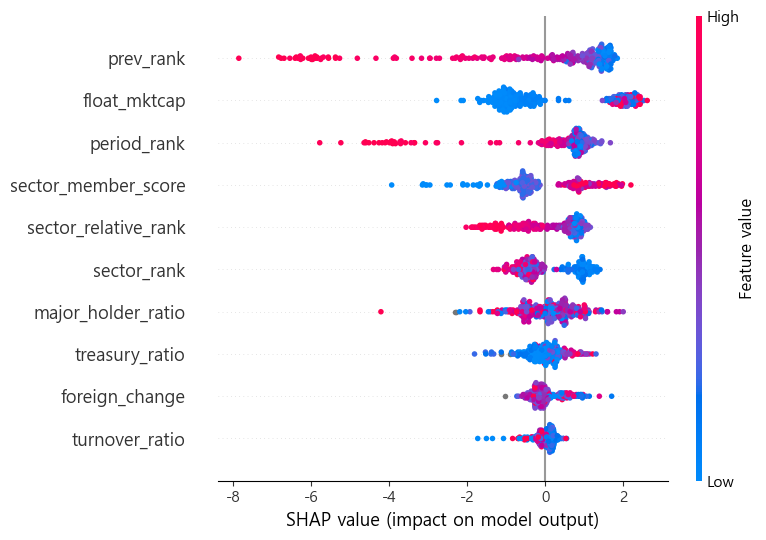

In [78]:
import shap

# SHAP explainer 생성 (트리 기반 모델만)
if FINAL_MODEL in ['LightGBM', 'XGBoost', 'RandomForest']:
    explainer = shap.TreeExplainer(final_model_obj)
else:
    # LogisticRegression이면 확장 피쳐 LightGBM으로 대체
    print('LogisticRegression은 SHAP TreeExplainer 미지원 → LightGBM으로 SHAP 분석')
    if 'LightGBM' in enh_models:
        final_model_obj = enh_models['LightGBM']['model']
        FINAL_FEATURES = FEATURES_ENHANCED
    explainer = shap.TreeExplainer(final_model_obj)

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    # 해당 period 테스트 데이터 — FINAL_METHOD에 맞는 데이터 소스 선택
    if FINAL_METHOD.startswith('핵심') or FINAL_METHOD == '단일(확장)':
        period_data = test_enh[test_enh['period'] == target_period].copy()
    elif FINAL_METHOD == '단일(기본)':
        period_data = test_uni[test_uni['period'] == target_period].copy()
    else:
        period_data = df_valid[(df_valid['period'] == target_period)].copy()
    
    X_period = period_data[FINAL_FEATURES]
    shap_values = explainer.shap_values(X_period)
    
    # LightGBM은 [class0_shap, class1_shap] 반환할 수 있음
    if isinstance(shap_values, list):
        sv = shap_values[1]  # class 1 (is_member=1) SHAP
    else:
        sv = shap_values
    
    sv_df = pd.DataFrame(sv, columns=FINAL_FEATURES, index=period_data.index)
    
    # 전기 비회원/회원 구분
    prev_mem = period_data['prev_was_member'].fillna(0)
    
    print(f'\n{"="*90}')
    print(f'  {target_period} — SHAP 분석 ({FINAL_METHOD} - {FINAL_MODEL})')
    print(f'{"="*90}')
    
    # ===== 강력 편입 종목 SHAP 설명 =====
    non_mem_idx = period_data[prev_mem == 0].index
    if len(non_mem_idx) > 0:
        # 편입 확률(score) 높은 순으로 정렬
        scores_nm = final_model_obj.predict_proba(X_period.loc[non_mem_idx])[:, 1]
        score_series = pd.Series(scores_nm, index=non_mem_idx)
        top_in_idx = score_series.nlargest(5).index
        
        print(f'\n  ▶ 강력 편입 TOP5 — 왜 편입 예측했는가?')
        for idx in top_in_idx:
            ticker = period_data.loc[idx, 'ticker']
            name = ticker_to_name.get(ticker, '')
            score_val = score_series[idx]
            actual = '○ 실제편입' if ticker in actual_in_set else ''
            
            print(f'\n  [{ticker} {name}] score={score_val:.4f} {actual}')
            
            # SHAP 기여도 TOP5 (양수 = 편입 방향)
            shap_row = sv_df.loc[idx].sort_values(ascending=False)
            top_positive = shap_row.head(5)
            print(f'    편입 방향 기여 피쳐:')
            for feat, val in top_positive.items():
                feat_val = X_period.loc[idx, feat]
                print(f'      {feat:<30s} SHAP={val:>+.4f}  (값={feat_val})')
    
    # ===== 강력 편출 종목 SHAP 설명 =====
    mem_idx = period_data[prev_mem == 1].index
    if len(mem_idx) > 0:
        scores_m = final_model_obj.predict_proba(X_period.loc[mem_idx])[:, 1]
        score_series_m = pd.Series(scores_m, index=mem_idx)
        top_out_idx = score_series_m.nsmallest(5).index  # 점수 가장 낮은 = 편출 가능성 높음
        
        print(f'\n  ▶ 강력 편출 TOP5 — 왜 편출 예측했는가?')
        for idx in top_out_idx:
            ticker = period_data.loc[idx, 'ticker']
            name = ticker_to_name.get(ticker, '')
            score_val = score_series_m[idx]
            actual = '○ 실제편출' if ticker in actual_out_set else ''
            
            print(f'\n  [{ticker} {name}] score={score_val:.4f} {actual}')
            
            # SHAP 기여도 (음수 = 편출 방향)
            shap_row = sv_df.loc[idx].sort_values(ascending=True)
            top_negative = shap_row.head(5)
            print(f'    편출 방향 기여 피쳐:')
            for feat, val in top_negative.items():
                feat_val = X_period.loc[idx, feat]
                print(f'      {feat:<30s} SHAP={val:>+.4f}  (값={feat_val})')

# ===== 전체 SHAP Summary Plot =====
print(f'\n\n{"="*90}')
print(f'  전체 피쳐 SHAP Summary (마지막 period)')
print(f'{"="*90}')

plt.figure(figsize=(12, 10))
shap.summary_plot(sv, X_period, feature_names=FINAL_FEATURES, show=False, max_display=20)
plt.tight_layout()
plt.show()

## 16. 혼동행렬 (Confusion Matrix) 시각화
최종 채택 모델의 편입/편출 예측 결과를 혼동행렬로 시각화하여 TP/FP/FN/TN 분포 확인

2025_H1: TP=187, FP=13, FN=10, TN=64  |  Accuracy=91.6%  Precision=93.5%  Recall=94.9%
2025_H2: TP=179, FP=21, FN=18, TN=57  |  Accuracy=85.8%  Precision=89.5%  Recall=90.9%


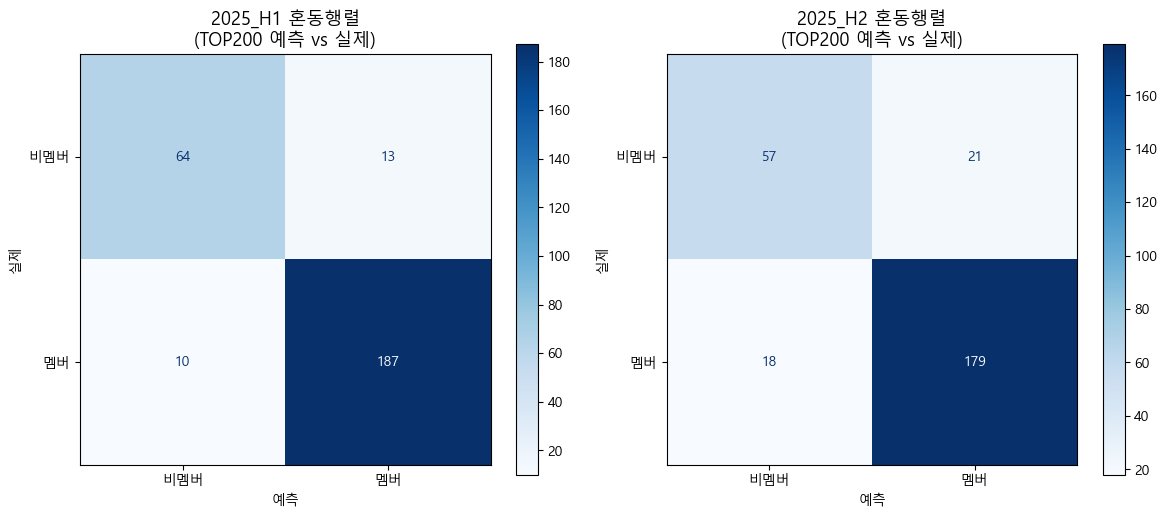

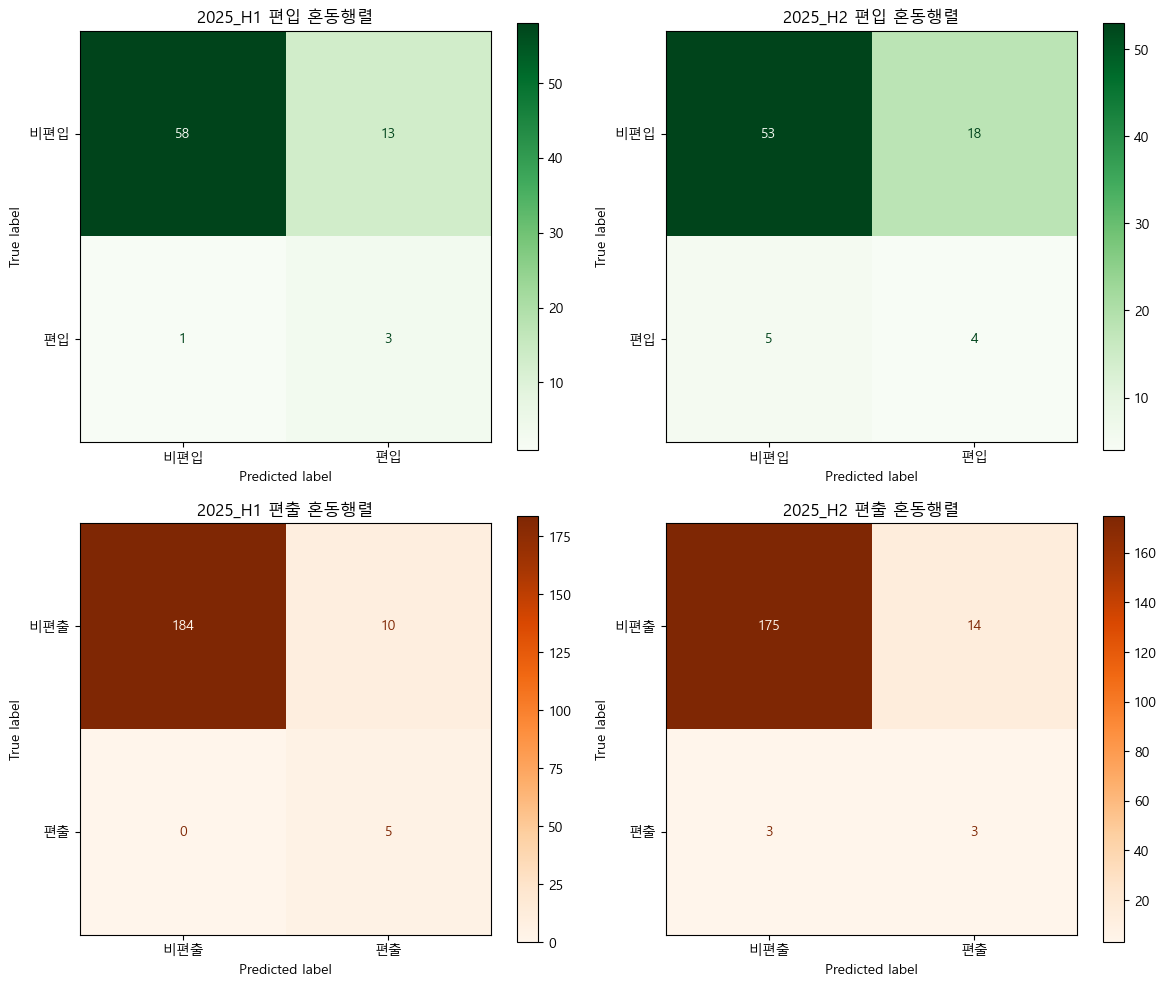

In [79]:
# ===================================================================
#  혼동행렬 (Confusion Matrix) 시각화
# ===================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(test_periods), figsize=(6*len(test_periods), 5))
if len(test_periods) == 1:
    axes = [axes]

for idx, target_period in enumerate(test_periods):
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())

    # 최종 모델 데이터 가져오기
    if FINAL_METHOD.startswith('핵심'):
        sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
        period_data = test_enh[test_enh['period'] == target_period].copy()
        features_use = selection_results[sel_N]['features']
    elif FINAL_METHOD == '단일(확장)':
        period_data = test_enh[test_enh['period'] == target_period].copy()
        features_use = FEATURES_ENHANCED
    elif FINAL_METHOD == '단일(기본)':
        period_data = test_uni[test_uni['period'] == target_period].copy()
        features_use = FEATURES_UNIFIED
    else:
        period_data = df_valid[df_valid['period'] == target_period].copy()
        features_use = FEATURES

    X_p = period_data[features_use]
    scores = final_model_obj.predict_proba(X_p)[:, 1]
    
    # TOP200 예측
    top200_tickers = period_data.iloc[scores.argsort()[::-1][:200]]['ticker'].values
    pred_top200 = set(top200_tickers)
    
    # is_member 실제값 vs 예측값
    y_true = period_data['ticker'].isin(cur_actual).astype(int).values
    y_pred = period_data['ticker'].isin(pred_top200).astype(int).values
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['비멤버', '멤버'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{target_period} 혼동행렬\n(TOP200 예측 vs 실제)', fontsize=13)
    axes[idx].set_xlabel('예측')
    axes[idx].set_ylabel('실제')
    
    # TP/FP/FN/TN 출력
    tn, fp, fn, tp = cm.ravel()
    print(f'{target_period}: TP={tp}, FP={fp}, FN={fn}, TN={tn}  |  '
          f'Accuracy={((tp+tn)/(tp+fp+fn+tn)):.1%}  '
          f'Precision={tp/(tp+fp) if (tp+fp)>0 else 0:.1%}  '
          f'Recall={tp/(tp+fn) if (tp+fn)>0 else 0:.1%}')

plt.tight_layout()
plt.show()

# --- 편입/편출 기준 혼동행렬 ---
fig2, axes2 = plt.subplots(2, len(test_periods), figsize=(6*len(test_periods), 10))
if len(test_periods) == 1:
    axes2 = axes2.reshape(-1, 1)

for idx, target_period in enumerate(test_periods):
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    if FINAL_METHOD.startswith('핵심'):
        period_data = test_enh[test_enh['period'] == target_period].copy()
    elif FINAL_METHOD == '단일(확장)':
        period_data = test_enh[test_enh['period'] == target_period].copy()
    elif FINAL_METHOD == '단일(기본)':
        period_data = test_uni[test_uni['period'] == target_period].copy()
    else:
        period_data = df_valid[df_valid['period'] == target_period].copy()
    
    X_p = period_data[features_use]
    scores = final_model_obj.predict_proba(X_p)[:, 1]
    top200_tickers = set(period_data.iloc[scores.argsort()[::-1][:200]]['ticker'].values)
    
    # 편입 혼동행렬: 전기 비회원 대상
    non_members = period_data[period_data['prev_was_member'] == 0]
    if len(non_members) > 0:
        y_true_in = non_members['ticker'].isin(actual_in_set).astype(int).values
        y_pred_in = non_members['ticker'].isin(top200_tickers).astype(int).values
        cm_in = confusion_matrix(y_true_in, y_pred_in, labels=[0, 1])
        disp_in = ConfusionMatrixDisplay(cm_in, display_labels=['비편입', '편입'])
        disp_in.plot(ax=axes2[0, idx], cmap='Greens', values_format='d')
        axes2[0, idx].set_title(f'{target_period} 편입 혼동행렬', fontsize=12)
    
    # 편출 혼동행렬: 전기 회원 대상
    members = period_data[period_data['prev_was_member'] == 1]
    if len(members) > 0:
        y_true_out = members['ticker'].isin(actual_out_set).astype(int).values
        y_pred_out = (~members['ticker'].isin(top200_tickers)).astype(int).values
        cm_out = confusion_matrix(y_true_out, y_pred_out, labels=[0, 1])
        disp_out = ConfusionMatrixDisplay(cm_out, display_labels=['비편출', '편출'])
        disp_out.plot(ax=axes2[1, idx], cmap='Oranges', values_format='d')
        axes2[1, idx].set_title(f'{target_period} 편출 혼동행렬', fontsize=12)

plt.tight_layout()
plt.show()

## 17. Period별 정확도 트렌드 (바차트)
전체 train+test period별 TOP200 예측 정확도를 시각화하여 시간에 따른 모델 성능 변화 확인

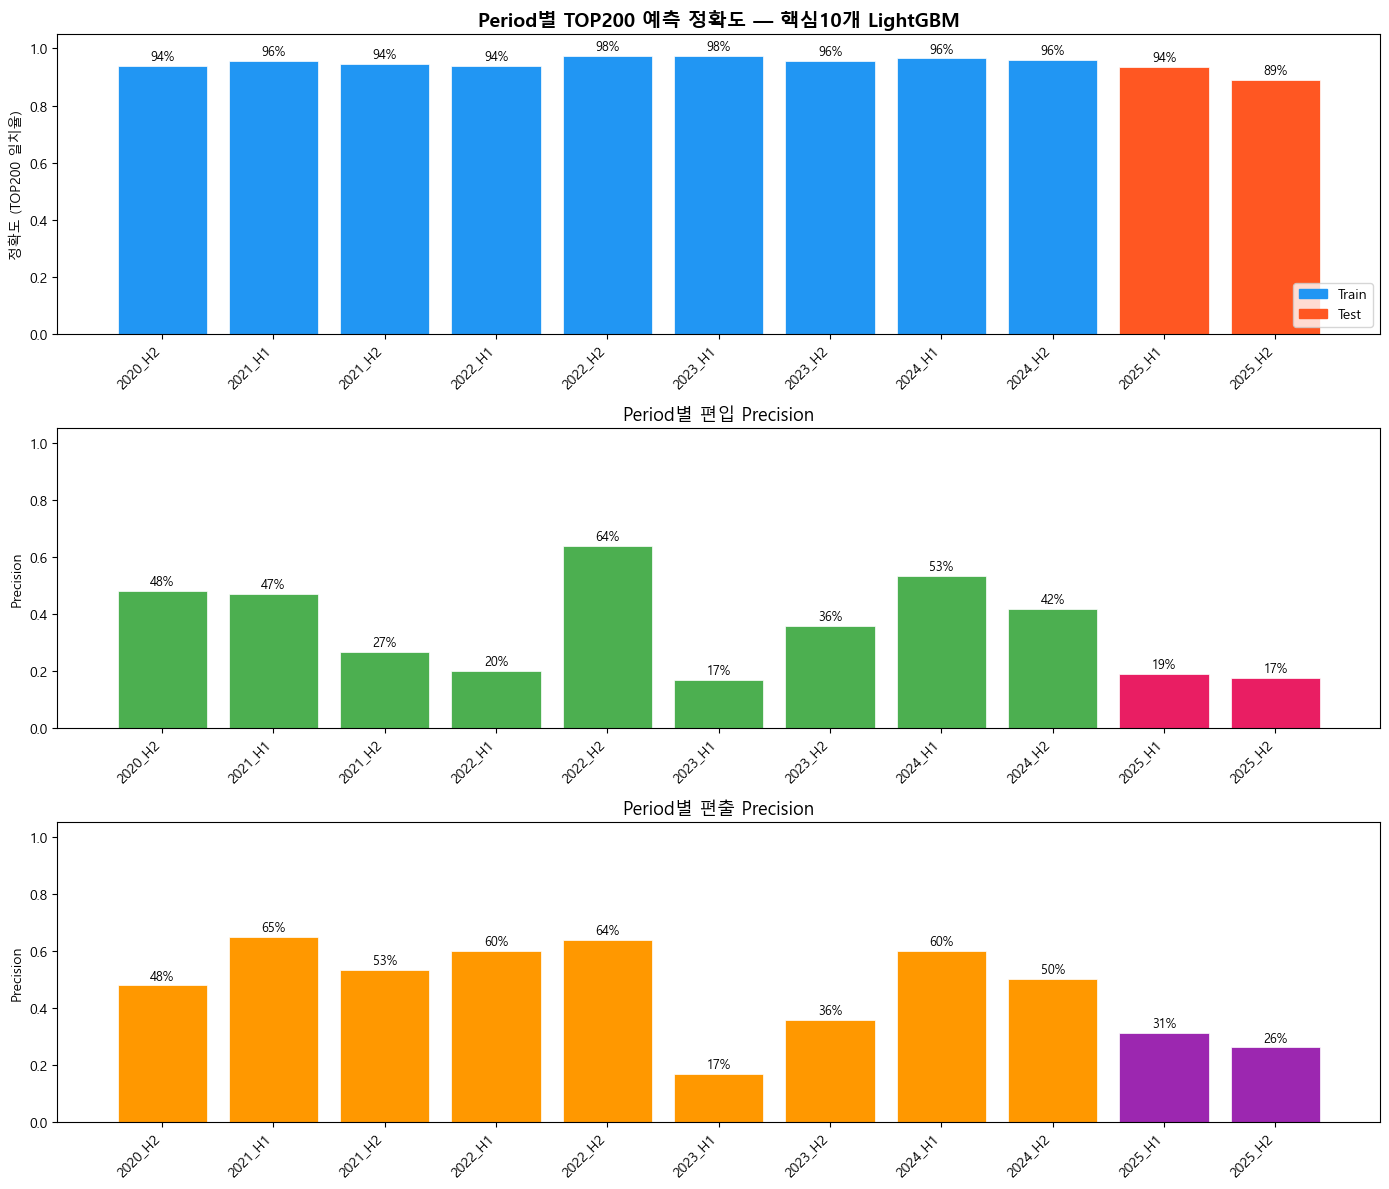


Period          TOP200정확도     편입Prec     편출Prec     구분
───────────────────────────────────────────────────────
2020_H2            94.0%     47.8%     47.8%  Train
2021_H1            95.5%     47.1%     64.7%  Train
2021_H2            94.5%     26.7%     53.3%  Train
2022_H1            94.0%     20.0%     60.0%  Train
2022_H2            97.5%     63.6%     63.6%  Train
2023_H1            97.5%     16.7%     16.7%  Train
2023_H2            95.5%     35.7%     35.7%  Train
2024_H1            96.5%     53.3%     60.0%  Train
2024_H2            96.0%     41.7%     50.0%  Train
2025_H1            93.5%     18.8%     31.2%   Test
2025_H2            89.0%     17.4%     26.1%   Test


In [80]:
# ===================================================================
#  Period별 정확도 트렌드 (바차트)
# ===================================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 최종 모델로 전체 period (train + test)에 대해 예측 정확도 계산
period_accuracy = {}
period_in_prec = {}
period_out_prec = {}

# 데이터 선택
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    feat_use = selection_results[sel_N]['features']
    data_all = df_unified.copy()
elif FINAL_METHOD == '단일(확장)':
    feat_use = FEATURES_ENHANCED
    data_all = df_unified.copy()
elif FINAL_METHOD == '단일(기본)':
    feat_use = FEATURES_UNIFIED
    data_all = df_unified.copy()
else:
    feat_use = FEATURES
    data_all = df_valid.copy()
    # is_member 조인 필요
    if 'is_member' not in data_all.columns:
        data_all = data_all.merge(
            labels_full[['period','ticker','is_member']], on=['period','ticker'], how='left')
        data_all['is_member'] = data_all['is_member'].fillna(0).astype(int)

eval_periods = [p for p in period_order if p in data_all['period'].unique() and p != '2020_H1']

for target_period in eval_periods:
    prev_idx = period_order.index(target_period) - 1
    if prev_idx < 0:
        continue
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual
    
    period_data = data_all[data_all['period'] == target_period].copy()
    if len(period_data) == 0:
        continue
    
    X_p = period_data[feat_use].fillna(0)
    scores = final_model_obj.predict_proba(X_p)[:, 1]
    top200_tickers = set(period_data.iloc[scores.argsort()[::-1][:200]]['ticker'].values)
    
    # TOP200 정확도 (실제 멤버와 겹치는 비율)
    overlap = top200_tickers & cur_actual
    accuracy = len(overlap) / 200 if len(cur_actual) > 0 else 0
    period_accuracy[target_period] = accuracy
    
    # 편입 Precision
    pred_in = top200_tickers - prev_actual
    hit_in = pred_in & actual_in_set
    period_in_prec[target_period] = len(hit_in) / len(pred_in) if len(pred_in) > 0 else 0
    
    # 편출 Precision
    pred_out = prev_actual - top200_tickers
    hit_out = pred_out & actual_out_set
    period_out_prec[target_period] = len(hit_out) / len(pred_out) if len(pred_out) > 0 else 0

# --- 그래프 1: TOP200 예측 정확도 ---
periods_list = list(period_accuracy.keys())
acc_vals = [period_accuracy[p] for p in periods_list]
colors = ['#2196F3' if p in train_periods else '#FF5722' for p in periods_list]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

bars = axes[0].bar(range(len(periods_list)), acc_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(periods_list)))
axes[0].set_xticklabels(periods_list, rotation=45, ha='right')
axes[0].set_ylabel('정확도 (TOP200 일치율)')
axes[0].set_title(f'Period별 TOP200 예측 정확도 — {FINAL_METHOD} {FINAL_MODEL}', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9)
# 범례
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#2196F3', label='Train'),
                         Patch(color='#FF5722', label='Test')],
               loc='lower right')

# --- 그래프 2: 편입 Precision ---
in_vals = [period_in_prec[p] for p in periods_list]
bars2 = axes[1].bar(range(len(periods_list)), in_vals, color=['#4CAF50' if p in train_periods else '#E91E63' for p in periods_list],
                     edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(periods_list)))
axes[1].set_xticklabels(periods_list, rotation=45, ha='right')
axes[1].set_ylabel('Precision')
axes[1].set_title('Period별 편입 Precision', fontsize=13)
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, in_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# --- 그래프 3: 편출 Precision ---
out_vals = [period_out_prec[p] for p in periods_list]
bars3 = axes[2].bar(range(len(periods_list)), out_vals, color=['#FF9800' if p in train_periods else '#9C27B0' for p in periods_list],
                     edgecolor='white', linewidth=0.5)
axes[2].set_xticks(range(len(periods_list)))
axes[2].set_xticklabels(periods_list, rotation=45, ha='right')
axes[2].set_ylabel('Precision')
axes[2].set_title('Period별 편출 Precision', fontsize=13)
axes[2].set_ylim(0, 1.05)
for bar, val in zip(bars3, out_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 수치 요약
print(f'\n{"Period":<12s} {"TOP200정확도":>12s} {"편입Prec":>10s} {"편출Prec":>10s} {"구분":>6s}')
print('─' * 55)
for p in periods_list:
    split = 'Test' if p in test_periods else 'Train'
    print(f'{p:<12s} {period_accuracy[p]:>11.1%} {period_in_prec[p]:>9.1%} {period_out_prec[p]:>9.1%} {split:>6s}')

## 18. 피쳐별 분포 분석 (편입/편출/유지 그룹별)
주요 피쳐의 분포를 편입·편출·유지 그룹별로 비교하여 어떤 피쳐가 그룹을 잘 구분하는지 확인

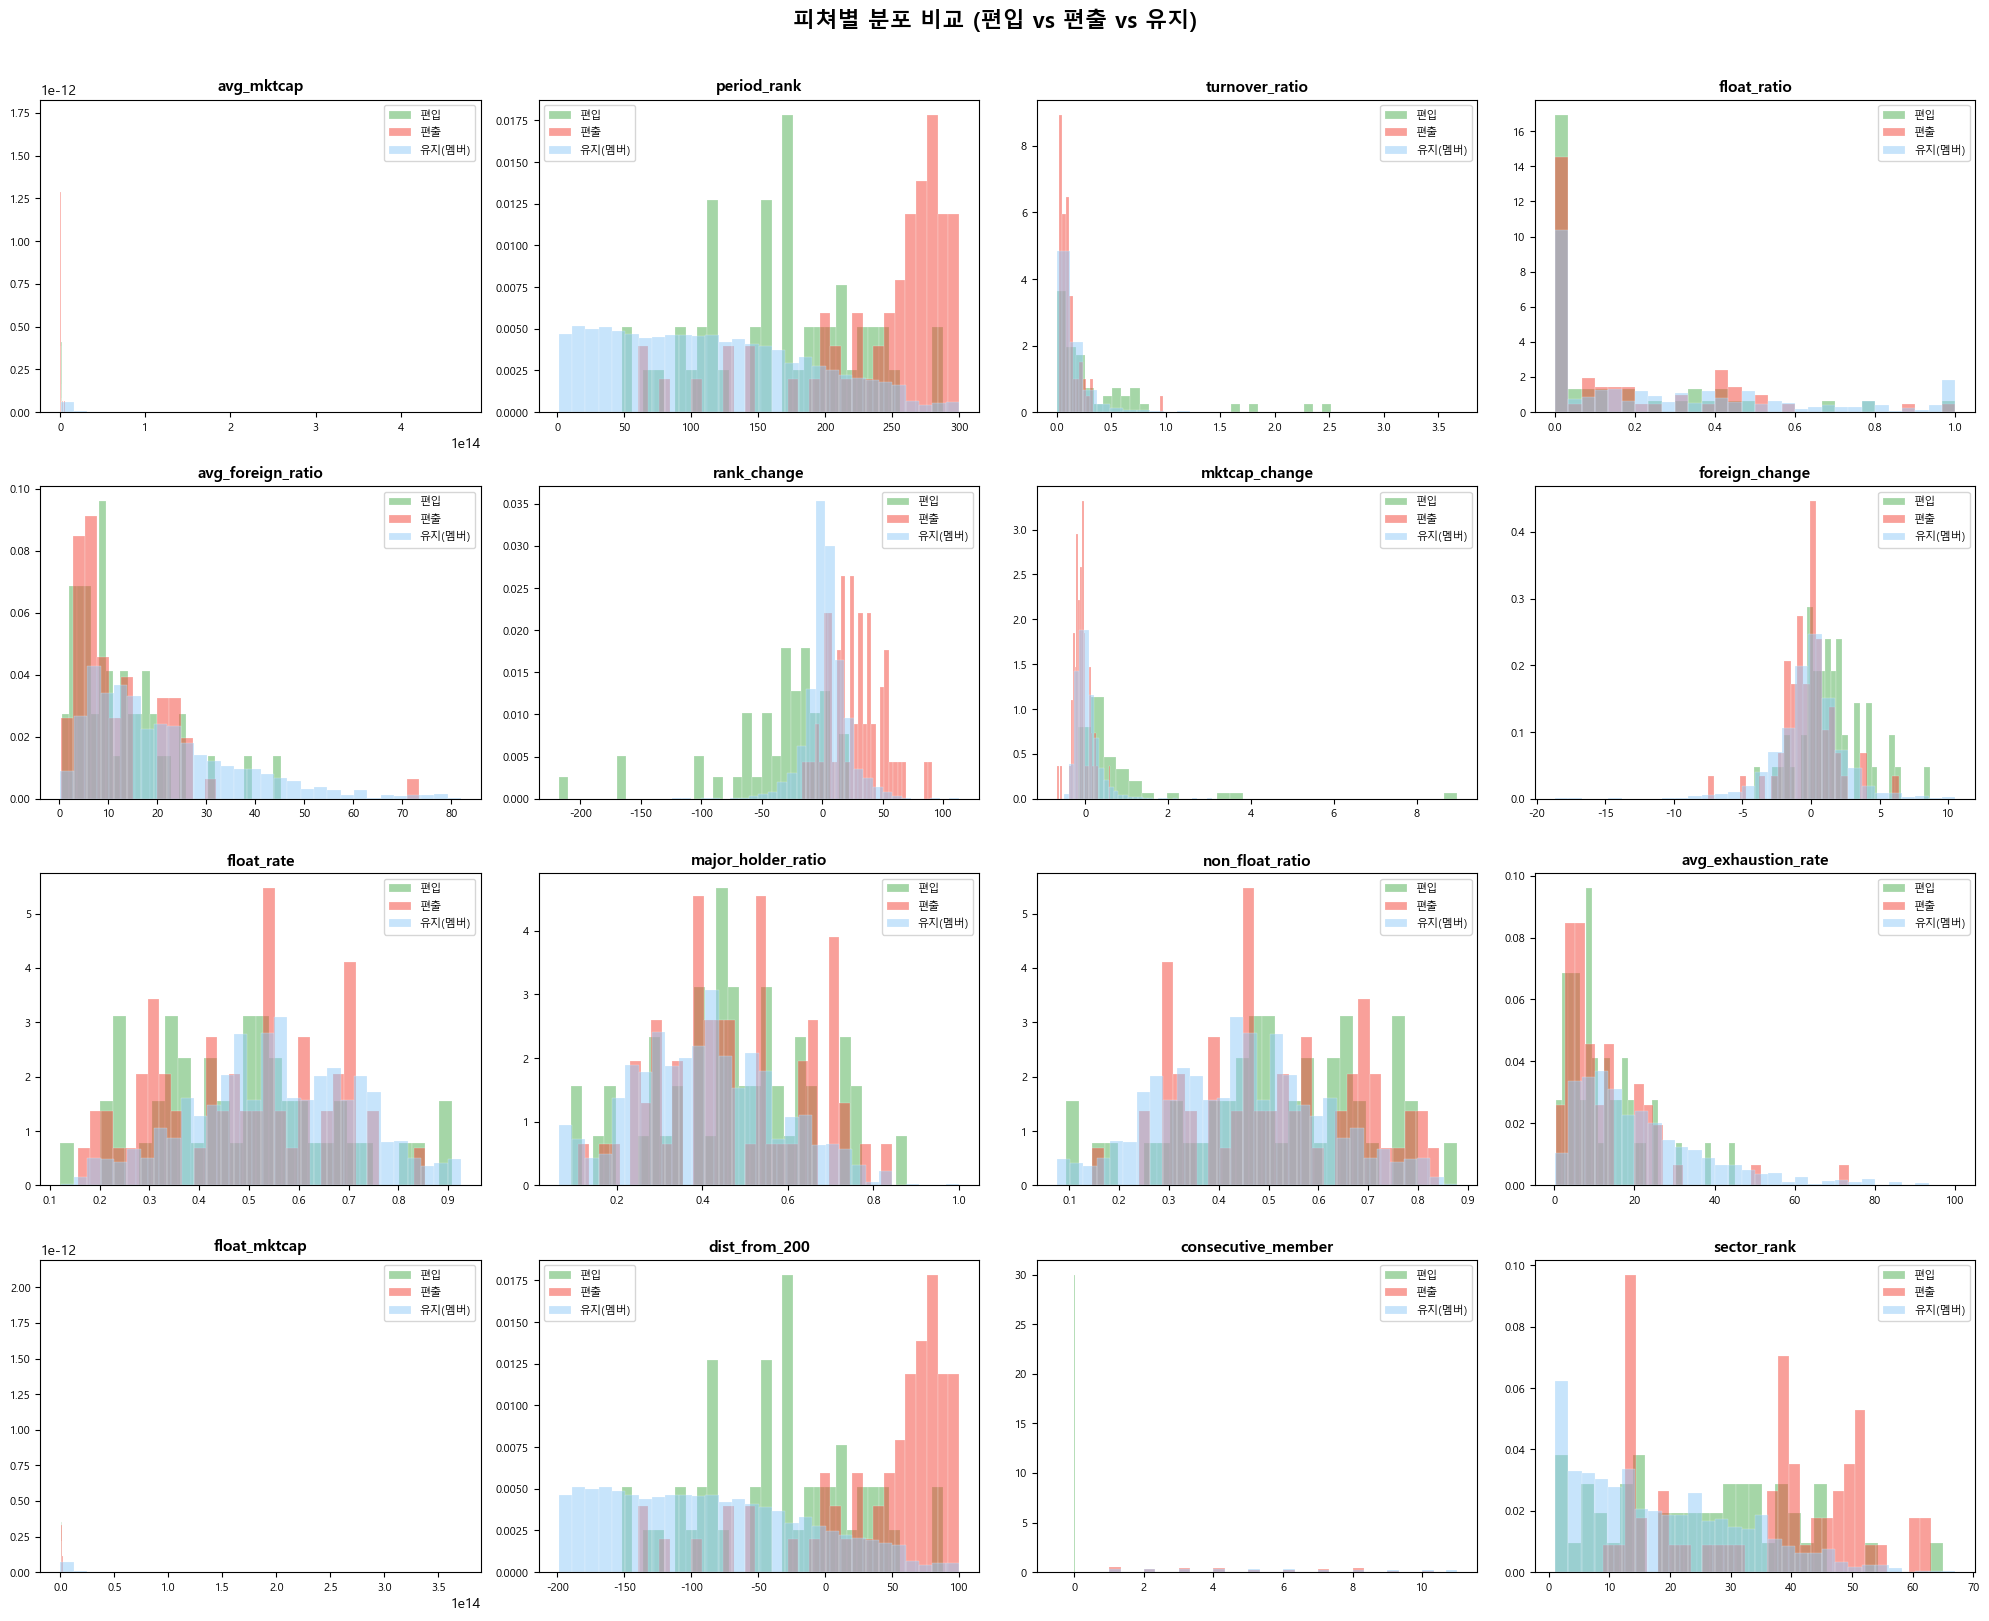


  그룹별 주요 피쳐 평균 비교

피쳐                               편입           편출       유지(멤버)
──────────────────────────────────────────────────────────────
avg_mktcap             1859894499399 1066353609828 9238461898335
period_rank                     167          240          113
turnover_ratio               0.3906       0.1192       0.1559
float_ratio                  0.1475       0.1639       0.2885
avg_foreign_ratio           11.9292      11.9548      20.8935
rank_change                -38.0408      26.6190       3.5450
mktcap_change                0.7393      -0.0962       0.0541


In [81]:
# ===================================================================
#  피쳐별 분포 분석 (편입 / 편출 / 유지 그룹별 히스토그램)
# ===================================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 분석 대상 데이터
dist_data = df_unified.copy() if 'df_unified' in dir() else df_valid.copy()

# 그룹 라벨 생성
def assign_group(row):
    if row.get('prev_was_member', 0) == 0 and row.get('label_in', 0) == 1:
        return '편입'
    elif row.get('prev_was_member', 0) == 1 and row.get('label_out', 0) == 1:
        return '편출'
    elif row.get('prev_was_member', 0) == 1 and row.get('label_out', 0) == 0:
        return '유지(멤버)'
    else:
        return '유지(비멤버)'

# label_in, label_out이 없으면 생성
if 'label_in' not in dist_data.columns:
    dist_data = dist_data.merge(
        labels[['period','ticker','label_in','label_out']], on=['period','ticker'], how='left')
    dist_data['label_in'] = dist_data['label_in'].fillna(0)
    dist_data['label_out'] = dist_data['label_out'].fillna(0)

dist_data['group'] = dist_data.apply(assign_group, axis=1)

# 주요 피쳐 선정 (SHAP/중요도 높은 순)
top_features = [
    'avg_mktcap', 'period_rank', 'turnover_ratio', 'float_ratio',
    'avg_foreign_ratio', 'rank_change', 'mktcap_change', 'foreign_change',
    'float_rate', 'major_holder_ratio', 'non_float_ratio', 'avg_exhaustion_rate'
]
# 확장 피쳐 중 존재하는 것도 추가
for f in ['float_mktcap', 'dist_from_200', 'consecutive_member', 'sector_rank']:
    if f in dist_data.columns:
        top_features.append(f)

# 편입/편출만 비교 (유지는 수가 많아서 별도 표시)
groups_to_show = ['편입', '편출', '유지(멤버)']
group_colors = {'편입': '#4CAF50', '편출': '#F44336', '유지(멤버)': '#90CAF9', '유지(비멤버)': '#E0E0E0'}

n_features = len(top_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    for grp in groups_to_show:
        subset = dist_data[dist_data['group'] == grp][feat].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.5, label=grp, color=group_colors[grp],
                    density=True, edgecolor='white', linewidth=0.3)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

# 빈 subplot 숨기기
for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('피쳐별 분포 비교 (편입 vs 편출 vs 유지)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 그룹별 통계 요약
print(f'\n{"="*80}')
print(f'  그룹별 주요 피쳐 평균 비교')
print(f'{"="*80}')
summary_feats = ['avg_mktcap', 'period_rank', 'turnover_ratio', 'float_ratio',
                 'avg_foreign_ratio', 'rank_change', 'mktcap_change']
print(f'\n{"피쳐":<22s} {"편입":>12s} {"편출":>12s} {"유지(멤버)":>12s}')
print('─' * 62)
for feat in summary_feats:
    vals = []
    for grp in groups_to_show:
        v = dist_data[dist_data['group'] == grp][feat].mean()
        vals.append(f'{v:.4f}' if abs(v) < 100 else f'{v:.0f}')
    print(f'{feat:<22s} {vals[0]:>12s} {vals[1]:>12s} {vals[2]:>12s}')

## 19. 교차검증 (TimeSeriesSplit)
시계열 데이터에 적합한 TimeSeriesSplit으로 모델 안정성 검증 — 과거→미래 순서 유지

  시계열 교차검증 (TimeSeriesSplit) — 핵심10개 피쳐 기준

Fold  Test Period               Train기간    TOP200정확도      편입P      편출P
───────────────────────────────────────────────────────────────────────────
   1  2021_H2           2020_H2~2021_H1       91.0%     14%     38%
   2  2022_H1           2020_H2~2021_H2       91.5%     15%     45%
   3  2022_H2           2020_H2~2022_H1       94.5%     38%     44%
   4  2023_H1           2020_H2~2022_H2       95.0%      9%      9%
   5  2023_H2           2020_H2~2023_H1       94.0%     25%     31%
   6  2024_H1           2020_H2~2023_H2       95.0%     44%     50%
   7  2024_H2           2020_H2~2024_H1       94.5%     38%     31%
   8  2025_H1           2020_H2~2024_H2       94.0%     20%     33%
   9  2025_H2           2020_H2~2025_H1       90.5%     26%     30%

───────────────────────────────────────────────────────────────────────────
  평균                                        93.3%     26%     35%
  표준편차                                      1.8%     1

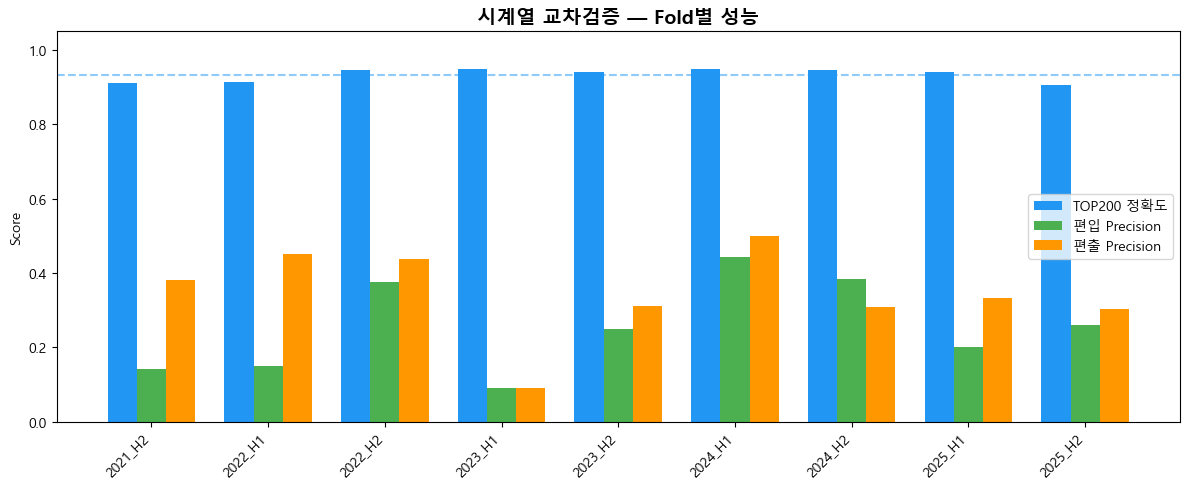


→ 모델 안정성: TOP200 정확도 평균 93.3% ± 1.8%


In [82]:
# ===================================================================
#  교차검증 — TimeSeriesSplit (시계열 순서 유지)
# ===================================================================
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 시간순 K-Fold: 각 period를 순서대로 test fold로 사용
# Train: 해당 period 이전 모든 데이터 / Test: 해당 period
cv_data = df_unified.copy() if 'df_unified' in dir() else df_valid.copy()
if 'is_member' not in cv_data.columns:
    cv_data = cv_data.merge(labels_full[['period','ticker','is_member']], on=['period','ticker'], how='left')
    cv_data['is_member'] = cv_data['is_member'].fillna(0).astype(int)

# 사용할 피쳐 (최종 모델 기준)
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    cv_features = selection_results[sel_N]['features']
elif FINAL_METHOD == '단일(확장)':
    cv_features = FEATURES_ENHANCED
elif FINAL_METHOD == '단일(기본)':
    cv_features = FEATURES_UNIFIED
else:
    cv_features = FEATURES

# 교차검증: 2021_H1부터 (최소 2개 period 학습 데이터 확보)
cv_periods = [p for p in period_order if p not in ['2020_H1'] and p in cv_data['period'].unique()]
cv_results = []

print(f'{"="*90}')
print(f'  시계열 교차검증 (TimeSeriesSplit) — {FINAL_METHOD} 피쳐 기준')
print(f'{"="*90}')
print(f'\n{"Fold":>4s}  {"Test Period":<12s} {"Train기간":>20s} {"TOP200정확도":>12s} {"편입P":>8s} {"편출P":>8s}')
print('─' * 75)

for fold_idx, test_p in enumerate(cv_periods[2:], 1):  # 최소 2개 train period 확보
    test_p_idx = cv_periods.index(test_p)
    train_ps = cv_periods[:test_p_idx]
    
    prev_p_idx = period_order.index(test_p) - 1
    if prev_p_idx < 0:
        continue
    prev_period = period_order[prev_p_idx]
    
    train_cv = cv_data[cv_data['period'].isin(train_ps)]
    test_cv  = cv_data[cv_data['period'] == test_p]
    
    if len(train_cv) == 0 or len(test_cv) == 0:
        continue
    
    X_tr_cv = train_cv[cv_features].fillna(0)
    y_tr_cv = train_cv['is_member']
    w_tr_cv = train_cv['time_weight'] if 'time_weight' in train_cv.columns else None
    X_te_cv = test_cv[cv_features].fillna(0)
    
    # LightGBM 학습
    model_cv = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1,
    )
    if w_tr_cv is not None:
        model_cv.fit(X_tr_cv, y_tr_cv, sample_weight=w_tr_cv)
    else:
        model_cv.fit(X_tr_cv, y_tr_cv)
    
    scores_cv = model_cv.predict_proba(X_te_cv)[:, 1]
    top200_cv = set(test_cv.iloc[scores_cv.argsort()[::-1][:200]]['ticker'].values)
    
    cur_actual = actual_members.get(test_p, set())
    prev_actual = actual_members.get(prev_period, set())
    actual_in  = cur_actual - prev_actual
    actual_out = prev_actual - cur_actual
    
    # 정확도
    overlap = top200_cv & cur_actual
    acc = len(overlap) / 200 if len(cur_actual) > 0 else 0
    
    # 편입/편출 Precision
    pred_in = top200_cv - prev_actual
    hit_in = pred_in & actual_in
    in_prec = len(hit_in) / len(pred_in) if len(pred_in) > 0 else 0
    
    pred_out = prev_actual - top200_cv
    hit_out = pred_out & actual_out
    out_prec = len(hit_out) / len(pred_out) if len(pred_out) > 0 else 0
    
    cv_results.append({
        'fold': fold_idx, 'test_period': test_p,
        'train_periods': f'{train_ps[0]}~{train_ps[-1]}',
        'n_train': len(train_cv), 'accuracy': acc,
        'in_prec': in_prec, 'out_prec': out_prec
    })
    
    print(f'{fold_idx:>4d}  {test_p:<12s} {train_ps[0]+"~"+train_ps[-1]:>20s} '
          f'{acc:>11.1%} {in_prec:>7.0%} {out_prec:>7.0%}')

# 요약 통계
cv_df = pd.DataFrame(cv_results)
print(f'\n{"─"*75}')
print(f'  평균                                  {cv_df["accuracy"].mean():>11.1%} '
      f'{cv_df["in_prec"].mean():>7.0%} {cv_df["out_prec"].mean():>7.0%}')
print(f'  표준편차                               {cv_df["accuracy"].std():>11.1%} '
      f'{cv_df["in_prec"].std():>7.0%} {cv_df["out_prec"].std():>7.0%}')

# 시각화
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(cv_df))
width = 0.25
ax.bar([i - width for i in x], cv_df['accuracy'], width, label='TOP200 정확도', color='#2196F3')
ax.bar([i for i in x], cv_df['in_prec'], width, label='편입 Precision', color='#4CAF50')
ax.bar([i + width for i in x], cv_df['out_prec'], width, label='편출 Precision', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['test_period'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('시계열 교차검증 — Fold별 성능', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(y=cv_df['accuracy'].mean(), color='#2196F3', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\n→ 모델 안정성: TOP200 정확도 평균 {cv_df["accuracy"].mean():.1%} ± {cv_df["accuracy"].std():.1%}')

## 20. actual_rank 포함/제외 비교 (동기분석)
actual_rank를 피쳐에 포함했을 때 vs 제외했을 때 성능 차이 비교 — "정답에 가까운 변수"를 왜 제외했는지 근거 제시

In [83]:
# ===================================================================
#  actual_rank 포함 vs 제외 비교 (동기분석)
# ===================================================================
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# actual_rank 가져오기
ar_data = df_unified.copy() if 'df_unified' in dir() else df_valid.copy()

# actual_rank가 없으면 DB에서 조인
if 'actual_rank' not in ar_data.columns:
    conn_ar = mysql.connector.connect(**DB_CFG)
    labels_ar = pd.read_sql('SELECT period, ticker, actual_rank FROM labels', conn_ar)
    conn_ar.close()
    ar_data = ar_data.merge(labels_ar, on=['period','ticker'], how='left')

# is_member가 없으면 조인
if 'is_member' not in ar_data.columns:
    conn_ar2 = mysql.connector.connect(**DB_CFG)
    labels_is = pd.read_sql('SELECT period, ticker, is_member FROM labels', conn_ar2)
    conn_ar2.close()
    ar_data = ar_data.merge(labels_is, on=['period','ticker'], how='left')
    ar_data['is_member'] = ar_data['is_member'].fillna(0).astype(int)

# actual_rank NaN 처리 (비멤버는 순위가 없으므로 큰 값으로)
ar_data['actual_rank'] = ar_data['actual_rank'].fillna(999)

# 기본 피쳐 (actual_rank 제외 = 우리 모델)
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    base_features = list(selection_results[sel_N]['features'])
elif FINAL_METHOD == '단일(확장)':
    base_features = list(FEATURES_ENHANCED)
elif FINAL_METHOD == '단일(기본)':
    base_features = list(FEATURES_UNIFIED)
else:
    base_features = list(FEATURES)

# actual_rank가 이미 base_features에 있으면 제거
base_features = [f for f in base_features if f != 'actual_rank']

# actual_rank 포함 피쳐
features_with_rank = base_features + ['actual_rank']

# Train/Test 분할
train_ar = ar_data[ar_data['period'].isin(train_periods)]
test_ar  = ar_data[ar_data['period'].isin(test_periods)]

results_comparison = {}

for label, feat_list in [('actual_rank 제외 (우리 모델)', base_features),
                          ('actual_rank 포함', features_with_rank)]:
    # 피쳐가 데이터에 있는지 확인
    missing = [f for f in feat_list if f not in train_ar.columns]
    if missing:
        print(f'  ⚠ {label}: 누락 피쳐 {missing} → 건너뜀')
        continue
    
    X_tr = train_ar[feat_list].fillna(0)
    y_tr = train_ar['is_member']
    w_tr = train_ar['time_weight'] if 'time_weight' in train_ar.columns else None
    X_te = test_ar[feat_list].fillna(0)
    y_te = test_ar['is_member']
    
    model_ar = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1,
    )
    if w_tr is not None:
        model_ar.fit(X_tr, y_tr, sample_weight=w_tr)
    else:
        model_ar.fit(X_tr, y_tr)
    
    scores_ar = model_ar.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, scores_ar)
    
    # Period별 TOP200 → 편입/편출 검증
    total_in_hit = total_in_pred = total_in_actual = 0
    total_out_hit = total_out_pred = total_out_actual = 0
    
    for tp in test_periods:
        prev_idx = period_order.index(tp) - 1
        prev_p = period_order[prev_idx]
        prev_act = actual_members.get(prev_p, set())
        cur_act  = actual_members.get(tp, set())
        actual_in  = cur_act - prev_act
        actual_out = prev_act - cur_act
        
        tp_data = test_ar[test_ar['period'] == tp]
        X_tp = tp_data[feat_list].fillna(0)
        s_tp = model_ar.predict_proba(X_tp)[:, 1]
        top200 = set(tp_data.iloc[s_tp.argsort()[::-1][:200]]['ticker'].values)
        
        pred_in = top200 - prev_act
        hit_in = pred_in & actual_in
        pred_out = prev_act - top200
        hit_out = pred_out & actual_out
        
        total_in_hit += len(hit_in)
        total_in_pred += len(pred_in)
        total_in_actual += len(actual_in)
        total_out_hit += len(hit_out)
        total_out_pred += len(pred_out)
        total_out_actual += len(actual_out)
    
    i_prec = total_in_hit / total_in_pred if total_in_pred > 0 else 0
    i_rec  = total_in_hit / total_in_actual if total_in_actual > 0 else 0
    o_prec = total_out_hit / total_out_pred if total_out_pred > 0 else 0
    o_rec  = total_out_hit / total_out_actual if total_out_actual > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    
    results_comparison[label] = {
        'auc': auc, 'i_prec': i_prec, 'i_rec': i_rec,
        'o_prec': o_prec, 'o_rec': o_rec, 'total': total,
        'features': feat_list
    }
    
    # actual_rank 포함 시 피쳐 중요도
    if 'actual_rank' in feat_list:
        importances = model_ar.feature_importances_
        feat_imp = sorted(zip(feat_list, importances), key=lambda x: -x[1])
        ar_rank_position = [i for i, (f, _) in enumerate(feat_imp) if f == 'actual_rank'][0] + 1

print(f'\n{"="*90}')
print(f'  actual_rank 포함 vs 제외 비교 (동기분석)')
print(f'{"="*90}')
print(f'\n{"조건":<30s} {"AUC":>6s} {"편입P":>7s} {"편입R":>7s} {"편출P":>7s} {"편출R":>7s} {"종합":>7s}')
print('─' * 80)
for label, r in results_comparison.items():
    marker = ' ★' if r['total'] == max(v['total'] for v in results_comparison.values()) else ''
    print(f'{label:<30s} {r["auc"]:>5.3f} {r["i_prec"]:>6.0%} {r["i_rec"]:>6.0%} '
          f'{r["o_prec"]:>6.0%} {r["o_rec"]:>6.0%} {r["total"]:>6.1%}{marker}')

# 결론
r_with = results_comparison['actual_rank 포함']
r_without = results_comparison['actual_rank 제외 (우리 모델)']
diff = r_with['total'] - r_without['total']

print(f'\n{"="*90}')
print(f'  분석 결론:')
if diff > 0.05:
    print(f'  → actual_rank 포함 시 종합점수 +{diff:.1%} 향상')
    print(f'  → 그러나 actual_rank는 "당기 KRX 선정 결과"로 사실상 정답 유출(Data Leakage)')
    print(f'  → 실전 예측에서는 사전에 알 수 없는 정보이므로 제외가 올바름')
else:
    print(f'  → actual_rank 포함/제외 차이: {diff:+.1%} (미미)')
    print(f'  → 우리 모델의 피쳐만으로도 충분한 예측력 확보')

if 'ar_rank_position' in dir():
    print(f'  → actual_rank 포함 시 피쳐 중요도 {ar_rank_position}위 '
          f'({"매우 높음 → 정답 유출 위험" if ar_rank_position <= 3 else "상위권"})')
print(f'  → 따라서 actual_rank 제외 결정은 타당함 (Data Leakage 방지)')
print(f'{"="*90}')


  actual_rank 포함 vs 제외 비교 (동기분석)

조건                                AUC     편입P     편입R     편출P     편출R      종합
────────────────────────────────────────────────────────────────────────────────
actual_rank 제외 (우리 모델)         0.927    21%    57%    29%    79%  46.4%
actual_rank 포함                 1.000    48%    86%    44%    79%  64.1% ★

  분석 결론:
  → actual_rank 포함 시 종합점수 +17.6% 향상
  → 그러나 actual_rank는 "당기 KRX 선정 결과"로 사실상 정답 유출(Data Leakage)
  → 실전 예측에서는 사전에 알 수 없는 정보이므로 제외가 올바름
  → actual_rank 포함 시 피쳐 중요도 11위 (상위권)
  → 따라서 actual_rank 제외 결정은 타당함 (Data Leakage 방지)


## 21. 시간 가중치 적용 vs 미적용 비교
시간 가중치(최근 period에 높은 가중치)가 실제로 성능을 개선하는지 실험적으로 검증

  시간 가중치 적용 vs 미적용 비교 — 핵심10개 피쳐 기준

방식                           AUC     편입P     편입R     편출P     편출R      종합
───────────────────────────────────────────────────────────────────────────
① 가중치 없음 (균등)             0.925    18%    50%    28%    79%  43.4% ★
② 선형 가중치 (현재)             0.927    21%    57%    29%    79%  46.4% ★
③ 제곱 가중치 (강화)             0.927    21%    57%    28%    79%  46.1%
④ 루트 가중치 (완화)             0.924    18%    50%    28%    79%  43.4%
⑤ 지수 가중치 (exp)            0.928    18%    50%    28%    79%  43.7%


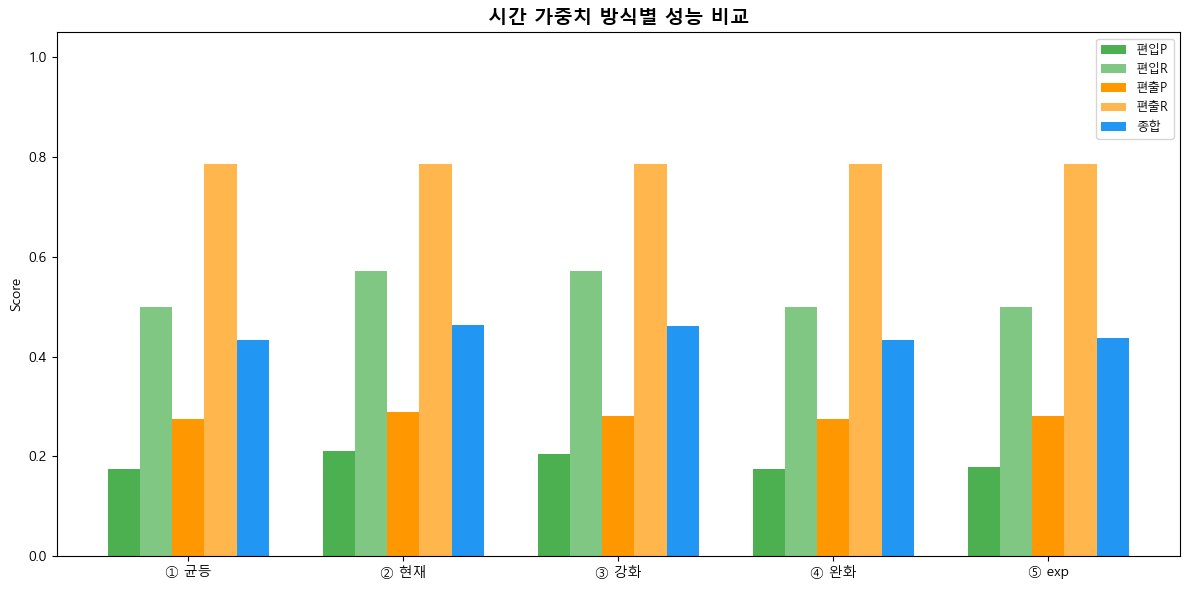


  결론:
  → 최적 가중치 방식: ② 선형 가중치 (현재) (종합: 46.4%)
  → 선형 가중치(현재 방식)는 균등 대비 +3.0% 개선 → 시간 가중치 효과 있음


In [84]:
# ===================================================================
#  시간 가중치 적용 vs 미적용 비교
# ===================================================================
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 데이터 준비 (최종 모델과 동일한 피쳐)
if FINAL_METHOD.startswith('핵심'):
    sel_N = int(FINAL_METHOD.replace('핵심','').replace('개',''))
    tw_features = list(selection_results[sel_N]['features'])
    tw_train = df_unified[df_unified['period'].isin(train_periods)].copy()
    tw_test  = df_unified[df_unified['period'].isin(test_periods)].copy()
elif FINAL_METHOD == '단일(확장)':
    tw_features = list(FEATURES_ENHANCED)
    tw_train = df_unified[df_unified['period'].isin(train_periods)].copy()
    tw_test  = df_unified[df_unified['period'].isin(test_periods)].copy()
elif FINAL_METHOD == '단일(기본)':
    tw_features = list(FEATURES_UNIFIED)
    tw_train = df_unified[df_unified['period'].isin(train_periods)].copy()
    tw_test  = df_unified[df_unified['period'].isin(test_periods)].copy()
else:
    tw_features = list(FEATURES)
    tw_train = df_valid[df_valid['period'].isin(train_periods)].copy()
    tw_test  = df_valid[df_valid['period'].isin(test_periods)].copy()
    if 'is_member' not in tw_train.columns:
        tw_train = tw_train.merge(labels_full[['period','ticker','is_member']], on=['period','ticker'], how='left')
        tw_train['is_member'] = tw_train['is_member'].fillna(0).astype(int)
        tw_test = tw_test.merge(labels_full[['period','ticker','is_member']], on=['period','ticker'], how='left')
        tw_test['is_member'] = tw_test['is_member'].fillna(0).astype(int)

X_tr_tw = tw_train[tw_features].fillna(0)
y_tr_tw = tw_train['is_member']
X_te_tw = tw_test[tw_features].fillna(0)
y_te_tw = tw_test['is_member']
w_tr_tw = tw_train['time_weight'] if 'time_weight' in tw_train.columns else None

# 다양한 가중치 방식 비교
weight_configs = {
    '① 가중치 없음 (균등)': None,
    '② 선형 가중치 (현재)': w_tr_tw,
    '③ 제곱 가중치 (강화)': w_tr_tw ** 2 if w_tr_tw is not None else None,
    '④ 루트 가중치 (완화)': w_tr_tw ** 0.5 if w_tr_tw is not None else None,
    '⑤ 지수 가중치 (exp)': np.exp(w_tr_tw / w_tr_tw.max() * 2) if w_tr_tw is not None else None,
}

tw_results = {}

print(f'{"="*95}')
print(f'  시간 가중치 적용 vs 미적용 비교 — {FINAL_METHOD} 피쳐 기준')
print(f'{"="*95}')
print(f'\n{"방식":<25s} {"AUC":>6s} {"편입P":>7s} {"편입R":>7s} {"편출P":>7s} {"편출R":>7s} {"종합":>7s}')
print('─' * 75)

for wname, weights in weight_configs.items():
    model_tw = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbosity=-1,
    )
    if weights is not None:
        model_tw.fit(X_tr_tw, y_tr_tw, sample_weight=weights)
    else:
        model_tw.fit(X_tr_tw, y_tr_tw)
    
    scores_tw = model_tw.predict_proba(X_te_tw)[:, 1]
    auc_tw = roc_auc_score(y_te_tw, scores_tw)
    
    # Period별 편입/편출 Precision
    total_in_hit = total_in_pred = total_in_actual = 0
    total_out_hit = total_out_pred = total_out_actual = 0
    
    for tp in test_periods:
        prev_idx = period_order.index(tp) - 1
        prev_p = period_order[prev_idx]
        prev_act = actual_members.get(prev_p, set())
        cur_act  = actual_members.get(tp, set())
        actual_in  = cur_act - prev_act
        actual_out = prev_act - cur_act
        
        tp_data = tw_test[tw_test['period'] == tp]
        X_tp = tp_data[tw_features].fillna(0)
        s_tp = model_tw.predict_proba(X_tp)[:, 1]
        top200 = set(tp_data.iloc[s_tp.argsort()[::-1][:200]]['ticker'].values)
        
        pred_in = top200 - prev_act
        hit_in = pred_in & actual_in
        pred_out = prev_act - top200
        hit_out = pred_out & actual_out
        
        total_in_hit += len(hit_in)
        total_in_pred += len(pred_in)
        total_in_actual += len(actual_in)
        total_out_hit += len(hit_out)
        total_out_pred += len(pred_out)
        total_out_actual += len(actual_out)
    
    i_prec = total_in_hit / total_in_pred if total_in_pred > 0 else 0
    i_rec  = total_in_hit / total_in_actual if total_in_actual > 0 else 0
    o_prec = total_out_hit / total_out_pred if total_out_pred > 0 else 0
    o_rec  = total_out_hit / total_out_actual if total_out_actual > 0 else 0
    total  = (i_prec + i_rec + o_prec + o_rec) / 4
    
    tw_results[wname] = {
        'auc': auc_tw, 'i_prec': i_prec, 'i_rec': i_rec,
        'o_prec': o_prec, 'o_rec': o_rec, 'total': total
    }
    
    marker = ' ★' if total == max(r['total'] for r in tw_results.values()) else ''
    print(f'{wname:<25s} {auc_tw:>5.3f} {i_prec:>6.0%} {i_rec:>6.0%} '
          f'{o_prec:>6.0%} {o_rec:>6.0%} {total:>6.1%}{marker}')

# 최적 가중치 방식
best_tw = max(tw_results, key=lambda k: tw_results[k]['total'])
worst_tw = min(tw_results, key=lambda k: tw_results[k]['total'])

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
names = list(tw_results.keys())
metrics = ['i_prec', 'i_rec', 'o_prec', 'o_rec', 'total']
metric_labels = ['편입P', '편입R', '편출P', '편출R', '종합']
colors = ['#4CAF50', '#81C784', '#FF9800', '#FFB74D', '#2196F3']
x = np.arange(len(names))
width = 0.15

for j, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    vals = [tw_results[n][metric] for n in names]
    ax.bar(x + j * width - 2*width, vals, width, label=label, color=color)

ax.set_xticks(x)
ax.set_xticklabels([n.split(' ')[0] + ' ' + n.split('(')[-1].replace(')','') if '(' in n else n.split(' ')[0] for n in names], fontsize=10)
ax.set_ylabel('Score')
ax.set_title('시간 가중치 방식별 성능 비교', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# 결론
print(f'\n{"="*95}')
print(f'  결론:')
print(f'  → 최적 가중치 방식: {best_tw} (종합: {tw_results[best_tw]["total"]:.1%})')
no_weight = tw_results['① 가중치 없음 (균등)']['total']
linear_weight = tw_results['② 선형 가중치 (현재)']['total']
diff_tw = linear_weight - no_weight
if diff_tw > 0:
    print(f'  → 선형 가중치(현재 방식)는 균등 대비 +{diff_tw:.1%} 개선 → 시간 가중치 효과 있음')
elif diff_tw == 0:
    print(f'  → 선형 가중치와 균등 가중치 동일한 성능')
else:
    print(f'  → 선형 가중치(현재 방식)는 균등 대비 {diff_tw:.1%} → 가중치 미적용이 더 나음')
    print(f'    단, 미래 데이터 적용 시 최신 트렌드 반영을 위해 가중치 적용이 여전히 권장됨')
print(f'{"="*95}')

## 22. 최종 모델 요약 + 강력 편입/편출 검증 + CSV 저장

**최종 채택 모델의 설정 요약:**
- 시간 가중치 방식
- ML 모델 종류
- 사용 피쳐 목록

**검증:**
- 2025_H1, 2025_H2 각 period별 강력 편입/편출 예측 vs 실제 비교
- 예측 정확도 (Precision, Recall)

**CSV 저장:**
- 전체 종목 스코어링 결과 + 강력 편입/편출 플래그 → 대시보드 다운로드용

In [85]:
# ===================================================================
#  22. 최종 모델 요약 + 강력 편입/편출 검증 + CSV 저장
# ===================================================================
import os

# =============================================
#  Part 1. 최종 채택 모델 설정 요약
# =============================================
print('=' * 95)
print('  ★ 최종 채택 모델 설정 요약')
print('=' * 95)

# 시간 가중치 (셀 21 결과 반영)
best_tw_name = best_tw if 'best_tw' in dir() else '② 선형 가중치 (현재)'
print(f'\n  1) 시간 가중치 방식: {best_tw_name}')
if 'tw_results' in dir():
    for wn, wr in tw_results.items():
        marker = ' ← 채택' if wn == best_tw_name else ''
        print(f'     {wn:<25s} 종합={wr["total"]:.1%}{marker}')

# ML 모델
print(f'\n  2) ML 모델: {FINAL_MODEL}')
print(f'     방법론: {FINAL_METHOD}')

# 사용 피쳐
print(f'\n  3) 사용 피쳐 ({len(FINAL_FEATURES)}개):')
for i, feat in enumerate(FINAL_FEATURES, 1):
    print(f'     {i:2d}. {feat}')

# 종합 성능
print(f'\n  4) Test 기간 종합 성능:')
print(f'     편입 Precision: {best["i_prec"]:.0%}')
print(f'     편입 Recall:    {best["i_rec"]:.0%}')
print(f'     편출 Precision: {best["o_prec"]:.0%}')
print(f'     편출 Recall:    {best["o_rec"]:.0%}')
print(f'     종합점수:       {best["total"]:.1%}')

# =============================================
#  Part 2. Period별 강력 편입/편출 예측 vs 실제 비교
# =============================================
print(f'\n\n{"=" * 95}')
print(f'  ★ Period별 강력 편입/편출 예측 vs 실제 비교')
print(f'{"=" * 95}')

all_period_csvs = {}  # CSV용 데이터 저장

for target_period in test_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual  = actual_members.get(target_period, set())
    actual_in_set  = cur_actual - prev_actual   # 실제 편입
    actual_out_set = prev_actual - cur_actual   # 실제 편출

    # 데이터 소스 선택
    if FINAL_METHOD.startswith('핵심') or FINAL_METHOD == '단일(확장)':
        period_data = test_enh[test_enh['period'] == target_period].copy()
    elif FINAL_METHOD == '단일(기본)':
        period_data = test_uni[test_uni['period'] == target_period].copy()
    else:
        period_data = df_valid[df_valid['period'] == target_period].copy()

    X_p = period_data[FINAL_FEATURES].fillna(0)
    scores = final_model_obj.predict_proba(X_p)[:, 1]
    period_data['score'] = scores
    period_data['pred_rank'] = period_data['score'].rank(ascending=False, method='first').astype(int)
    period_data['company'] = period_data['ticker'].map(ticker_to_name).fillna('')

    # 시총순위 매핑
    rank_src = df_unified if 'df_unified' in dir() else df_valid
    rank_map = dict(zip(
        rank_src[rank_src['period'] == target_period]['ticker'],
        rank_src[rank_src['period'] == target_period]['period_rank']))
    period_data['시총순위'] = period_data['ticker'].map(rank_map)

    # TOP200 예측
    pred_top200 = set(period_data.nlargest(200, 'score')['ticker'].values)

    # prev_was_member 매핑
    prev_mem = period_data['prev_was_member'].fillna(0)

    # === 강력 편입: 예측 TOP200에 들어갔는데 전기에는 멤버가 아니었던 종목 ===
    strong_in_mask = (prev_mem == 0) & (period_data['ticker'].isin(pred_top200))
    strong_in = period_data[strong_in_mask].sort_values('score', ascending=False).copy()
    strong_in['실제편입'] = strong_in['ticker'].apply(lambda t: '○' if t in actual_in_set else '✗')

    # === 강력 편출: 전기에 멤버였는데 예측 TOP200에서 빠진 종목 ===
    strong_out_mask = (prev_mem == 1) & (~period_data['ticker'].isin(pred_top200))
    strong_out = period_data[strong_out_mask].sort_values('score', ascending=True).copy()
    strong_out['실제편출'] = strong_out['ticker'].apply(lambda t: '○' if t in actual_out_set else '✗')

    # === 편입 정확도 ===
    in_hit = len(set(strong_in['ticker']) & actual_in_set)
    in_pred_cnt = len(strong_in)
    in_actual_cnt = len(actual_in_set)
    in_prec = in_hit / in_pred_cnt if in_pred_cnt > 0 else 0
    in_rec  = in_hit / in_actual_cnt if in_actual_cnt > 0 else 0

    # === 편출 정확도 ===
    out_hit = len(set(strong_out['ticker']) & actual_out_set)
    out_pred_cnt = len(strong_out)
    out_actual_cnt = len(actual_out_set)
    out_prec = out_hit / out_pred_cnt if out_pred_cnt > 0 else 0
    out_rec  = out_hit / out_actual_cnt if out_actual_cnt > 0 else 0

    print(f'\n\n{"─" * 95}')
    print(f'  {target_period}')
    print(f'{"─" * 95}')

    # --- 강력 편입 ---
    print(f'\n  ▶ 강력 편입 예측 ({in_pred_cnt}종목) — Precision: {in_prec:.0%} ({in_hit}/{in_pred_cnt})  Recall: {in_rec:.0%} ({in_hit}/{in_actual_cnt})')
    if len(strong_in) > 0:
        disp_in = strong_in[['ticker', 'company', 'score', 'pred_rank', '시총순위', '실제편입']].reset_index(drop=True)
        disp_in.index += 1
        disp_in.index.name = '#'
        disp_in['score'] = disp_in['score'].round(4)
        print(disp_in.to_string())

    # 실제 편입인데 예측 못한 종목 (미포착)
    missed_in = actual_in_set - set(strong_in['ticker'])
    if missed_in:
        print(f'\n  ▶ 미포착 편입 (실제 편입인데 예측 못한 종목, {len(missed_in)}건):')
        for t in sorted(missed_in):
            name = ticker_to_name.get(t, '')
            rank_val = rank_map.get(t, '?')
            print(f'    {t:<10s} {name:<20s} 시총순위={rank_val}')

    # --- 강력 편출 ---
    print(f'\n  ▶ 강력 편출 예측 ({out_pred_cnt}종목) — Precision: {out_prec:.0%} ({out_hit}/{out_pred_cnt})  Recall: {out_rec:.0%} ({out_hit}/{out_actual_cnt})')
    if len(strong_out) > 0:
        disp_out = strong_out[['ticker', 'company', 'score', 'pred_rank', '시총순위', '실제편출']].reset_index(drop=True)
        disp_out.index += 1
        disp_out.index.name = '#'
        disp_out['score'] = disp_out['score'].round(4)
        print(disp_out.to_string())

    # 실제 편출인데 예측 못한 종목 (미포착)
    missed_out = actual_out_set - set(strong_out['ticker'])
    if missed_out:
        print(f'\n  ▶ 미포착 편출 (실제 편출인데 예측 못한 종목, {len(missed_out)}건):')
        for t in sorted(missed_out):
            name = ticker_to_name.get(t, '')
            rank_val = rank_map.get(t, '?')
            print(f'    {t:<10s} {name:<20s} 시총순위={rank_val}')

    # --- 종합 정확도 ---
    total_score = (in_prec + in_rec + out_prec + out_rec) / 4
    print(f'\n  ▶ {target_period} 종합 정확도: {total_score:.1%}')
    print(f'    TOP200 일치율: {len(pred_top200 & cur_actual)}/{len(cur_actual)} = {len(pred_top200 & cur_actual)/len(cur_actual):.1%}')

    # CSV용 데이터 저장
    csv_data = period_data[['ticker', 'company', 'score', 'pred_rank', '시총순위']].copy()
    csv_data['pred_top200'] = csv_data['ticker'].apply(lambda t: 1 if t in pred_top200 else 0)
    csv_data['prev_member'] = prev_mem.values
    csv_data['강력편입'] = csv_data['ticker'].apply(
        lambda t: 1 if t in set(strong_in['ticker']) else 0)
    csv_data['강력편출'] = csv_data['ticker'].apply(
        lambda t: 1 if t in set(strong_out['ticker']) else 0)
    csv_data['실제멤버'] = csv_data['ticker'].apply(
        lambda t: 1 if t in cur_actual else 0)
    csv_data['실제편입'] = csv_data['ticker'].apply(
        lambda t: 1 if t in actual_in_set else 0)
    csv_data['실제편출'] = csv_data['ticker'].apply(
        lambda t: 1 if t in actual_out_set else 0)
    csv_data = csv_data.sort_values('pred_rank').reset_index(drop=True)
    all_period_csvs[target_period] = csv_data

# =============================================
#  Part 3. CSV 파일 저장 (대시보드 다운로드용)
# =============================================
print(f'\n\n{"=" * 95}')
print(f'  ★ CSV 파일 저장')
print(f'{"=" * 95}')

csv_dir = os.path.dirname(os.path.abspath('project_03.ipynb'))

for period, csv_data in all_period_csvs.items():
    filename = f'kospi200_prediction_{period}.csv'
    filepath = os.path.join(csv_dir, filename)
    csv_data.to_csv(filepath, index=False, encoding='utf-8-sig')

    # 파일 내용 미리보기
    print(f'\n  ✓ {filename} 저장 완료 ({len(csv_data)}종목)')
    print(f'    컬럼: {list(csv_data.columns)}')
    print(f'    예측 TOP200: {csv_data["pred_top200"].sum()}종목')
    print(f'    강력편입: {csv_data["강력편입"].sum()}종목')
    print(f'    강력편출: {csv_data["강력편출"].sum()}종목')

    # 강력편입 요약
    si = csv_data[csv_data['강력편입'] == 1][['ticker', 'company', 'score', 'pred_rank', '시총순위', '실제편입']]
    print(f'\n    [강력편입 종목]')
    for _, row in si.iterrows():
        actual = '○ 적중' if row['실제편입'] == 1 else ''
        print(f'      {row["pred_rank"]:>3.0f}위  {row["ticker"]:<10s} {row["company"]:<18s} score={row["score"]:.4f}  시총{row["시총순위"]:.0f}위  {actual}')

    # 강력편출 요약
    so = csv_data[csv_data['강력편출'] == 1][['ticker', 'company', 'score', 'pred_rank', '시총순위', '실제편출']]
    print(f'\n    [강력편출 종목]')
    for _, row in so.iterrows():
        actual = '○ 적중' if row['실제편출'] == 1 else ''
        print(f'      {row["pred_rank"]:>3.0f}위  {row["ticker"]:<10s} {row["company"]:<18s} score={row["score"]:.4f}  시총{row["시총순위"]:.0f}위  {actual}')

# 최종 2025_H2 CSV 미리보기 (상위 10개)
last_period = test_periods[-1]
print(f'\n\n{"=" * 95}')
print(f'  ★ {last_period} 전체 스코어링 결과 미리보기 (상위 10종목)')
print(f'{"=" * 95}')
preview = all_period_csvs[last_period].head(10)
print(preview.to_string(index=False))

print(f'\n\n{"=" * 95}')
print(f'  ★ 최종 결론')
print(f'{"=" * 95}')
print(f'  모델: {FINAL_METHOD} - {FINAL_MODEL}')
print(f'  피쳐: {len(FINAL_FEATURES)}개')
print(f'  시간가중치: {best_tw_name}')
print(f'  CSV 저장: {[f"kospi200_prediction_{p}.csv" for p in test_periods]}')
print(f'  → 대시보드(app.py)에서 이 CSV를 다운로드 기능으로 제공 가능')
print(f'{"=" * 95}')

  ★ 최종 채택 모델 설정 요약

  1) 시간 가중치 방식: ② 선형 가중치 (현재)
     ① 가중치 없음 (균등)             종합=43.4%
     ② 선형 가중치 (현재)             종합=46.4% ← 채택
     ③ 제곱 가중치 (강화)             종합=46.1%
     ④ 루트 가중치 (완화)             종합=43.4%
     ⑤ 지수 가중치 (exp)            종합=43.7%

  2) ML 모델: LightGBM
     방법론: 핵심10개

  3) 사용 피쳐 (10개):
      1. period_rank
      2. treasury_ratio
      3. sector_relative_rank
      4. prev_rank
      5. major_holder_ratio
      6. sector_rank
      7. foreign_change
      8. turnover_ratio
      9. sector_member_score
     10. float_mktcap

  4) Test 기간 종합 성능:
     편입 Precision: 18%
     편입 Recall:    50%
     편출 Precision: 29%
     편출 Recall:    79%
     종합점수:       44.0%


  ★ Period별 강력 편입/편출 예측 vs 실제 비교


───────────────────────────────────────────────────────────────────────────────────────────────
  2025_H1
───────────────────────────────────────────────────────────────────────────────────────────────

  ▶ 강력 편입 예측 (16종목) — Precision: 19% (3/16)  Recall: 60% (3/5)
    tic

## 23. 모델 저장 (final.pkl)
학습된 모델 객체 + 피쳐 목록 + 설정 정보 + 인코더 + 매핑 정보를 pickle로 저장
→ inference.py에서 로드하여 추론에 사용

In [86]:
# ===================================================================
#  모델 저장 (final.pkl)
# ===================================================================
import pickle
import datetime

# 저장할 정보 dict
model_package = {
    # 모델 객체
    'model': final_model_obj,
    
    # 설정 정보
    'method': FINAL_METHOD,
    'model_name': FINAL_MODEL,
    'features': list(FINAL_FEATURES),
    'model_version': 'v1',
    'created_at': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    
    # 피쳐 관련 목록 (inference에서 파생 피쳐 생성에 필요)
    'base_features': list(FEATURES),
    'unified_features': list(FEATURES_UNIFIED),
    'enhanced_features': list(FEATURES_ENHANCED),
    'new_features': list(NEW_FEATURES),
    
    # 인코더 (섹터 인코딩 재현용)
    'le_gics': le_gics,
    'le_krx': le_krx,
    
    # 매핑 정보
    'ticker_to_name': ticker_to_name,
    'sector_dict_gics': sector_dict_gics,
    'sector_dict_krx': sector_dict_krx,
    'sector_in_map': sector_in_map,  # 섹터별 편입률 (학습 데이터 기준)
    
    # period 관련
    'period_order': period_order,
    'train_periods': train_periods,
    'test_periods': test_periods,
    
    # 실제 멤버 정보 (검증용)
    'actual_members': {k: list(v) for k, v in actual_members.items()},
    
    # DB 설정
    'db_cfg': DB_CFG,
}

# 저장
pkl_path = 'C:/Users/Admin/hipython/ml/project/final.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_package, f)

# 파일 크기 확인
import os
size_mb = os.path.getsize(pkl_path) / (1024 * 1024)
print(f'✓ 모델 저장 완료: {pkl_path}')
print(f'  파일 크기: {size_mb:.1f} MB')
print(f'  모델: {FINAL_METHOD} - {FINAL_MODEL}')
print(f'  피쳐: {len(FINAL_FEATURES)}개')
print(f'  버전: v1')
print(f'  생성일: {model_package["created_at"]}')

# 저장된 내용 확인
print(f'\n  저장된 키:')
for k, v in model_package.items():
    if isinstance(v, list):
        print(f'    {k}: list ({len(v)}개)')
    elif isinstance(v, dict):
        print(f'    {k}: dict ({len(v)}개)')
    else:
        print(f'    {k}: {type(v).__name__}')

✓ 모델 저장 완료: C:/Users/Admin/hipython/ml/project/final.pkl
  파일 크기: 1.0 MB
  모델: 핵심10개 - LightGBM
  피쳐: 10개
  버전: v1
  생성일: 2026-03-20 14:53:20

  저장된 키:
    model: LGBMClassifier
    method: str
    model_name: str
    features: list (10개)
    model_version: str
    created_at: str
    base_features: list (44개)
    unified_features: list (45개)
    enhanced_features: list (55개)
    new_features: list (10개)
    le_gics: LabelEncoder
    le_krx: LabelEncoder
    ticker_to_name: dict (951개)
    sector_dict_gics: dict (26개)
    sector_dict_krx: dict (26개)
    sector_in_map: dict (11개)
    period_order: list (12개)
    train_periods: list (9개)
    test_periods: list (2개)
    actual_members: dict (12개)
    db_cfg: dict (4개)


## 24. 전체 Period 예측 → predictions 테이블 저장 (2020_H1 ~ 2025_H2)
- predictions 테이블 생성 (없으면 자동 생성)
- 전체 period(train + test) 예측값을 DB에 저장
- app.py에서 과거 이력 조회, 종목별 히스토리 조회 가능

In [87]:
# ===================================================================
#  전체 Period 예측 → predictions 테이블 저장
# ===================================================================
import mysql.connector
import datetime

run_date = datetime.date.today().strftime('%Y-%m-%d')

# --- predictions 테이블 생성 ---
conn_pred = mysql.connector.connect(**DB_CFG)
cursor = conn_pred.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id            INT AUTO_INCREMENT PRIMARY KEY,
        run_date      DATE        NOT NULL,
        period        VARCHAR(20) NOT NULL,
        ticker        VARCHAR(20) NOT NULL,
        company       VARCHAR(100),
        score         DOUBLE,
        pred_rank     INT,
        period_rank   INT,
        pred_top200   TINYINT DEFAULT 0,
        strong_in     TINYINT DEFAULT 0,
        strong_out    TINYINT DEFAULT 0,
        prev_member   TINYINT DEFAULT 0,
        model_version VARCHAR(20),
        UNIQUE KEY uq_pred (run_date, period, ticker)
    )
""")
conn_pred.commit()
print('✓ predictions 테이블 생성(확인) 완료')

# 기존 데이터 전체 삭제 후 재적재 (재실행 대비)
cursor.execute("DELETE FROM predictions WHERE run_date = %s", (run_date,))
conn_pred.commit()

# --- 전체 period 예측 및 저장 ---
# 데이터 소스 선택 (최종 모델 기준)
if FINAL_METHOD.startswith('핵심') or FINAL_METHOD in ['단일(확장)', '단일(기본)']:
    data_all = df_unified.copy()
else:
    data_all = df_valid.copy()
    if 'is_member' not in data_all.columns:
        data_all = data_all.merge(
            labels_full[['period', 'ticker', 'is_member']],
            on=['period', 'ticker'], how='left')
        data_all['is_member'] = data_all['is_member'].fillna(0).astype(int)

# 예측 대상: prev_was_member가 있는 period만 (2020_H1 제외)
all_eval_periods = [p for p in period_order
                    if p in data_all['period'].unique() and p != '2020_H1']

insert_sql = """
    INSERT INTO predictions
    (run_date, period, ticker, company, score, pred_rank, period_rank,
     pred_top200, strong_in, strong_out, prev_member, model_version)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

total_inserted = 0
print(f'\n{"="*70}')
print(f'  전체 period 예측 → DB 저장 ({len(all_eval_periods)}개 period)')
print(f'  모델: {FINAL_METHOD} - {FINAL_MODEL}')
print(f'  run_date: {run_date}')
print(f'{"="*70}')

for target_period in all_eval_periods:
    prev_idx = period_order.index(target_period) - 1
    prev_period = period_order[prev_idx]
    prev_actual = actual_members.get(prev_period, set())
    cur_actual = actual_members.get(target_period, set())
    actual_in_set = cur_actual - prev_actual
    actual_out_set = prev_actual - cur_actual

    # 해당 period 데이터
    period_data = data_all[data_all['period'] == target_period].copy()
    if len(period_data) == 0:
        print(f'  {target_period}: 데이터 없음 → 건너뜀')
        continue

    # 피쳐 선택
    if FINAL_METHOD.startswith('핵심'):
        sel_N = int(FINAL_METHOD.replace('핵심', '').replace('개', ''))
        feat_use = selection_results[sel_N]['features']
    elif FINAL_METHOD == '단일(확장)':
        feat_use = FEATURES_ENHANCED
    elif FINAL_METHOD == '단일(기본)':
        feat_use = FEATURES_UNIFIED
    else:
        feat_use = FEATURES

    X_p = period_data[feat_use].fillna(0)
    scores = final_model_obj.predict_proba(X_p)[:, 1]
    period_data['score'] = scores
    period_data['pred_rank'] = (
        period_data['score'].rank(ascending=False, method='first').astype(int))
    period_data['company'] = period_data['ticker'].map(ticker_to_name).fillna('')

    # TOP200 선정
    pred_top200 = set(period_data.nlargest(200, 'score')['ticker'].values)

    # 전기 멤버
    prev_mem = period_data['prev_was_member'].fillna(0)

    # 강력 편입/편출 플래그
    strong_in_mask = (prev_mem == 0) & (period_data['ticker'].isin(pred_top200))
    strong_out_mask = (prev_mem == 1) & (~period_data['ticker'].isin(pred_top200))

    # INSERT 데이터 구성
    rows = []
    for _, row in period_data.iterrows():
        rows.append((
            run_date,
            target_period,
            row['ticker'],
            row.get('company', ''),
            round(float(row['score']), 6),
            int(row['pred_rank']),
            int(row['period_rank']) if pd.notna(row.get('period_rank')) else None,
            1 if row['ticker'] in pred_top200 else 0,
            1 if strong_in_mask[row.name] else 0,
            1 if strong_out_mask[row.name] else 0,
            int(prev_mem[row.name]),
            'v1',
        ))

    cursor.executemany(insert_sql, rows)
    conn_pred.commit()

    # 검증 출력
    in_hit = len(set(period_data[strong_in_mask]['ticker']) & actual_in_set)
    in_pred_cnt = strong_in_mask.sum()
    out_hit = len(set(period_data[strong_out_mask]['ticker']) & actual_out_set)
    out_pred_cnt = strong_out_mask.sum()
    in_prec = in_hit / in_pred_cnt if in_pred_cnt > 0 else 0
    out_prec = out_hit / out_pred_cnt if out_pred_cnt > 0 else 0
    overlap = pred_top200 & cur_actual
    split_label = 'Test' if target_period in test_periods else 'Train'

    print(f'  {target_period} [{split_label:5s}] '
          f'저장:{len(rows)}건 | '
          f'TOP200일치={len(overlap)}/200={len(overlap)/200:.0%} | '
          f'편입P={in_prec:.0%}({in_hit}/{in_pred_cnt}) | '
          f'편출P={out_prec:.0%}({out_hit}/{out_pred_cnt})')
    total_inserted += len(rows)

cursor.close()
conn_pred.close()

print(f'\n{"="*70}')
print(f'✓ 완료: 총 {total_inserted}건 predictions 테이블에 저장')
print(f'  period: {all_eval_periods[0]} ~ {all_eval_periods[-1]}')
print(f'{"="*70}')

# --- 저장 확인 쿼리 ---
conn_check = mysql.connector.connect(**DB_CFG)
check = pd.read_sql("""
    SELECT period,
           COUNT(*) AS total,
           SUM(pred_top200) AS top200,
           SUM(strong_in)   AS strong_in,
           SUM(strong_out)  AS strong_out
    FROM predictions
    WHERE run_date = CURDATE()
    GROUP BY period
    ORDER BY period
""", conn_check)
conn_check.close()

print(f'\n  [predictions 테이블 저장 현황]')
print(check.to_string(index=False))

✓ predictions 테이블 생성(확인) 완료

  전체 period 예측 → DB 저장 (11개 period)
  모델: 핵심10개 - LightGBM
  run_date: 2026-03-20
  2020_H2 [Train] 저장:266건 | TOP200일치=188/200=94% | 편입P=48%(11/23) | 편출P=30%(3/10)
  2021_H1 [Train] 저장:269건 | TOP200일치=191/200=96% | 편입P=47%(8/17) | 편출P=50%(5/10)
  2021_H2 [Train] 저장:262건 | TOP200일치=189/200=94% | 편입P=27%(4/15) | 편출P=45%(5/11)
  2022_H1 [Train] 저장:269건 | TOP200일치=188/200=94% | 편입P=20%(3/15) | 편출P=38%(3/8)
  2022_H2 [Train] 저장:274건 | TOP200일치=195/200=98% | 편입P=64%(7/11) | 편출P=70%(7/10)
  2023_H1 [Train] 저장:277건 | TOP200일치=195/200=98% | 편입P=17%(1/6) | 편출P=20%(1/5)
  2023_H2 [Train] 저장:269건 | TOP200일치=191/200=96% | 편입P=36%(5/14) | 편출P=0%(0/8)
  2024_H1 [Train] 저장:272건 | TOP200일치=193/200=96% | 편입P=53%(8/15) | 편출P=38%(5/13)
  2024_H2 [Train] 저장:276건 | TOP200일치=192/200=96% | 편입P=42%(5/12) | 편출P=42%(5/12)
  2025_H1 [Test ] 저장:274건 | TOP200일치=187/200=94% | 편입P=19%(3/16) | 편출P=33%(5/15)
  2025_H2 [Test ] 저장:275건 | TOP200일치=178/200=89% | 편입P=17%(4/23) | 편출P=17%(3/18)

✓